# Preprocessing

## Imports

In [1]:
# ============================================================
# 0) Imports
# ============================================================
from pathlib import Path
from datetime import datetime
import calendar
#mpl.use("Agg")

import numpy as np
import pandas as pd
import xarray as xr
from netCDF4 import Dataset
import scipy.ndimage as ndimage

import os
import re
import xgboost as xgb
import matplotlib as mpl
#mpl.use("Agg")
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
try:
    from optuna_integration.xgboost import XGBoostPruningCallback
except ModuleNotFoundError:
    from optuna.integration import XGBoostPruningCallback
from optuna.visualization import plot_contour

from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ============================================================
# 1) Settings / constants
# ============================================================
start_day = datetime(2000, 1, 1, 0)   # 2003 missing
stop_day  = datetime(2022, 12, 31, 23)
missing_year = 2003

# paths: 
# Hail observations
noaa_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/hail_observations/SPC_data_griddedERA")
essl_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/hail_observations/ESSL_data_griddedERA")

# ERA5 data
era_conus_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors_conus")
era_eu_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors_eu")
era_invar_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/e5_data_processing/e5_invariant")
era_const_fields = era_invar_dir / "e5_invariant_129_z_ll025sc.2020010100_2020010100.nc"

# Population density file
gpw_npz_path = Path("/nfs/cumulus/highres_nobackup/agebhardt/gpw/gpw_2020_era025.npz")

# LSM
lsm_file = era_invar_dir / "e5_lsm_11024sc.nc"

# Target grids
# US
us_lat_min, us_lat_max = 25.25, 49.0
us_lon_min, us_lon_max = -130.0, -65.0

# noaa_lat_slice = slice(14, 110) # CONUS

# latn_us = 164 # ERA CONUS slice
# lats_us = 260 # ERA CONUS slice

# ESSL
eu_lat_min, eu_lat_max = 35.0, 65.0
eu_lon_min, eu_lon_max = -10.0, 35.0

# predictors
all_model_vars = [
    "CAPEmax", "SRH03", "VS03", "FLH",
    "CINmax", "SRH06", "VS06", "DewT",
    "TotalTotals", "RH850", "RH500",
]

 # no relevant: SRH06, RH500, CINmax, RH850
model_vars = [
    "CAPEmax", "SRH03", "VS03", "FLH",
    "CINmax", "VS06", "DewT",
    "TotalTotals",
]

ix_vs03 = model_vars.index("VS03")
ix_vs06 = model_vars.index("VS06")

sel_idx = [all_model_vars.index(v) for v in model_vars]
print("Selected predictor indices:", sel_idx, "=>", [all_model_vars[i] for i in sel_idx])

# ============================================================
# 2) Time vectors
# ============================================================
rgdTimeDD = pd.date_range(start_day, end=stop_day, freq="D")
rgdTime1H = pd.date_range(start_day, end=stop_day, freq="h")

rgdTimeDD = rgdTimeDD[rgdTimeDD.year != missing_year]
rgdTime1H = rgdTime1H[rgdTime1H.year != missing_year]

iYears  = np.unique(rgdTimeDD.year)
iMonths = np.unique(rgdTimeDD.month)

# ============================================================
# 3) Read ERA invariant fields (lat/lon/height) and shift lon to [-180, 180]
# ============================================================
with Dataset(era_const_fields, mode="r") as nc:
    rgrLat = np.squeeze(nc.variables["latitude"][:]).astype(np.float32)     # (lat,)
    rgrLon = np.squeeze(nc.variables["longitude"][:]).astype(np.float32)    # (lon,)
    rgrHeight = (np.squeeze(nc.variables["z"][:]).astype(np.float32)) / 9.81

# shift lon to [-180,180]
rgrLon = np.where(rgrLon > 180, rgrLon - 360, rgrLon)

# 2D lat/lon grids (optional, but matches your original)
rgrLatERA = np.tile(rgrLat[:, None], (1, rgrLon.size))
rgrLonERA = np.tile(rgrLon[None, :], (rgrLat.size, 1))

print(f"ERA invariant fields are read in...")
print(f"ERA lat/lon shape (global): {rgrLatERA.shape}, {rgrLonERA.shape}")

# ============================================================
# 4) Read NOAA observations (whole observational domain)
# ============================================================
hail_vars = ["Hail", "HailSize"]

idx_lat_noaa = None
idx_lon_noaa = None
rgrLatNOAA = None
rgrLonNOAA = None
rgrNOAAObs = None

dd = 0
for y in iYears:
    nc_path = noaa_dir / f"SPC-Hail-StormReports_gridded-75km_{int(y)}.nc"

    with Dataset(str(nc_path), mode="r") as nc:
        lat1d_full = np.squeeze(nc.variables["lat"][:, 0]).astype(np.float32)
        lon1d_full = np.squeeze(nc.variables["lon"][0, :]).astype(np.float32)  # already -180..180

        # build index vectors once
        if idx_lat_noaa is None:
            idx_lat_noaa = np.where((lat1d_full >= us_lat_min) & (lat1d_full <= us_lat_max))[0]
            idx_lon_noaa = np.where((lon1d_full >= us_lon_min) & (lon1d_full <= us_lon_max))[0]

            if idx_lat_noaa.size == 0 or idx_lon_noaa.size == 0:
                raise RuntimeError("NOAA bbox produced empty subset. Check bbox values.")

            ny_noaa = idx_lat_noaa.size
            nx_noaa = idx_lon_noaa.size
            rgrNOAAObs = np.zeros((2, len(rgdTimeDD), ny_noaa, nx_noaa), dtype=np.float32)

            lat1d = lat1d_full[idx_lat_noaa]
            lon1d = lon1d_full[idx_lon_noaa]
            rgrLonNOAA = np.tile(lon1d[None, :], (lat1d.size, 1))
            rgrLatNOAA = np.tile(lat1d[:, None], (1, lon1d.size))

            print("NOAA lat1d_full:", float(lat1d_full.min()),float(lat1d_full.max()))
            print("NOAA lon1d_full:", float(lon1d_full.min()),float(lon1d_full.max()))
            print("NOAA cropped lat range:", float(lat1d.min()), float(lat1d.max()))
            print("NOAA cropped lon range:", float(lon1d.min()), float(lon1d.max()))
            print("NOAA cropped shape:", ny_noaa, nx_noaa)

        yearlength = 365 + int(calendar.isleap(int(y)))

        for ii, vname in enumerate(hail_vars):
            data_full = np.squeeze(nc.variables[vname][:]).astype(np.float32)  # (T,130,300)
            rgrNOAAObs[ii, dd:dd + yearlength, :, :] = data_full[:, idx_lat_noaa, :][:, :, idx_lon_noaa]

    dd += yearlength

print("rgrNOAAObs shape:", rgrNOAAObs.shape)

# ============================================================
# 5) load one ERA sample file (subsetted ERA)
# ============================================================
sample_conus = None
for y in iYears:
    p = era_conus_dir / f"ERA5_new_predictors_conus_{int(y)}.npz"
    if p.is_file():
        sample_conus = np.load(p)
        break
if sample_conus is None:
    raise FileNotFoundError("Could not find any CONUS predictor file")

lat_us_full = sample_conus["rgrLat"].astype(np.float32)
lon_us_full = sample_conus["rgrLon"].astype(np.float32)

# convert lon to -180..180 for selection
lon_us_full_m180 = np.where(lon_us_full > 180, lon_us_full - 360, lon_us_full)

idx_lat_us = np.where((lat_us_full >= us_lat_min) & (lat_us_full <= us_lat_max))[0]
idx_lon_us = np.where((lon_us_full_m180 >= us_lon_min) & (lon_us_full_m180 <= us_lon_max))[0]

if idx_lat_us.size == 0 or idx_lon_us.size == 0:
    raise RuntimeError("ERA bbox produced empty subset. Check bbox / lon convention.")

lat_us = lat_us_full[idx_lat_us]
lon_us = lon_us_full_m180[idx_lon_us]

print("ERA lat_us_full:", float(lat_us_full.min()), float(lat_us_full.max()))
print("ERA lon_us_full:", float(lon_us_full.min()), float(lon_us_full.min()))
print("ERA cropped lat range:", float(lat_us.min()), float(lat_us.max()))
print("ERA cropped lon range:", float(lon_us.min()), float(lon_us.max()))
print("ERA cropped shape:", idx_lat_us.size, idx_lon_us.size)

# ============================================================
# 6) Allocation of arrays
# ============================================================
ny_us, nx_us = idx_lat_us.size, idx_lon_us.size
n_features = len(model_vars)

rgrERAVarall_US = np.zeros((len(rgdTimeDD), n_features, ny_us, nx_us), dtype=np.float32)

iyear = 0
for y in iYears:
    if int(y) == missing_year:
        continue

    infile = era_conus_dir / f"ERA5_new_predictors_conus_{int(y)}.npz"
    data_tmp = np.load(infile)

    rgrERAVarsyy_all = data_tmp["rgrERAVarsyy"].astype(np.float32)  # (T_year, F, ny, nx)
    rgrERAVarsyy = rgrERAVarsyy_all[:, sel_idx, :, :]

    # subset to bbox
    rgrERAVarsyy = rgrERAVarsyy[:, :, idx_lat_us, :][:, :, :, idx_lon_us]
    
    yearlength = rgrERAVarsyy.shape[0]
    rgrERAVarall_US[iyear:iyear + yearlength, :, :, :] = rgrERAVarsyy
    iyear += yearlength

print("rgrERAVarall_US shape:", rgrERAVarall_US.shape)

# ============================================================
# 7) Read ESSL observations
# ============================================================
size_name_candidates = ["HailSize", "size", "Size"]

idx_lat_essl = None
idx_lon_essl = None
rgrLatESSL = None
rgrLonESSL = None
rgrESSLObs = None

dd = 0
for y in iYears:
    nc_path = essl_dir / f"ESSL-Hail-StormReports_gridded-ERA5_{int(y)}.nc"

    with Dataset(str(nc_path), mode="r") as nc:
        if idx_lat_essl is None:
            lat1d_full = np.squeeze(nc.variables["lat"][:, 0]).astype(np.float32)
            lon1d_full = np.squeeze(nc.variables["lon"][0, :]).astype(np.float32)  # usually already -180..180

            # (usually lon already -180..180, but safe)
            lon1d_full = np.where(lon1d_full > 180, lon1d_full - 360, lon1d_full)
            
            idx_lat_essl = np.where((lat1d_full >= eu_lat_min) & (lat1d_full <= eu_lat_max))[0]
            idx_lon_essl = np.where((lon1d_full >= eu_lon_min) & (lon1d_full <= eu_lon_max))[0]

            if idx_lat_essl.size == 0 or idx_lon_essl.size == 0:
                raise RuntimeError("EU bbox produced empty subset for ESSL obs.")

            # find the hail size variable name that exists
            size_varname = None
            for cand in size_name_candidates:
                if cand in nc.variables:
                    size_varname = cand
                    break
            if size_varname is None:
                raise KeyError(
                    f"None of the hail size variable names found in {nc_path.name}. "
                    f"Tried: {size_name_candidates}. Available vars: {list(nc.variables.keys())}"
                )

            ny_eu = idx_lat_essl.size
            nx_eu = idx_lon_essl.size

            # allocate obs (your file only has 'Hail', but keeping your 2-slot structure if you want)
            rgrESSLObs = np.zeros((2, len(rgdTimeDD), ny_eu, nx_eu), dtype=np.float32)

            lat1d = lat1d_full[idx_lat_essl]
            lon1d = lon1d_full[idx_lon_essl]
            rgrLonESSL = np.tile(lon1d[None, :], (lat1d.size, 1))
            rgrLatESSL = np.tile(lat1d[:, None], (1, lon1d.size))

            print("ESSL size variable detected:", size_varname)
            print("ESSL cropped lat range:", float(lat1d.min()), float(lat1d.max()))
            print("ESSL cropped lon range:", float(lon1d.min()), float(lon1d.max()))
            print("ESSL cropped shape:", ny_eu, nx_eu)

        yearlength = 365 + int(calendar.isleap(int(y)))

        # read & crop occurrence
        hail_full = np.squeeze(nc.variables["Hail"][:]).astype(np.float32)  # (T,lat,lon)
        hail_crop = hail_full[:, idx_lat_essl, :][:, :, idx_lon_essl]

        # read & crop size
        size_full = np.squeeze(nc.variables[size_varname][:]).astype(np.float32)
        size_crop = size_full[:, idx_lat_essl, :][:, :, idx_lon_essl]

        rgrESSLObs[0, dd:dd + yearlength, :, :] = hail_crop
        rgrESSLObs[1, dd:dd + yearlength, :, :] = size_crop

    dd += yearlength

print("rgrESSLObs shape:", rgrESSLObs.shape)

# ============================================================
# 8) load one sample file
# ============================================================
sample_eu = None
for y in iYears:
    p = era_eu_dir / f"ERA5_new_predictors_eu_{int(y)}.npz"
    if p.is_file():
        sample_eu = np.load(p)
        break
if sample_eu is None:
    raise FileNotFoundError("Could not find any EU predictor file")

lat_eu_full = sample_eu["rgrLat"].astype(np.float32)
lon_eu_full = sample_eu["rgrLon"].astype(np.float32)

# if lon might be 0..360 in the npz, convert for selection
lon_eu_full_m180 = np.where(lon_eu_full > 180, lon_eu_full - 360, lon_eu_full)

idx_lat_eu = np.where((lat_eu_full >= eu_lat_min) & (lat_eu_full <= eu_lat_max))[0]
idx_lon_eu = np.where((lon_eu_full_m180 >= eu_lon_min) & (lon_eu_full_m180 <= eu_lon_max))[0]

if idx_lat_eu.size == 0 or idx_lon_eu.size == 0:
    raise RuntimeError("EU bbox produced empty subset for ERA predictors.")

lat_eu = lat_eu_full[idx_lat_eu]
lon_eu = lon_eu_full_m180[idx_lon_eu]

print("ERA EU cropped lat range:", float(lat_eu.min()), float(lat_eu.max()))
print("ERA EU cropped lon range:", float(lon_eu.min()), float(lon_eu.max()))
print("ERA EU cropped shape:", idx_lat_eu.size, idx_lon_eu.size)

# ============================================================
# 9) Allocation of arrays
# ============================================================$
ny_eu, nx_eu = idx_lat_eu.size, idx_lon_eu.size
n_features = len(model_vars)

rgrERAVarall_EU = np.zeros((len(rgdTimeDD), n_features, ny_eu, nx_eu), dtype=np.float32)

iyear = 0
for y in iYears:
    if int(y) == missing_year:
        continue

    infile = era_eu_dir / f"ERA5_new_predictors_eu_{int(y)}.npz"
    data_tmp = np.load(infile)

    rgr_all = data_tmp["rgrERAVarsyy"].astype(np.float32)
    rgr_sel = rgr_all[:, sel_idx, :, :]
    rgr_sel = rgr_sel[:, :, idx_lat_eu, :][:, :, :, idx_lon_eu]

    yearlength = rgr_sel.shape[0]
    rgrERAVarall_EU[iyear:iyear + yearlength, :, :, :] = rgr_sel
    iyear += yearlength

print("rgrERAVarall_EU shape:", rgrERAVarall_EU.shape)

# ============================================================
# 7) Read BoM observations
# ============================================================







Selected predictor indices: [0, 1, 2, 3, 4, 6, 7, 8] => ['CAPEmax', 'SRH03', 'VS03', 'FLH', 'CINmax', 'VS06', 'DewT', 'TotalTotals']
ERA invariant fields are read in...
ERA lat/lon shape (global): (721, 1440), (721, 1440)
NOAA lat1d_full: 20.25 52.5
NOAA lon1d_full: -135.0 -60.25
NOAA cropped lat range: 25.25 49.0
NOAA cropped lon range: -130.0 -65.0
NOAA cropped shape: 96 261
rgrNOAAObs shape: (2, 8036, 96, 261)
ERA lat_us_full: 25.25 49.0
ERA lon_us_full: 225.0 225.0
ERA cropped lat range: 25.25 49.0
ERA cropped lon range: -130.0 -65.0
ERA cropped shape: 96 261
rgrERAVarall_US shape: (8036, 8, 96, 261)
ESSL size variable detected: size
ESSL cropped lat range: 35.0 65.0
ESSL cropped lon range: -10.0 35.0
ESSL cropped shape: 121 181
rgrESSLObs shape: (2, 8036, 121, 181)
ERA EU cropped lat range: 35.0 65.0
ERA EU cropped lon range: -10.0 35.0
ERA EU cropped shape: 121 181
rgrERAVarall_EU shape: (8036, 8, 121, 181)


In [2]:
# ============================================================
# 1) Settings / constants
# ============================================================
start_day = datetime(1959, 1, 1, 0)   # 2003 missing
stop_day  = datetime(2022, 12, 31, 23)
#missing_year = 2003

# paths: 
# Hail observations
noaa_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/hail_observations/SPC_data_griddedERA")
essl_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/hail_observations/ESSL_data_griddedERA")

# LSM
lsm_file = era_invar_dir / "e5_lsm_11024sc.nc"

# Target grids
# US
us_lat_min, us_lat_max = 25.25, 49.0
us_lon_min, us_lon_max = -130.0, -65.0

# ESSL
eu_lat_min, eu_lat_max = 35.0, 65.0
eu_lon_min, eu_lon_max = -10.0, 35.0

# ============================================================
# 2) Time vectors
# ============================================================
rgdTimeDD = pd.date_range(start_day, end=stop_day, freq="D")
rgdTime1H = pd.date_range(start_day, end=stop_day, freq="h")

rgdTimeDD = rgdTimeDD[rgdTimeDD.year != missing_year]
rgdTime1H = rgdTime1H[rgdTime1H.year != missing_year]

iYears  = np.unique(rgdTimeDD.year)
iMonths = np.unique(rgdTimeDD.month)

# ============================================================
# 4) Read NOAA observations (whole observational domain)
# ============================================================
hail_vars = ["Hail", "HailSize"]

idx_lat_noaa = None
idx_lon_noaa = None
rgrLatNOAA = None
rgrLonNOAA = None
rgrNOAAObs = None

dd = 0
for y in iYears:
    nc_path = noaa_dir / f"SPC-Hail-StormReports_gridded-75km_{int(y)}.nc"

    with Dataset(str(nc_path), mode="r") as nc:
        lat1d_full = np.squeeze(nc.variables["lat"][:, 0]).astype(np.float32)
        lon1d_full = np.squeeze(nc.variables["lon"][0, :]).astype(np.float32)  # already -180..180

        # build index vectors once
        if idx_lat_noaa is None:
            idx_lat_noaa = np.where((lat1d_full >= us_lat_min) & (lat1d_full <= us_lat_max))[0]
            idx_lon_noaa = np.where((lon1d_full >= us_lon_min) & (lon1d_full <= us_lon_max))[0]

            if idx_lat_noaa.size == 0 or idx_lon_noaa.size == 0:
                raise RuntimeError("NOAA bbox produced empty subset. Check bbox values.")

            ny_noaa = idx_lat_noaa.size
            nx_noaa = idx_lon_noaa.size
            rgrNOAAObs = np.zeros((2, len(rgdTimeDD), ny_noaa, nx_noaa), dtype=np.float32)

            lat1d = lat1d_full[idx_lat_noaa]
            lon1d = lon1d_full[idx_lon_noaa]
            rgrLonNOAA = np.tile(lon1d[None, :], (lat1d.size, 1))
            rgrLatNOAA = np.tile(lat1d[:, None], (1, lon1d.size))

            print("NOAA lat1d_full:", float(lat1d_full.min()),float(lat1d_full.max()))
            print("NOAA lon1d_full:", float(lon1d_full.min()),float(lon1d_full.max()))
            print("NOAA cropped lat range:", float(lat1d.min()), float(lat1d.max()))
            print("NOAA cropped lon range:", float(lon1d.min()), float(lon1d.max()))
            print("NOAA cropped shape:", ny_noaa, nx_noaa)

        yearlength = 365 + int(calendar.isleap(int(y)))

        for ii, vname in enumerate(hail_vars):
            data_full = np.squeeze(nc.variables[vname][:]).astype(np.float32)  # (T,130,300)
            rgrNOAAObs[ii, dd:dd + yearlength, :, :] = data_full[:, idx_lat_noaa, :][:, :, idx_lon_noaa]

    dd += yearlength

print("rgrNOAAObs shape:", rgrNOAAObs.shape)

NOAA lat1d_full: 20.25 52.5
NOAA lon1d_full: -135.0 -60.25
NOAA cropped lat range: 25.25 49.0
NOAA cropped lon range: -130.0 -65.0
NOAA cropped shape: 96 261
rgrNOAAObs shape: (2, 23011, 96, 261)


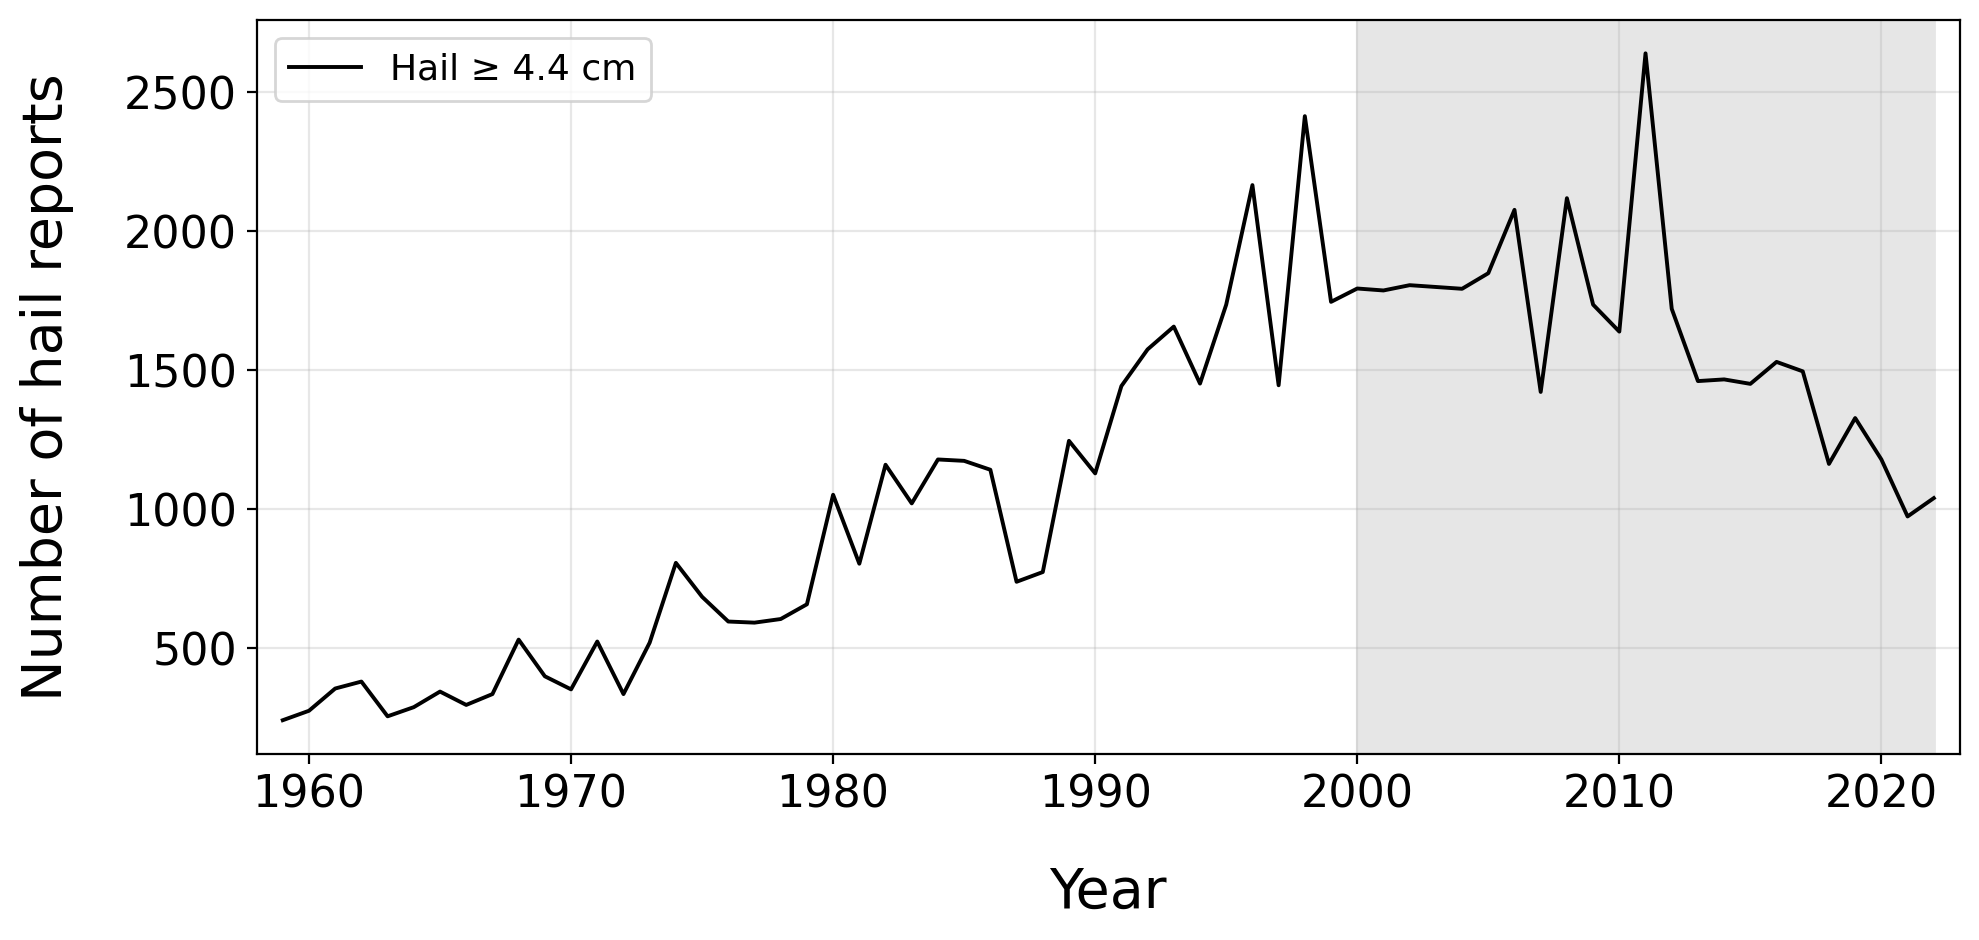

Saved figure to:
/cluster/home/agebhardt/plots/SPC_yearly_number_hail_reports_1959-2022_sig_hail_size_shaded.png


In [3]:
# ============================================================
# SPC yearly number of significant hail reports
# ============================================================
threshold_cm = 4.4

hail_bin = rgrNOAAObs[0].astype(np.float32)
hail_size = rgrNOAAObs[1].astype(np.float32)

sig_hail = (
    (hail_bin == 1)
    & np.isfinite(hail_size)
    & (hail_size >= threshold_cm)
)

years = np.unique(rgdTimeDD.year)
yearly_counts = np.full(len(years), np.nan, dtype=np.float32)

for i, year in enumerate(years):
    mask_year = rgdTimeDD.year == year
    yearly_counts[i] = np.nansum(sig_hail[mask_year, :, :])

# optional: remove missing year if still present
valid = years != missing_year
years_plot = years[valid]
counts_plot = yearly_counts[valid]

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=200)

ax.axvspan(2000, 2022, color="0.9", zorder=0)

ax.plot(
    years_plot,
    counts_plot,
    color="black",
    lw=1.4,
    label="Hail ≥ 4.4 cm",
)

ax.set_xlabel("Year", fontsize=20, labelpad=18)
ax.set_ylabel("Number of hail reports", fontsize=20, labelpad=18)

ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)

ax.legend(
    loc="upper left",
    fontsize=13,
    frameon=True,
)

ax.set_xlim(1958, 2023)

plt.tight_layout()

outpath = Path("/cluster/home/agebhardt/plots/SPC_yearly_number_hail_reports_1959-2022_sig_hail_size_shaded.png")
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to:\n{outpath}")

(2000, 2004) 0.00019600417909300405
(2005, 2014) 0.0001981432347292339
(2015, 2022) 0.00013878562943032247
1959: 0.000026
1960: 0.000030
1961: 0.000039
1962: 0.000042
1963: 0.000028
1964: 0.000031
1965: 0.000038
1966: 0.000032
1967: 0.000037
1968: 0.000058
1969: 0.000044
1970: 0.000038
1971: 0.000057
1972: 0.000037
1973: 0.000057
1974: 0.000088
1975: 0.000075
1976: 0.000065
1977: 0.000065
1978: 0.000066
1979: 0.000072
1980: 0.000115
1981: 0.000088
1982: 0.000127
1983: 0.000112
1984: 0.000129
1985: 0.000128
1986: 0.000125
1987: 0.000081
1988: 0.000084
1989: 0.000136
1990: 0.000123
1991: 0.000158
1992: 0.000172
1993: 0.000181
1994: 0.000159
1995: 0.000190
1996: 0.000236
1997: 0.000158
1998: 0.000264
1999: 0.000191
2000: 0.000196
2001: 0.000195
2002: 0.000197
2004: 0.000196
2005: 0.000202
2006: 0.000227
2007: 0.000155
2008: 0.000231
2009: 0.000190
2010: 0.000179
2011: 0.000289
2012: 0.000188
2013: 0.000160
2014: 0.000160
2015: 0.000159
2016: 0.000167
2017: 0.000164
2018: 0.000127
2019: 0.

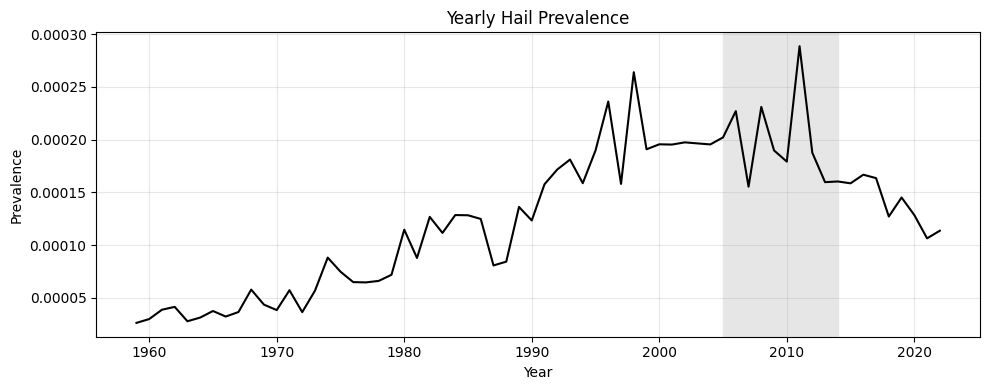

In [6]:
def compute_prevalence(sig_hail, dates, start, end):
    mask = (dates.year >= start) & (dates.year <= end)
    total = np.sum(mask) * sig_hail.shape[1] * sig_hail.shape[2]
    positives = np.nansum(sig_hail[mask])
    return positives / total
    
for p in [(2000,2004),(2005,2014),(2015,2022)]:
    print(p, compute_prevalence(sig_hail, rgdTimeDD, *p))

def compute_yearly_prevalence(sig_hail, dates):
    years = np.unique(dates.year)
    prevalence = {}

    for year in years:
        mask = dates.year == year
        
        total = np.sum(mask) * sig_hail.shape[1] * sig_hail.shape[2]
        positives = np.nansum(sig_hail[mask])
        
        prevalence[year] = positives / total

    return prevalence


# compute
yearly_prev = compute_yearly_prevalence(sig_hail, rgdTimeDD)

# print nicely
for y in sorted(yearly_prev.keys()):
    print(f"{y}: {yearly_prev[y]:.6f}")

years = np.array(list(yearly_prev.keys()))
prev_vals = np.array(list(yearly_prev.values()))

plt.figure(figsize=(10,4))
plt.plot(years, prev_vals, color="black", lw=1.5)
plt.axvspan(2005, 2014, color="0.9", zorder=0)

plt.xlabel("Year")
plt.ylabel("Prevalence")
plt.title("Yearly Hail Prevalence")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Land-Sea Mask 

In [2]:
# ============================================================
# Land-sea mask on the FINAL target grids (robust)
# ============================================================
with Dataset(lsm_file, mode="r") as nc:
    lsm = np.squeeze(nc.variables["lsm"][:]).astype(np.float32)

# --- US LSM ---
idx_lat_glob_us = np.where((rgrLat >= us_lat_min) & (rgrLat <= us_lat_max))[0]
idx_lon_glob_us = np.where((rgrLon >= us_lon_min) & (rgrLon <= us_lon_max))[0]
LSM_US = lsm[idx_lat_glob_us][:, idx_lon_glob_us]

print("LSM_US shape:", LSM_US.shape)
print("Predictor US shape:", rgrERAVarall_US.shape[-2:])

# --- EU LSM ---
idx_lat_glob_eu = np.where((rgrLat >= eu_lat_min) & (rgrLat <= eu_lat_max))[0]
idx_lon_glob_eu = np.where((rgrLon >= eu_lon_min) & (rgrLon <= eu_lon_max))[0]
LSM_EU = lsm[idx_lat_glob_eu][:, idx_lon_glob_eu]

print("LSM_EU shape:", LSM_EU.shape)
print("Predictor EU shape:", rgrERAVarall_EU.shape[-2:])

LSM_US shape: (96, 261)
Predictor US shape: (96, 261)
LSM_EU shape: (121, 181)
Predictor EU shape: (121, 181)


## Population Density Mask 

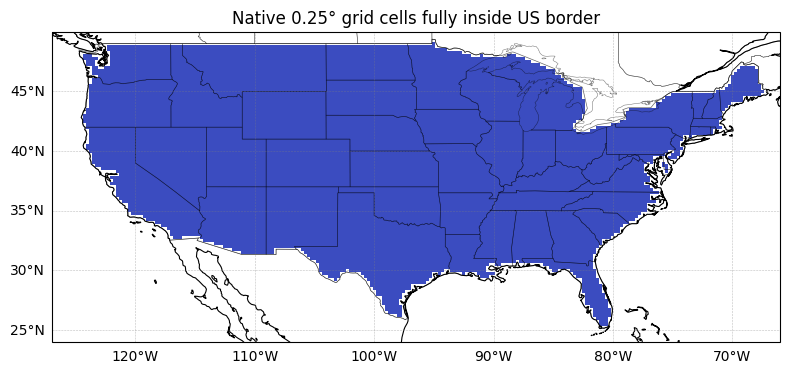

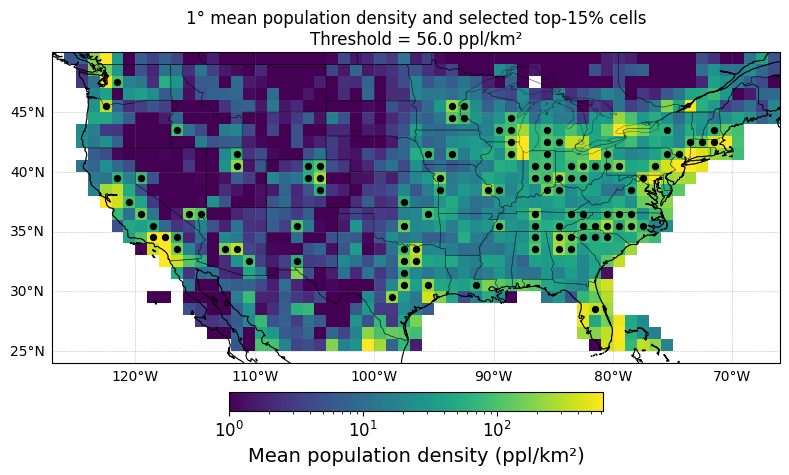

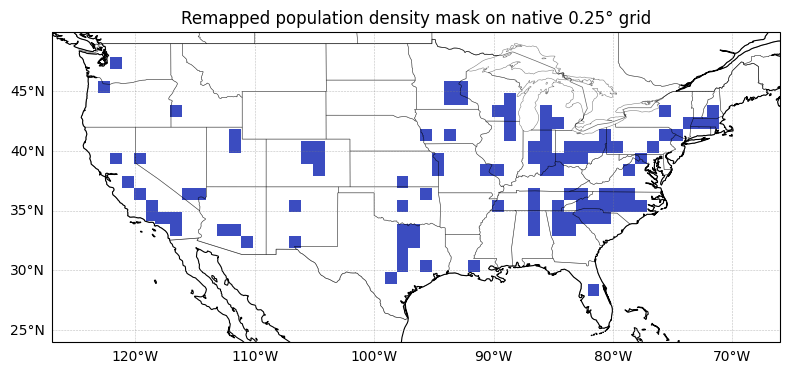

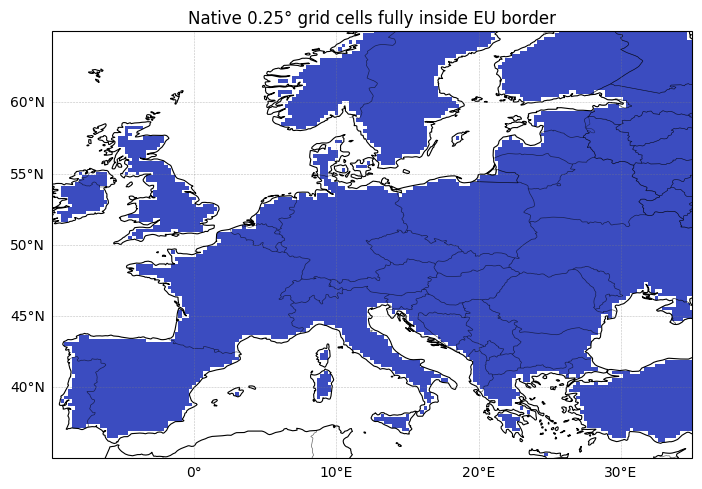

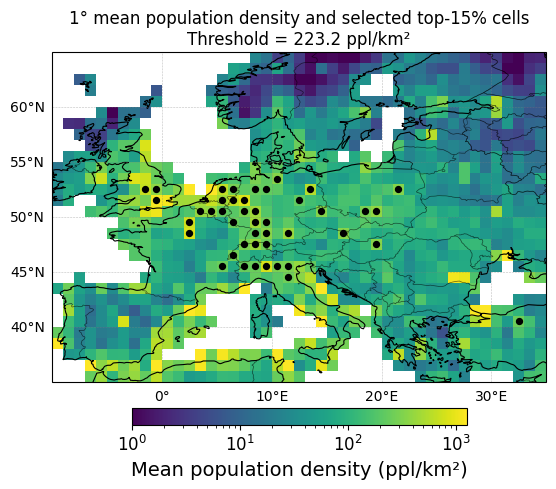

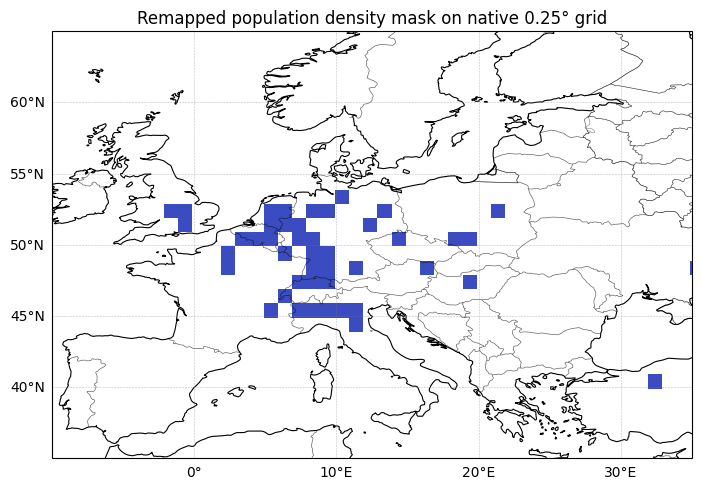

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data = np.load("/nfs/cumulus/highres_nobackup/agebhardt/gpw/population_masks_native_and_1deg.npz")

# US
popmask_us_back = data["popmask_us_back"]
popmask_us_1deg = data["popmask_us_1deg"]
popdens_us_1deg = data["popdens_us_1deg"]
us_fullcell_mask = data["us_fullcell_mask"]

lat_us = data["lat_us"]
lon_us = data["lon_us"]
lat_us_1deg = data["lat_us_1deg"]
lon_us_1deg = data["lon_us_1deg"]

thr_us = float(data["thr_us"])

# 2D grids
lon2d_us, lat2d_us = np.meshgrid(lon_us, lat_us)
lon2d_us_1deg, lat2d_us_1deg = np.meshgrid(lon_us_1deg, lat_us_1deg)

# EU
popmask_eu_back = data["popmask_eu_back"]
popmask_eu_1deg = data["popmask_eu_1deg"]
popdens_eu_1deg = data["popdens_eu_1deg"]
eu_fullcell_mask = data["eu_fullcell_mask"]

lat_eu = data["lat_eu"]
lon_eu = data["lon_eu"]
lat_eu_1deg = data["lat_eu_1deg"]
lon_eu_1deg = data["lon_eu_1deg"]

thr_eu = float(data["thr_eu"])

# 2D grids
lon2d_eu, lat2d_eu = np.meshgrid(lon_eu, lat_eu)
lon2d_eu_1deg, lat2d_eu_1deg = np.meshgrid(lon_eu_1deg, lat_eu_1deg)

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def setup_us_map(figsize=(8, 5)):
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-127, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="black", alpha=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False

    return fig, ax


# ------------------------------------------------------------
# 1) native 0.25° cells fully inside US
# ------------------------------------------------------------
fig, ax = setup_us_map()

mask_plot = np.ma.masked_where(~us_fullcell_mask, us_fullcell_mask)

ax.pcolormesh(
    lon2d_us,
    lat2d_us,
    mask_plot,
    cmap="coolwarm",
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.set_title("Native 0.25° grid cells fully inside US border")
plt.tight_layout()
# plt.savefig("/cluster/home/agebhardt/plots/us_fullcell_mask_native025.png", dpi=200, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 2) 1° mean population density map + selected cells as black dots
# ------------------------------------------------------------
fig, ax = setup_us_map()

popdens_1deg_np = np.asarray(popdens_us_1deg)
finite_pop = popdens_1deg_np[np.isfinite(popdens_1deg_np)]

pcm = ax.pcolormesh(
    lon2d_us_1deg,
    lat2d_us_1deg,
    popdens_1deg_np,
    cmap="viridis",
    norm=colors.LogNorm(
        vmin=max(1, np.nanmin(finite_pop)),
        vmax=np.nanpercentile(finite_pop, 99),
    ),
    shading="auto",
    transform=ccrs.PlateCarree(),
)

sel_y, sel_x = np.where(np.asarray(popmask_us_1deg))

ax.scatter(
    lon2d_us_1deg[sel_y, sel_x],
    lat2d_us_1deg[sel_y, sel_x],
    s=18,
    c="black",
    marker="o",
    transform=ccrs.PlateCarree(),
    label="Selected 1° cells",
)

cbar = plt.colorbar(
    pcm, 
    ax=ax, 
    orientation="horizontal", 
    pad=0.07,
    fraction=0.045,
    shrink=0.75,
)
cbar.set_label("Mean population density (ppl/km²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ax.legend(
#     frameon=True,
#     framealpha=0,
#     loc="lower left", 
# )
ax.set_title(f"1° mean population density and selected top-15% cells\nThreshold = {thr_us:.1f} ppl/km²")

plt.tight_layout()
plt.savefig("/cluster/home/agebhardt/plots/us_popdens_1deg_selected.png", dpi=200, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 3) remapped native 0.25° mask
# ------------------------------------------------------------
fig, ax = setup_us_map()

mask_plot = np.ma.masked_where(~popmask_us_back, popmask_us_back)

ax.pcolormesh(
    lon2d_us,
    lat2d_us,
    mask_plot,
    cmap="coolwarm",
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.set_title("Remapped population density mask on native 0.25° grid")
plt.tight_layout()
# plt.savefig("/cluster/home/agebhardt/plots/us_popmask_back_native025.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def setup_eu_map(figsize=(8, 5)):
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-10, 35, 35, 65], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="black", alpha=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False

    return fig, ax
    
# ------------------------------------------------------------
# 1) native 0.25° cells fully inside EU
# ------------------------------------------------------------
fig, ax = setup_eu_map()

mask_plot = np.ma.masked_where(~eu_fullcell_mask, eu_fullcell_mask)

ax.pcolormesh(
    lon2d_eu,
    lat2d_eu,
    mask_plot,
    cmap="coolwarm",
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.set_title("Native 0.25° grid cells fully inside EU border")
plt.tight_layout()
# plt.savefig("/cluster/home/agebhardt/plots/eu_fullcell_mask_native025.png", dpi=200, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 2) 1° mean population density map + selected cells as black dots
# ------------------------------------------------------------
fig, ax = setup_eu_map()

popdens_1deg_np = np.asarray(popdens_eu_1deg)
finite_pop = popdens_1deg_np[np.isfinite(popdens_1deg_np)]

pcm = ax.pcolormesh(
    lon2d_eu_1deg,
    lat2d_eu_1deg,
    popdens_1deg_np,
    cmap="viridis",
    norm=colors.LogNorm(
        vmin=max(1, np.nanmin(finite_pop)),
        vmax=np.nanpercentile(finite_pop, 99),
    ),
    shading="auto",
    transform=ccrs.PlateCarree(),
)

sel_y, sel_x = np.where(np.asarray(popmask_eu_1deg))

ax.scatter(
    lon2d_eu_1deg[sel_y, sel_x],
    lat2d_eu_1deg[sel_y, sel_x],
    s=18,
    c="black",
    marker="o",
    transform=ccrs.PlateCarree(),
    label="Selected 1° cells",
)

cbar = plt.colorbar(
    pcm, 
    ax=ax, 
    orientation="horizontal", 
    pad=0.07,
    fraction=0.045,
    shrink=0.75,
)
cbar.set_label("Mean population density (ppl/km²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ax.legend(
#     frameon=True, 
#     framealpha=0,
#     loc="lower left"
# )
ax.set_title(f"1° mean population density and selected top-15% cells\nThreshold = {thr_eu:.1f} ppl/km²")

plt.tight_layout()
plt.savefig("/cluster/home/agebhardt/plots/eu_popdens_1deg_selected.png", dpi=200)
plt.show()


# ------------------------------------------------------------
# 3) remapped native 0.25° mask
# ------------------------------------------------------------
fig, ax = setup_eu_map()

mask_plot = np.ma.masked_where(~popmask_eu_back, popmask_eu_back)

ax.pcolormesh(
    lon2d_eu,
    lat2d_eu,
    mask_plot,
    cmap="coolwarm",
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.set_title("Remapped population density mask on native 0.25° grid")
plt.tight_layout()
# plt.savefig("/cluster/home/agebhardt/plots/eu_popmask_back_native025.png", dpi=200, bbox_inches="tight")
plt.show()


## CV Settings

In [4]:
# ============================================================
# CV settings: non-overlapping 2-available-year blocks (cyclic)
# ============================================================
n_folds = 11 # total 11
year_start = 2000
year_end = 2022 # 2022
# exclude_years = [2011]

all_years = pd.DatetimeIndex(rgdTimeDD).year.to_numpy()
years_all = np.unique(all_years)
years_span = years_all[(years_all >= year_start) & (years_all <= year_end)]
# years_span = years_span[~np.isin(years_span, exclude_years)]

# map year -> daily indices
idx_by_year = {int(y): np.where(all_years == y)[0] for y in years_span}

# ------------------------------------------------------------
# build NON-overlapping blocks from the next two AVAILABLE years
# ------------------------------------------------------------
years_list = sorted(years_span.tolist())

if len(years_list) % 2 != 0:
    raise RuntimeError(
        f"Number of available years is odd ({len(years_list)}). "
        "Cannot split cleanly into 2-year blocks."
    )

blocks = [
    np.array(years_list[i:i+2], dtype=int)
    for i in range(0, len(years_list), 2)
]

blocks = blocks[:n_folds]
n_blocks = len(blocks)

# ------------------------------------------------------------
# assign test / val / train (cyclic rotation)
# ------------------------------------------------------------
fold_test_years = []
fold_val_years = []
fold_train_years = []

for i in range(n_blocks):
    test_block = blocks[i]
    val_block = blocks[(i + 1) % n_blocks]   # next block, cyclic

    train_years = np.array(
        sorted(set(years_span.tolist()) - set(test_block.tolist()) - set(val_block.tolist())),
        dtype=int,
    )

    fold_test_years.append(test_block)
    fold_val_years.append(val_block)
    fold_train_years.append(train_years)

# ------------------------------------------------------------
# convert year blocks -> daily indices
# ------------------------------------------------------------
fold_test = [
    np.sort(np.concatenate([idx_by_year[int(y)] for y in block]))
    for block in fold_test_years
]

fold_val = [
    np.sort(np.concatenate([idx_by_year[int(y)] for y in block]))
    for block in fold_val_years
]

fold_train = [
    np.sort(np.concatenate([idx_by_year[int(y)] for y in years]))
    for years in fold_train_years
]

# ------------------------------------------------------------
# print summary + sanity checks
# ------------------------------------------------------------
for i in range(n_blocks):
    test_y = fold_test_years[i]
    val_y = fold_val_years[i]
    train_y = fold_train_years[i]

    assert not np.intersect1d(test_y, val_y).size
    assert not np.intersect1d(test_y, train_y).size
    assert not np.intersect1d(val_y, train_y).size

    print(
        f"Fold {i:02d} | "
        f"test={test_y.tolist()} | "
        f"val={val_y.tolist()} | "
        f"train={train_y.tolist()} | "
        f"n_train_days={len(fold_train[i])} | "
        f"n_val_days={len(fold_val[i])} | "
        f"n_test_days={len(fold_test[i])}"
    )

Fold 00 | test=[2000, 2001] | val=[2002, 2004] | train=[2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022] | n_train_days=6574 | n_val_days=731 | n_test_days=731
Fold 01 | test=[2002, 2004] | val=[2005, 2006] | train=[2000, 2001, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022] | n_train_days=6575 | n_val_days=730 | n_test_days=731
Fold 02 | test=[2005, 2006] | val=[2007, 2008] | train=[2000, 2001, 2002, 2004, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022] | n_train_days=6575 | n_val_days=731 | n_test_days=730
Fold 03 | test=[2007, 2008] | val=[2009, 2010] | train=[2000, 2001, 2002, 2004, 2005, 2006, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022] | n_train_days=6575 | n_val_days=730 | n_test_days=731
Fold 04 | test=[2009, 2010] | val=[2011, 2012] | train=[2000, 2001, 2002, 2004, 2005, 2006, 2007, 2008, 2013, 2014, 2015, 20

In [7]:
# ============================================================
# 2) Output folders (per run date)
# ============================================================
#run_date = datetime.now().strftime("%Y%m%d")
run_date = "python_test"

models_dir = Path("/cluster/home/agebhardt/models") / run_date
preds_dir = Path("/cluster/home/agebhardt/predictions") / run_date
stats_dir = Path("/cluster/home/agebhardt/statistics") / run_date
plots_dir = Path("/cluster/home/agebhardt/plots") / run_date
    
for d in (models_dir, preds_dir, stats_dir, plots_dir):
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# 3) function for hail stats
# ============================================================
def split_80_20(idxs, rng):
        """Return (train_idxs, val_idxs) indices within the fold-training timeline."""
        Tm = idxs.size
        if Tm == 0:
            return np.array([], dtype=int), np.array([], dtype=int)
            
        perm = rng.permutation(idxs)
        
        # target ~20% validation, but never empty training if possible
        n_val = int(np.round(0.2 * Tm))
        if Tm >= 2:
            n_val = min(max(n_val, 1), Tm - 1)   # ensures at least 1 train when Tm>0
        else:
            n_val = 0
        
        val = np.sort(perm[:n_val])
        tr  = np.sort(perm[n_val:])
        return tr, val
    
def add_hail_stats_rows(hail_stats_rows, fold, dataset_name,
                        months_flat, hb_flat, sz_flat,
                        threshold_cm,
                        ds_ratio=None, ds_div_factor=None):
    """
    Append per-month hail stats to hail_stats_rows.
    hb_flat, sz_flat, months_flat are 1D arrays (only valid land points).
    """
    for m in range(1, 13):
        mask_m = (months_flat == m)
        if not np.any(mask_m):
            continue

        hb_m = hb_flat[mask_m]
        sz_m = sz_flat[mask_m]

        large = np.sum((hb_m == 1) & (sz_m >= threshold_cm))
        small = np.sum((hb_m == 1) & (sz_m < threshold_cm))
        no_h = np.sum(hb_m == 0)

        hail_stats_rows.append({
            "fold": fold,
            "dataset": dataset_name,
            "month": m,
            "large_hail": int(large),
            "small_hail": int(small),
            "no_hail": int(no_h),
            "ds_ratio": ds_ratio,
            "ds_div_factor": ds_div_factor,
        })

def add_daylevel_stats_rows(rows, fold, dataset_name, dates_1d, event_day_1d):
    """
    Count hail days vs no-hail days per month.
    
    dates_1d     : (T,) datetime-like
    event_day_1d : (T,) bool, True = hail day
    """
    months = pd.DatetimeIndex(dates_1d).month.to_numpy()

    for m in range(1, 13):
        sel = (months == m)
        if not np.any(sel):
            continue

        hail_days = int(np.sum(event_day_1d[sel]))
        n_days    = int(sel.sum())

        rows.append({
            "fold": fold,
            "dataset": dataset_name,
            "month": m,
            "hail_days": hail_days,
            "no_hail_days": n_days - hail_days,
            "n_days_total": n_days,
        })

def brier_score(y_true, p):
    """Mean squared error for probabilities."""
    y_true = np.asarray(y_true, dtype=np.float32)
    p = np.asarray(p, dtype=np.float32)
    return float(np.mean((p - y_true) ** 2))
        
def brier_skill_score(y_true, p, p_ref):
    """
    BSS = 1 - BS(p)/BS(p_ref)
    p_ref can be a scalar climatology or an array of same shape as y_true.
    """
    y_true = np.asarray(y_true, dtype=np.float32)
    p = np.asarray(p, dtype=np.float32)
        
    if np.isscalar(p_ref):
        p_ref = np.full_like(p, float(p_ref), dtype=np.float32)
    else:
        p_ref = np.asarray(p_ref, dtype=np.float32)
        
    bs = np.mean((p - y_true) ** 2)
    bs_ref = np.mean((p_ref - y_true) ** 2)
        
    # avoid divide-by-zero if the sample has no variance (all 0 or all 1)
    if bs_ref == 0:
        return np.nan
        
    return float(1.0 - (bs / bs_ref))

def compute_threshold_metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
        
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        
    metrics = {
        "thr": float(thr),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if (y_pred.sum() not in (0, len(y_pred))) else np.nan,
    }
    return metrics

In [13]:
# ============================================================
# 4) run containers
# ============================================================
cv_results = []
hail_stats_rows = []
day_stats_rows = []

# ============================================================
# 5) CV LOOP
# ============================================================
for ii, (tr_idx, te_idx) in enumerate(zip(fold_train, fold_test)):
    # US
    # ============================================================
    # A) Fold-level settings
    # ============================================================
    threshold_cm = 4.4
    ds_factor = 17
    april_month = 4
    april_neg_keep_frac = 1 # keep 70% of April negatives BEFORE normal ds_factor downsampling

    print("\n" + "="*70)
    print(
        f"FOLD {ii:02d} | "
        f"train_days={len(tr_idx)} | test_days={len(te_idx)} | "
        f"thr={threshold_cm:.1f}cm | ds_factor={ds_factor} | "
    )
    print("="*70)

    # ============================================================
    # B) Load OUTER-TRAIN hail observations (grid cubes) + land mask
    # ============================================================    
    hail_bin_US = rgrNOAAObs[0,:,:,:] 
    hail_size_US = rgrNOAAObs[1,:,:,:]

    hail_bin_EU = rgrESSLObs[0,:,:,:]
    hail_size_EU = rgrESSLObs[1,:,:,:]

    # --- US cubes on outer-train days
    y_hb_US = np.array(hail_bin_US[tr_idx,:,:]).astype(float)
    y_sz_US = np.array(hail_size_US[tr_idx,:,:]).astype(float)
    y_hb_US[:,LSM_US < 0.5] = np.nan
    y_sz_US[:,LSM_US < 0.5] = np.nan

    # --- EU cubes on outer-train days
    y_hb_EU = np.array(hail_bin_EU[tr_idx,:,:]).astype(float)
    y_sz_EU = np.array(hail_size_EU[tr_idx,:,:]).astype(float)
    y_hb_EU[:,LSM_EU < 0.5] = np.nan
    y_sz_EU[:,LSM_EU < 0.5] = np.nan

    # ============================================================
    # C) Day-level vectors (shared) + SHARED STRATIFIED SPLIT
    #     strata = month × {none, US-only, EU-only, both}
    # ============================================================
    dates = pd.to_datetime(rgdTimeDD[tr_idx])
    months = dates.month.to_numpy()

    large_cell_US = (y_hb_US == 1) & (y_sz_US >= threshold_cm)   # shape (T, H, W)
    event_day_US  = np.any(large_cell_US, axis=(1, 2)) # shape (T,)
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="US_train_100_noDS_days", dates_1d=dates, event_day_1d=event_day_US)

    large_cell_EU = (y_hb_EU == 1) & (y_sz_EU >= threshold_cm)   # shape (T, H, W)
    event_day_EU  = np.any(large_cell_EU, axis=(1, 2)) # shape (T,)
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="EU_train_100_noDS_days", dates_1d=dates, event_day_1d=event_day_EU)

    # 4-class label: 0=none, 1=US-only, 2=EU-only, 3=both
    cls = (event_day_US.astype(np.int8) * 1) + (event_day_EU.astype(np.int8) * 2)
    # unique strata id per (month, cls)
    strata = months * 10 + cls  # safe (month 1..12, cls 0..3)
    # --- day stats
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="outer_train_days_anyRegion", dates_1d=dates, event_day_1d=(event_day_US | event_day_EU))

    # --- shared stratified 80/20 split by strata
    tr_days_list, val_days_list = [], []
    for s in np.unique(strata):
        idx_s = np.where(strata == s)[0]
        if idx_s.size == 0:
            continue
        rng_s = np.random.default_rng(42 + ii + int(s))
        tr_s, val_s = split_80_20(idx_s, rng_s)
        tr_days_list.append(tr_s)
        val_days_list.append(val_s)

    tr_days  = np.sort(np.concatenate(tr_days_list))  if tr_days_list  else np.array([], dtype=int)
    val_days = np.sort(np.concatenate(val_days_list)) if val_days_list else np.array([], dtype=int)

    # shared sanity printout
    def _count_by_cls(idx_days):
        c = cls[idx_days]
        return {
            "none": int(np.sum(c == 0)),
            "US_only": int(np.sum(c == 1)),
            "EU_only": int(np.sum(c == 2)),
            "both": int(np.sum(c == 3)),
        }

    print(
        f"[SPLIT shared] train_days={tr_days.size} | val_days={val_days.size}\n"
        f"  train cls: {_count_by_cls(tr_days)}\n"
        f"  val   cls: {_count_by_cls(val_days)}"
    )

    # shared split day stats (any-region)
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="inner_train_days_anyRegion",
                            dates_1d=dates[tr_days], event_day_1d=(event_day_US[tr_days] | event_day_EU[tr_days]))
    
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="inner_val_days_anyRegion",
                            dates_1d=dates[val_days], event_day_1d=(event_day_US[val_days] | event_day_EU[val_days]))
    
    # region-specific day stats for the SAME split days
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="US_train_80_noDS_days",
                            dates_1d=dates[tr_days], event_day_1d=event_day_US[tr_days])
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="US_val_20_noDS_days",
                            dates_1d=dates[val_days], event_day_1d=event_day_US[val_days])
    
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="EU_train_80_noDS_days",
                            dates_1d=dates[tr_days], event_day_1d=event_day_EU[tr_days])
    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="EU_val_20_noDS_days",
                            dates_1d=dates[val_days], event_day_1d=event_day_EU[val_days])

    # ============================================================
    # D) REGION-SPECIFIC BUILD (US) using SHARED tr_days/val_days
    # ============================================================
    # --- masks    
    land_mask_US = ~np.isnan(y_hb_US)  # (T,96,300), land_mask is masking the land grid
    popmask_us_3d = np.broadcast_to(popmask_us_buffer.astype(bool), y_hb_US.shape)
    train_mask_flat_US = popmask_us_3d[land_mask_US]

    # --- month cube (for outer-train stats / flattening)
    month_3d_US = np.broadcast_to(months[:, None, None], y_hb_US.shape)
    
    # --- land masks for inner train/val (same day indices, region-specific land)
    land_mask3d_tr_US = np.zeros_like(land_mask_US, dtype=bool)
    land_mask3d_val_US  = np.zeros_like(land_mask_US, dtype=bool)
    land_mask3d_tr_US[tr_days] = land_mask_US[tr_days]
    land_mask3d_val_US[val_days]  = land_mask_US[val_days]

    # --- OUTER TRAIN (100% noDS)
    month_flat_train_US = month_3d_US[land_mask_US]
    y_train_hb_US = y_hb_US[land_mask_US]
    y_train_sz_US = y_sz_US[land_mask_US] 
    y_train_US = np.where(y_train_hb_US == 1, (y_train_sz_US >= threshold_cm).astype(np.int8), 0)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="US_100_train_noDS",
        months_flat=month_flat_train_US, hb_flat=y_train_hb_US, sz_flat=y_train_sz_US,
        threshold_cm=threshold_cm, ds_ratio=None, ds_div_factor=None,
    )
    # --- OUTER TRAIN (100% DS)
    idx_noReport = np.where((y_train_hb_US == 0) & (train_mask_flat_US))[0]
    idx_noReport_raw = idx_noReport.copy()

    mask_april = (month_flat_train_US == april_month)
    idx_noReport_april = idx_noReport[mask_april[idx_noReport]]
    idx_noReport_other = idx_noReport[~mask_april[idx_noReport]]

    n_keep_april = int(np.floor(april_neg_keep_frac * idx_noReport_april.size))
    if idx_noReport_april.size > 0 and n_keep_april < idx_noReport_april.size:
        rng_apr = np.random.default_rng(1000 + ii)
        idx_noReport_april = rng_apr.choice(idx_noReport_april, size=n_keep_april, replace=False)

    idx_noReport = np.sort(np.concatenate([idx_noReport_other, idx_noReport_april]))

    idx_largeHail = np.where((y_train_hb_US == 1) & (y_train_sz_US >= threshold_cm))[0]

    rng100 = np.random.default_rng(123 + ii)
    n_sel = int(len(idx_noReport) / ds_factor) if len(idx_noReport) > 0 else 0
    sel_noReport = rng100.choice(idx_noReport, size=n_sel, replace=False) if n_sel > 0 else np.array([], dtype=int)
    idx_keep_US = np.sort(np.concatenate((sel_noReport, idx_largeHail)))

    y_train_bal_US = y_train_US[idx_keep_US]
    X_train_bal_US = None  # filled below once predictors are built
    
    # compute ds_ratio_100_US for inner DS sizing
    pos = int(np.sum(y_train_bal_US == 1))
    neg = int(np.sum(y_train_bal_US == 0))
    ds_ratio_100_US = neg / max(1, pos)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="US_100_train_DS",
        months_flat=month_flat_train_US[idx_keep_US],
        hb_flat=y_train_hb_US[idx_keep_US], sz_flat=y_train_sz_US[idx_keep_US],
        threshold_cm=threshold_cm, ds_ratio=ds_ratio_100_US,
        ds_div_factor=(len(idx_noReport_raw) / max(1, len(sel_noReport))),
    )

    # --- predictors outer-train US
    X_grid_US = np.copy(rgrERAVarall_US[tr_idx, :, :, :]).astype(np.float32)
    X_grid_US[:, :, LSM_US < 0.5] = np.nan
    X_f_tyx_US = np.moveaxis(X_grid_US, 1, 0)  # (F,T,Y,X)
    X_f_valid_US = X_f_tyx_US[:, land_mask_US]  # (F,N)

    X_f_valid_US[ix_vs03, :] = np.abs(X_f_valid_US[ix_vs03, :])
    X_f_valid_US[ix_vs06, :] = np.abs(X_f_valid_US[ix_vs06, :])

    X_train_US = X_f_valid_US.T
    X_train_bal_US = X_f_valid_US[:, idx_keep_US].T

    # --- INNER train/val (noDS) US
    month_flat_tr_US  = month_3d_US[land_mask3d_tr_US]
    month_flat_val_US = month_3d_US[land_mask3d_val_US]

    y_tr_hb_US, y_tr_sz_US = y_hb_US[land_mask3d_tr_US], y_sz_US[land_mask3d_tr_US]
    y_val_hb_US, y_val_sz_US = y_hb_US[land_mask3d_val_US], y_sz_US[land_mask3d_val_US]

    y_tr_US = np.where(y_tr_hb_US == 1, (y_tr_sz_US >= threshold_cm).astype(np.int8), 0)
    y_val_US = np.where(y_val_hb_US == 1, (y_val_sz_US >= threshold_cm).astype(np.int8), 0)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="US_80_train_noDS",
        months_flat=month_flat_tr_US, hb_flat=y_tr_hb_US, sz_flat=y_tr_sz_US,
        threshold_cm=threshold_cm, ds_ratio=None, ds_div_factor=None,
    )
    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="US_20_val_noDS",
        months_flat=month_flat_val_US, hb_flat=y_val_hb_US, sz_flat=y_val_sz_US,
        threshold_cm=threshold_cm, ds_ratio=None, ds_div_factor=None,
    )

    # --- INNER train (DS) US (use ds_ratio_100_US as target)
    tr_mask_flat_US = popmask_us_3d[land_mask3d_tr_US]
    idx_noReport = np.where((y_tr_hb_US == 0) & (tr_mask_flat_US))[0]
    idx_noReport_raw_80 = idx_noReport.copy()

    idx_largeHail = np.where((y_tr_hb_US == 1) & (y_tr_sz_US >= threshold_cm))[0]
    n_large = idx_largeHail.size
    neg_needed = int(ds_ratio_100_US * n_large)

    mask_april_tr = (month_flat_tr_US == april_month)
    idx_noReport_april = idx_noReport[mask_april_tr[idx_noReport]]
    idx_noReport_other = idx_noReport[~mask_april_tr[idx_noReport]]

    n_keep_april = int(np.floor(april_neg_keep_frac * idx_noReport_april.size))
    if idx_noReport_april.size > 0 and n_keep_april < idx_noReport_april.size:
        rng_apr = np.random.default_rng(2000 + ii)
        idx_noReport_april = rng_apr.choice(idx_noReport_april, size=n_keep_april, replace=False)

    idx_noReport = np.sort(np.concatenate([idx_noReport_other, idx_noReport_april]))

    rng80 = np.random.default_rng(321 + ii)
    sel_noReport = rng80.choice(idx_noReport, size=min(neg_needed, len(idx_noReport)), replace=False) if len(idx_noReport) > 0 else np.array([], dtype=int)
    idx_keep_US_inner = np.sort(np.concatenate((sel_noReport, idx_largeHail)))

    y_tr_bal_US = y_tr_US[idx_keep_US_inner]

    pos = int(np.sum(y_tr_bal_US == 1))
    neg = int(np.sum(y_tr_bal_US == 0))    
    ds_ratio_80 = neg / max(1, pos)
    ds_div_factor = idx_noReport.size / max(1, sel_noReport.size)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="US_80_train_DS",
        months_flat=month_flat_tr_US[idx_keep_US_inner], hb_flat=y_tr_hb_US[idx_keep_US_inner], sz_flat=y_tr_sz_US[idx_keep_US_inner],
        threshold_cm=threshold_cm, ds_ratio=ds_ratio_80, ds_div_factor=ds_div_factor,
    )

    add_daylevel_stats_rows(
        day_stats_rows, fold=ii, dataset_name="US_80_train_DS_days",
        dates_1d=dates[tr_days],
        event_day_1d=event_day_US[tr_days],
    )

    # predictors inner US
    X_tr_US = X_f_tyx_US[:, land_mask3d_tr_US].T
    X_val_US = X_f_tyx_US[:, land_mask3d_val_US].T
    X_tr_US[:, ix_vs03] = np.abs(X_tr_US[:, ix_vs03]); X_tr_US[:, ix_vs06] = np.abs(X_tr_US[:, ix_vs06])
    X_val_US[:, ix_vs03] = np.abs(X_val_US[:, ix_vs03]); X_val_US[:, ix_vs06] = np.abs(X_val_US[:, ix_vs06])

    X_tr_bal_US = X_tr_US[idx_keep_US_inner, :]

    # --- OUTER TEST US
    y_hb_te_US = np.array(hail_bin_US[te_idx, :, :], dtype=np.float32)
    y_hb_te_US[:, LSM_US < 0.5] = np.nan
    land_mask_te_US = ~np.isnan(y_hb_te_US)
    y_test_hb_US = y_hb_te_US[land_mask_te_US].astype(np.int8)

    y_sz_te_US = np.array(hail_size_US[te_idx, :, :], dtype=np.float32)
    y_sz_te_US[:, LSM_US < 0.5] = np.nan
    y_test_sz_US = y_sz_te_US[land_mask_te_US]
    y_test_US = np.where(y_test_hb_US == 1, (y_test_sz_US >= threshold_cm).astype(np.int8), 0)

    X_grid_te_US = np.copy(rgrERAVarall_US[te_idx, :, :, :]).astype(np.float32)
    X_grid_te_US[:, :, LSM_US < 0.5] = np.nan
    X_f_tyx_te_US = np.moveaxis(X_grid_te_US, 1, 0)
    X_f_valid_te_US = X_f_tyx_te_US[:, land_mask_te_US]
    X_f_valid_te_US[ix_vs03, :] = np.abs(X_f_valid_te_US[ix_vs03, :])
    X_f_valid_te_US[ix_vs06, :] = np.abs(X_f_valid_te_US[ix_vs06, :])
    X_test_US = X_f_valid_te_US.T

    # Save fold indices + the exact test mask used for flattening
    np.save(preds_dir / f"fold{ii}_tr_idx.npy", tr_idx)
    np.save(preds_dir / f"fold{ii}_te_idx.npy", te_idx)
    np.save(preds_dir / f"fold{ii}_land_mask_te_US.npy", land_mask_te_US.astype(np.bool_))
    
    print(f"[SAVE FOLD] fold={ii:02d} | tr_days={len(tr_idx)} te_days={len(te_idx)} "
          f"| land_mask_te_true={int(land_mask_te_US.sum())}")    

    dates_te = pd.to_datetime(rgdTimeDD[te_idx])
    months_te = dates_te.month.to_numpy()
    month_te_3d = np.broadcast_to(months_te[:, None, None], y_hb_te_US.shape)
    month_flat_test = month_te_3d[land_mask_te_US]

    for m in range(1, 13):
        mask_m = (month_flat_test == m)
        if not np.any(mask_m):
            continue
    
        y_m = y_test_US[mask_m]   
        hail_stats_rows.append({
            "fold": ii,
            "dataset": "test_noDS",
            "month": m,
            "large_hail": int((y_m == 1).sum()),
            "small_hail": 0,      # or np.nan if you prefer
            "no_hail": int((y_m == 0).sum()),
            "ds_ratio": None,
            "ds_div_factor": None,
        })

    # ============================================================
    # E) REGION-SPECIFIC BUILD (EU) using SAME tr_days/val_days
    # ============================================================
    threshold_cm = 4.4
    ds_factor = 165
    april_month = 4
    april_neg_keep_frac = 1 # keep 70% of April negatives BEFORE normal ds_factor downsampling

    print("\n" + "="*70)
    print(f"FOLD {ii:02d} | train_days={len(tr_idx)} | test_days={len(te_idx)} | "
        f" | thr={threshold_cm:.1f}cm | ds_factor={ds_factor} | April_neg_keep={april_neg_keep_frac:.0%}")
    print("="*70)

    land_mask_EU = ~np.isnan(y_hb_EU)
    popmask_eu_3d = np.broadcast_to(popmask_eu_buffer.astype(bool), y_hb_EU.shape)
    train_mask_flat_EU = popmask_eu_3d[land_mask_EU]

    month_3d_EU = np.broadcast_to(months[:, None, None], y_hb_EU.shape)

    land_mask3d_tr_EU  = np.zeros_like(land_mask_EU, dtype=bool)
    land_mask3d_val_EU = np.zeros_like(land_mask_EU, dtype=bool)
    land_mask3d_tr_EU[tr_days]   = land_mask_EU[tr_days]
    land_mask3d_val_EU[val_days] = land_mask_EU[val_days]

    # --- OUTER TRAIN (100% noDS) EU
    month_flat_train_EU = month_3d_EU[land_mask_EU]
    y_train_hb_EU = y_hb_EU[land_mask_EU]
    y_train_sz_EU = y_sz_EU[land_mask_EU]
    y_train_EU = np.where(y_train_hb_EU == 1, (y_train_sz_EU >= threshold_cm).astype(np.int8), 0)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="EU_100_train_noDS",
        months_flat=month_flat_train_EU, hb_flat=y_train_hb_EU, sz_flat=y_train_sz_EU,
        threshold_cm=threshold_cm, ds_ratio=None, ds_div_factor=None,
    )
    # --- OUTER TRAIN (100% DS) EU
    idx_noReport = np.where((y_train_hb_EU == 0) & (train_mask_flat_EU))[0]
    idx_noReport_raw = idx_noReport.copy()

    mask_april = (month_flat_train_EU == april_month)
    idx_noReport_april = idx_noReport[mask_april[idx_noReport]]
    idx_noReport_other = idx_noReport[~mask_april[idx_noReport]]

    n_keep_april = int(np.floor(april_neg_keep_frac * idx_noReport_april.size))
    if idx_noReport_april.size > 0 and n_keep_april < idx_noReport_april.size:
        rng_apr = np.random.default_rng(3000 + ii)
        idx_noReport_april = rng_apr.choice(idx_noReport_april, size=n_keep_april, replace=False)

    idx_noReport = np.sort(np.concatenate([idx_noReport_other, idx_noReport_april]))
    idx_largeHail = np.where((y_train_hb_EU == 1) & (y_train_sz_EU >= threshold_cm))[0]

    rng100 = np.random.default_rng(456 + ii)
    n_sel = int(len(idx_noReport) / ds_factor) if len(idx_noReport) > 0 else 0
    sel_noReport = rng100.choice(idx_noReport, size=n_sel, replace=False) if n_sel > 0 else np.array([], dtype=int)
    idx_keep_EU = np.sort(np.concatenate((sel_noReport, idx_largeHail)))

    y_train_bal_EU = y_train_EU[idx_keep_EU]

    pos = int(np.sum(y_train_bal_EU == 1))
    neg = int(np.sum(y_train_bal_EU == 0))
    ds_ratio_100_EU = neg / max(1, pos)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="EU_100_train_DS",
        months_flat=month_flat_train_EU[idx_keep_EU],
        hb_flat=y_train_hb_EU[idx_keep_EU], sz_flat=y_train_sz_EU[idx_keep_EU],
        threshold_cm=threshold_cm, ds_ratio=ds_ratio_100_EU,
        ds_div_factor=(len(idx_noReport_raw) / max(1, len(sel_noReport))),
    )

    add_daylevel_stats_rows(
        day_stats_rows, fold=ii, dataset_name="EU_100_train_DS", 
        dates_1d=dates,
        event_day_1d=event_day_EU,
    )
    # --- predictors outer-train EU
    X_grid_EU = np.copy(rgrERAVarall_EU[tr_idx, :, :, :]).astype(np.float32)
    X_grid_EU[:, :, LSM_EU < 0.5] = np.nan
    X_f_tyx_EU = np.moveaxis(X_grid_EU, 1, 0)
    X_f_valid_EU = X_f_tyx_EU[:, land_mask_EU]

    X_f_valid_EU[ix_vs03, :] = np.abs(X_f_valid_EU[ix_vs03, :])
    X_f_valid_EU[ix_vs06, :] = np.abs(X_f_valid_EU[ix_vs06, :])

    X_train_EU = X_f_valid_EU.T
    X_train_bal_EU = X_f_valid_EU[:, idx_keep_EU].T
    
    # --- INNER train/val (noDS) EU
    month_flat_tr_EU  = month_3d_EU[land_mask3d_tr_EU]
    month_flat_val_EU = month_3d_EU[land_mask3d_val_EU]

    y_tr_hb_EU, y_tr_sz_EU = y_hb_EU[land_mask3d_tr_EU], y_sz_EU[land_mask3d_tr_EU]
    y_val_hb_EU, y_val_sz_EU = y_hb_EU[land_mask3d_val_EU], y_sz_EU[land_mask3d_val_EU]

    y_tr_EU = np.where(y_tr_hb_EU == 1, (y_tr_sz_EU >= threshold_cm).astype(np.int8), 0)
    y_val_EU = np.where(y_val_hb_EU == 1, (y_val_sz_EU >= threshold_cm).astype(np.int8), 0)

    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="EU_80_train_noDS",
        months_flat=month_flat_tr_EU, hb_flat=y_tr_hb_EU, sz_flat=y_tr_sz_EU,
        threshold_cm=threshold_cm, ds_ratio=None, ds_div_factor=None,
    )
    add_hail_stats_rows(
        hail_stats_rows, fold=ii, dataset_name="EU_20_val_noDS",
        months_flat=month_flat_val_EU, hb_flat=y_val_hb_EU, sz_flat=y_val_sz_EU,
        threshold_cm=threshold_cm, ds_ratio=None, ds_div_factor=None,
    )

    # --- INNER train (DS) EU (use ds_ratio_100_EU as target)
    tr_mask_flat_EU = popmask_eu_3d[land_mask3d_tr_EU]
    idx_noReport = np.where((y_tr_hb_EU == 0) & (tr_mask_flat_EU))[0]
    idx_noReport_raw_80 = idx_noReport.copy()

    idx_largeHail = np.where((y_tr_hb_EU == 1) & (y_tr_sz_EU >= threshold_cm))[0]
    n_large = idx_largeHail.size
    neg_needed = int(ds_ratio_100_EU * n_large)

    mask_april_tr = (month_flat_tr_EU == april_month)
    idx_noReport_april = idx_noReport[mask_april_tr[idx_noReport]]
    idx_noReport_other = idx_noReport[~mask_april_tr[idx_noReport]]

    n_keep_april = int(np.floor(april_neg_keep_frac * idx_noReport_april.size))
    if idx_noReport_april.size > 0 and n_keep_april < idx_noReport_april.size:
        rng_apr = np.random.default_rng(4000 + ii)
        idx_noReport_april = rng_apr.choice(idx_noReport_april, size=n_keep_april, replace=False)

    idx_noReport = np.sort(np.concatenate([idx_noReport_other, idx_noReport_april]))

    rng80 = np.random.default_rng(654 + ii)
    sel_noReport = rng80.choice(idx_noReport, size=min(neg_needed, len(idx_noReport)), replace=False) if len(idx_noReport) > 0 else np.array([], dtype=int)
    idx_keep_EU_inner = np.sort(np.concatenate((sel_noReport, idx_largeHail)))

    y_tr_bal_EU = y_tr_EU[idx_keep_EU_inner]

    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="EU_80_train_DS", dates_1d=dates[tr_days], event_day_1d=event_day_EU[tr_days])

    add_daylevel_stats_rows(day_stats_rows, fold=ii, dataset_name="EU_80_train_DS_days", dates_1d=dates[tr_days], event_day_1d=event_day_EU[tr_days])

    # predictors inner EU
    X_tr_EU = X_f_tyx_EU[:, land_mask3d_tr_EU].T
    X_val_EU = X_f_tyx_EU[:, land_mask3d_val_EU].T
    X_tr_EU[:, ix_vs03] = np.abs(X_tr_EU[:, ix_vs03]); X_tr_EU[:, ix_vs06] = np.abs(X_tr_EU[:, ix_vs06])
    X_val_EU[:, ix_vs03] = np.abs(X_val_EU[:, ix_vs03]); X_val_EU[:, ix_vs06] = np.abs(X_val_EU[:, ix_vs06])

    X_tr_bal_EU = X_tr_EU[idx_keep_EU_inner, :]

    # --- OUTER TEST EU
    y_hb_te_EU = np.array(hail_bin_EU[te_idx, :, :], dtype=np.float32)
    y_hb_te_EU[:, LSM_EU < 0.5] = np.nan
    land_mask_te_EU = ~np.isnan(y_hb_te_EU)
    y_test_hb_EU = y_hb_te_EU[land_mask_te_EU].astype(np.int8)

    y_sz_te_EU = np.array(hail_size_EU[te_idx, :, :], dtype=np.float32)
    y_sz_te_EU[:, LSM_EU < 0.5] = np.nan
    y_test_sz_EU = y_sz_te_EU[land_mask_te_EU]
    y_test_EU = np.where(y_test_hb_EU == 1, (y_test_sz_EU >= threshold_cm).astype(np.int8), 0)

    X_grid_te_EU = np.copy(rgrERAVarall_EU[te_idx, :, :, :]).astype(np.float32)
    X_grid_te_EU[:, :, LSM_EU < 0.5] = np.nan
    X_f_tyx_te_EU = np.moveaxis(X_grid_te_EU, 1, 0)
    X_f_valid_te_EU = X_f_tyx_te_EU[:, land_mask_te_EU]
    X_f_valid_te_EU[ix_vs03, :] = np.abs(X_f_valid_te_EU[ix_vs03, :])
    X_f_valid_te_EU[ix_vs06, :] = np.abs(X_f_valid_te_EU[ix_vs06, :])
    X_test_EU = X_f_valid_te_EU.T

    # Save fold indices + the exact test mask used for flattening
    np.save(preds_dir / f"fold{ii}_tr_idx.npy", tr_idx)
    np.save(preds_dir / f"fold{ii}_te_idx.npy", te_idx)
    np.save(preds_dir / f"fold{ii}_land_mask_te_EU.npy", land_mask_te_EU.astype(np.bool_))
    
    print(f"[SAVE FOLD] fold={ii:02d} | tr_days={len(tr_idx)} te_days={len(te_idx)} "
          f"| land_mask_te_true={int(land_mask_te_EU.sum())}")    

    dates_te = pd.to_datetime(rgdTimeDD[te_idx])
    months_te = dates_te.month.to_numpy()
    month_te_3d = np.broadcast_to(months_te[:, None, None], y_hb_te_EU.shape)
    month_flat_test = month_te_3d[land_mask_te_EU]

    for m in range(1, 13):
        mask_m = (month_flat_test == m)
        if not np.any(mask_m):
            continue
    
        y_m = y_test_EU[mask_m]   
        hail_stats_rows.append({
            "fold": ii,
            "dataset": "EU_test_noDS",
            "month": m,
            "large_hail": int((y_m == 1).sum()),
            "small_hail": 0,      # or np.nan if you prefer
            "no_hail": int((y_m == 0).sum()),
            "ds_ratio": None,
            "ds_div_factor": None,
        })

    # ============================================================
    # combining the 2 datasets
    # ============================================================ 
    X_train_bal = np.concatenate((X_train_bal_US, X_train_bal_EU), axis=0)
    X_train_bal = np.nan_to_num(X_train_bal, nan=0)
    y_train_bal = np.concatenate((y_train_bal_US, y_train_bal_EU), axis=0)
    y_train_bal = np.nan_to_num(y_train_bal, nan=0)

    X_test = np.concatenate((X_test_US, X_test_EU), axis=0)
    X_test = np.nan_to_num(X_test, nan=0)
    y_test = np.concatenate((y_test_US, y_test_EU), axis=0)
    y_test = np.nan_to_num(y_test, nan=0)

    X_tr_bal = np.concatenate((X_tr_bal_US, X_tr_bal_EU), axis=0)
    X_tr_bal = np.nan_to_num(X_tr_bal, nan=0)
    y_tr_bal = np.concatenate((y_tr_bal_US, y_tr_bal_EU), axis=0)
    y_tr_bal = np.nan_to_num(y_tr_bal, nan=0)

    X_val = np.concatenate((X_val_US, X_val_EU), axis=0)
    X_val = np.nan_to_num(X_val, nan=0)
    y_val = np.concatenate((y_val_US, y_val_EU), axis=0)
    y_val = np.nan_to_num(y_val, nan=0)

    # ============================================================
    # 5.1) DMatrices
    # ============================================================
    feature_names=list(model_vars)
    dtrain_balanced = xgb.DMatrix(X_train_bal, label=y_train_bal, missing=np.nan, feature_names=feature_names)  # 100% balanced
    dte = xgb.DMatrix(X_test, label=y_test, missing=np.nan, feature_names=feature_names)  # test
    dtr_balanced = xgb.DMatrix(X_tr_bal, label=y_tr_bal, missing=np.nan, feature_names=feature_names)  # 80% balanced
    dval_imbalanced = xgb.DMatrix(X_val, label=y_val, missing=np.nan, feature_names=feature_names)  # 20% val (no DS)

    # ============================================================
    # 5.2) Baseline model (defaults), untuned model
    # ============================================================
    base_params = {
        'objective': 'binary:logistic',
        'tree_method': 'hist',    # 'gpu_hist' if GPU
        'eval_metric': 'aucpr',
    }
    
    trial_params = {
        "learning_rate":    0.1,
        "max_depth":        6,
        "min_child_weight": 1,
        "subsample":        1.0,
        "colsample_bytree": 1.0,
        "alpha":            1,
        "lambda":           1,
    }
    params = {**base_params, **trial_params}    

    evals_result = {}
    baseline_model = xgb.train(
        params=params, 
        dtrain=dtr_balanced, 
        num_boost_round=100, #150 
        evals=[(dtr_balanced, 'train'), (dval_imbalanced, 'valid')],
        early_stopping_rounds=20,
        evals_result=evals_result,
        verbose_eval=False,
    )

    y_pred_proba = baseline_model.predict(dval_imbalanced)
    precision, recall, _= precision_recall_curve(y_val, y_pred_proba)

    average_precision_untuned = average_precision_score(y_val, y_pred_proba)
    aucpr_valid_untuned = auc(recall, precision)
    prevalence_valid = np.mean(y_val)

    # ============================================================
    # 5.3) Optuna tuning on 80% train data and 20% val data
    # ============================================================
    base_params = {
        'objective': 'binary:logistic',
        'tree_method': 'hist',    # 'gpu_hist' if GPU
        'eval_metric': 'aucpr',
        'base_score': float(np.mean(y_tr_bal)),  # prior = pos fraction in 80% DS
    }
    
    def objective(trial):
        trial_params = {      
            "learning_rate":    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            "max_depth":        trial.suggest_int("max_depth", 2, 16, step=1), # 2-10
            "min_child_weight": trial.suggest_float("min_child_weight", 1, 35, log=True),
            
            #"subsample":        trial.suggest_float("subsample", 0.5, 1.0),
            #"colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            
            #"gamma":            trial.suggest_float("gamma", 0.08, 3, log=True), # 1e-8, 4,
            #"alpha":            trial.suggest_float("alpha", 1e-6, 0.1, log=True), # 1e-8, 6,
            #"lambda":           trial.suggest_float("lambda", 1e-7, 0.05, log=False),
        }
        params = {**base_params, **trial_params}

        pruning_cb = XGBoostPruningCallback(trial, "valid-aucpr")
    
        evals_result = {}
        booster_hp_tuning = xgb.train(
            params=params, 
            dtrain=dtr_balanced, 
            num_boost_round=200, #200
            evals=[(dtr_balanced, 'train'), (dval_imbalanced, 'valid')],
            early_stopping_rounds=20,
            #callbacks=[pruning_cb],
            evals_result=evals_result,
            verbose_eval=False,
        )

        # --- Brier metrics on HP VALID (20% imbalanced) per trial ---
        y_val_prob_trial = booster_hp_tuning.predict(dval_imbalanced)
        bs_valid_trial = brier_score(y_val, y_val_prob_trial)
        bss_valid_trial = brier_skill_score(y_val, y_val_prob_trial, p_ref=y_train_bal)

        # store extra info for later inspection
        trial.set_user_attr('best_iteration', int(booster_hp_tuning.best_iteration))
        trial.set_user_attr("best_score", float(booster_hp_tuning.best_score))
        trial.set_user_attr("bs_valid", float(bs_valid_trial))
        trial.set_user_attr("bss_valid", float(bss_valid_trial))
        trial.set_user_attr("evals_result", evals_result)
                    
        return float(booster_hp_tuning.best_score)
    
    sampler = TPESampler(seed=42+ii)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=15,
        n_warmup_steps=30,
        interval_steps=5
    )
    study = optuna.create_study(
        direction='maximize', 
        sampler=sampler) 
        #pruner=pruner)

    study.optimize(
        objective, 
        n_trials=5, 
        show_progress_bar=False
    )

    # ============================================================
    # 5.4) Best trial summary
    # ============================================================
    best_trial = study.best_trial
    best_iter  = best_trial.user_attrs.get("best_iteration")
    best_params = {**base_params, **best_trial.params}
    best_value  = best_trial.value

    bs_valid  = best_trial.user_attrs.get("bs_valid", np.nan)
    bss_valid = best_trial.user_attrs.get("bss_valid", np.nan)

    print(
        f"[OPTUNA] best_AUCPR={best_value:.6f} | "
        f"best_iter={best_iter}"
    )
    print("Best params:")
    for k, v in best_trial.params.items():
        print(f" {k}: {v}")

    # ============================================================
    # 3.2) Top-10 trials (or fewer if <10 completed)
    # ============================================================
    df_trials = study.trials_dataframe(attrs=("number","value","state","params","user_attrs"))
    df_complete = (
        df_trials[df_trials["state"].astype(str).str.contains("COMPLETE", regex=False)]
        .sort_values("value", ascending=False)
        .reset_index(drop=True)
    )
        
    df_top = df_complete.head(11).copy()
    print(f"\n=== Top {len(df_top)} completed trials (best + next {max(0, len(df_top)-1)}) ===")

    # --- save top-11 (best + next 10) -----------------------
    top_csv_path = os.path.join(stats_dir, f"optuna_top11_fold{ii}_v2.csv")
    df_top.to_csv(top_csv_path, index=False)
    print(f"\nSaved top-11 trials to: {top_csv_path}")
        
    # --- save all trials ------------------------------------
    all_csv_path = os.path.join(stats_dir, f"optuna_trials_fold{ii}_v2.csv")
    df_trials.to_csv(all_csv_path, index=False)
    print(f"Saved all Optuna trials to: {all_csv_path}") 
        
    # ============================================================
    # 5.5) Optuna Visualizations
    # ============================================================
    # --- learning rate over boosting rounds -----------------
    curves      = best_trial.user_attrs.get("evals_result")
    train_aucpr = curves.get('train', {}).get('aucpr', [])
    valid_aucpr = curves.get('valid', {}).get('aucpr', [])
    epochs      = range(len(valid_aucpr))
        
    fig = plt.figure(figsize=(6,4))
    plt.plot(epochs, train_aucpr, label='Train')
    plt.plot(epochs, valid_aucpr, label='Valid')

    plt.ylim(0,0.02)
    plt.axhline(prevalence_valid, color="k", ls="--", lw=1, label="Baseline")
    plt.legend()
    plt.xlabel('Number of Boosting Rounds')
    plt.ylabel('AUCPR')
    plt.title('XGBoost AUCPR (best Optuna trial)')

    plots_path = os.path.join(plots_dir, f"aucpr_fold{ii}.png")
    fig.savefig(plots_path, dpi=200, bbox_inches = "tight")
    plt.close(fig)
    print(f"Saved AUCPR plot for fold {ii} to: {plots_path}")

    # --- contour plots --------------------------------------
    # fig_contour_lr_md = plot_contour(
    #     study,
    #     params=["learning_rate","max_depth"],
    # )
    # contour_path = os.path.join(plots_dir, f"optuna_contour_lr_md_fold{ii}_v2.html")
    # fig_contour_lr_md.write_html(contour_path)
    # print(f"Saved Optuna contour plot for fold {ii} to: {contour_path}")

    # fig_contour_mcw_md = plot_contour(
    #     study,
    #     params=["min_child_weight","max_depth"],
    # )
    # contour_path = os.path.join(plots_dir, f"optuna_contour_mcw_md_fold{ii}_v2.html")
    # fig_contour_mcw_md.write_html(contour_path)
    # print(f"Saved Optuna contour plot for fold {ii} to: {contour_path}")

    # ============================================================
    # 5.6) Final model on 100% balanced + validation
    # ============================================================
    model_final = xgb.train(
        params=best_params,
        dtrain=dtrain_balanced,
        num_boost_round=int(best_iter) + 1,
        verbose_eval=False,
    )
    
    # ============================================================
    # 5.7) Predict on test + compute metrics
    # ============================================================
    # make predictions on test set
    y_test_prob = model_final.predict(dte)

    # --- Brier metrics on TEST ---
    bs_test = brier_score(y_test, y_test_prob)
    bss_test = brier_skill_score(y_test, y_test_prob, p_ref=y_train_bal)
    
    # Prob-based metrics
    precision, recall, _= precision_recall_curve(y_test, y_test_prob)
    aucpr_test = auc(recall, precision)
    average_precision_test = average_precision_score(y_test,y_test_prob)

    logloss_test = float(log_loss(y_test, y_test_prob))
    baseline_test = float(np.mean(y_test))

    # PR Curve
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot(recall, precision, linewidth=0.8, label=f"PR curve (AP={average_precision_test:.4f})")
    ax.axhline(baseline_test, linestyle=":", linewidth=2, label=f"Baseline (prevalanece={baseline_test:.4f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_ylim(0,0.08)
    ax.set_title(f"Precision-Recall Curve (Fold {ii:02d})")
    ax.xaxis.set_major_locator(MultipleLocator(0.01))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
        
    pr_curve_path = os.path.join(plots_dir, f"pr_curve_fold{ii:02d}.png")
    fig.savefig(pr_curve_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    # ---- threshold-based metrics (confusion matrix) ----
    thr_metrics_test = compute_threshold_metrics(y_test, y_test_prob, thr=0.48)
    
    # thr = 0.5  # IMPORTANT: consider choosing this from validation later
    # cm = confusion_metrics(y_test, y_test_prob, thr=thr)
    # cm_norm = confusion_matrix_normalized(y_test, y_test_prob, thr=thr, normalize="true")  # row-normalized
    
    # print(
    #     f"[Fold {ii}] AUCROC={aucroc_test:.4f} AUCPR={aucpr_test:.4f} LogLoss={logloss_test:.4f} "
    #     f"| thr={thr:.2f} TP={cm['tp']} FP={cm['fp']} TN={cm['tn']} FN={cm['fn']} "
    #     f"| Acc={cm['accuracy']:.4f} Prec={cm['precision']:.4f} "
    #     f"Sens={cm['sensitivity']:.4f} Spec={cm['specificity']:.4f} F1={cm['f1']:.4f}"
    #)
    
    # ---- ROC + PR plots (per fold) ----
    # plot_prefix = os.path.join(stats_dir, f"plot_roc_pr_fold{ii}")
    # _roc, _pr = plot_roc_pr(
    #     y_true=y_test,
    #     y_prob=y_test_prob,
    #     title_prefix=f"Fold {ii}",
    #     outpath_prefix=plot_prefix
    # )
    
    # ---- normalized confusion matrix plot (per fold) ----
    # plot_confmat(
    #     cm_norm,
    #     title=f"Fold {ii} Confusion Matrix (normalized by true class), thr={thr:.2f}",
    #     outpath=plot_prefix + "_confmat_norm.png",
    # )
    
    # ---- gain + lift (per fold) ----
    # df_gl = gain_lift_by_decile(y_test, y_test_prob, n_bins=10)
    # df_gl.to_csv(os.path.join(stats_dir, f"fold{ii}_gain_lift.csv"), index=False)
    # plot_gain_lift(df_gl, title_prefix=f"Fold {ii}", outpath_prefix=plot_prefix)

    cv_results.append(
        {
            "fold": ii,
            "train_years": ",".join(map(str, np.unique(pd.DatetimeIndex(rgdTimeDD[tr_idx]).year))),
            "test_years":  ",".join(map(str, np.unique(pd.DatetimeIndex(rgdTimeDD[te_idx]).year))),
                
            "aucpr_valid_untuned": float(average_precision_untuned),
            "prevalence_valid": float(prevalence_valid),
                
            "aucpr_valid_tuned": float(best_value),
            "best_iter": int(best_iter),
            **{f"P_{k}": float(v) if isinstance(v, (int, float)) else v for k, v in best_params.items()},
                
            "aucpr_test": float(average_precision_test),
            "logloss_test": float(logloss_test),
            "baseline_test": baseline_test,
                
            # climatology + Brier metrics 
            "clim_y_train": float(np.mean(y_train_bal)),
            "bs_test": float(bs_test),
            "bss_test": float(bss_test),

            "tp": thr_metrics_test["tp"],
            "tn": thr_metrics_test["tn"],
            "fp": thr_metrics_test["fp"],
            "fn": thr_metrics_test["fn"],
            "n_pos_test": int(np.sum(y_test == 1)),
            "n_neg_test": int(np.sum(y_test == 0)),
                
            "acc_thr": thr_metrics_test["accuracy"],
            "prec_thr": thr_metrics_test["precision"],
            "rec_thr": thr_metrics_test["recall"],
            "f1_thr": thr_metrics_test["f1"],
            "mcc_thr": thr_metrics_test["mcc"],
        }
    )
    
    # ============================================================
    # 5.8) Save model + predictions per fold
    # ============================================================
    model_path = os.path.join(models_dir, f"xgb_us_eu_fold{ii}.json")
    model_final.save_model(model_path)

    np.save(os.path.join(preds_dir, f"fold{ii}_y_test_prob.npy"), y_test_prob)

# ============================================================
# SAVE overall results
# ============================================================     
df_cv = pd.DataFrame(cv_results)
print(
    f"[CV] AUCPR max={df_cv['aucpr_test'].max():.6f} | "
    f"median={df_cv['aucpr_test'].median():.6f} | "
    f"mean={df_cv['aucpr_test'].mean():.6f}"
)

df_cv.to_csv(os.path.join(stats_dir, "cv_results_all_folds.csv"), index=False)

df_hail = pd.DataFrame(hail_stats_rows)
df_hail.to_csv(
    os.path.join(stats_dir, "hail_gridcell_days.csv"), index=False)

df_daystats = pd.DataFrame(day_stats_rows)
df_daystats.to_csv(
    os.path.join(stats_dir, "hail_days_train_val.csv"))

print(
    f"[SAVE] model=xgb_us_eu_fold{ii}.json | "
    f"pred=fold{ii}_y_test_prob.npy"
)


FOLD 00 | train_days=7305 | test_days=731 | thr=4.4cm | ds_factor=17 | April_neg_keep=100%
[SPLIT shared] train_days=5843 | val_days=1462
  train cls: {'none': 2931, 'US_only': 2358, 'EU_only': 99, 'both': 455}
  val   cls: {'none': 732, 'US_only': 590, 'EU_only': 25, 'both': 115}
[SAVE FOLD] fold=00 | tr_days=7305 te_days=731 | land_mask_te_true=11508133

FOLD 00 | train_days=7305 | test_days=731 |  | thr=4.4cm | ds_factor=165 | April_neg_keep=100%
[SAVE FOLD] fold=00 | tr_days=7305 te_days=731 | land_mask_te_true=9406508


[I 2026-03-14 15:58:43,480] A new study created in memory with name: no-name-d86b72eb-226b-409b-8366-58dacaec244b
[W 2026-03-14 16:07:27,295] Trial 0 failed with parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 16, 'min_child_weight': 13.49734827452218} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/cluster/home/agebhardt/env/lib/python3.11/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/scratch/tmp.60338669.agebhardt/ipykernel_914610/2004598669.py", line 625, in objective
    y_val_prob_trial = booster_hp_tuning.predict(dval_imbalanced)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cluster/home/agebhardt/env/lib/python3.11/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/cluster/home/agebhardt/env/lib/python3.11/site-packages/xgboost/c

KeyboardInterrupt: 

# Data Analysis

## Outlier in observational data and ERA5

In [5]:
# ============================================================
# Year-month outlier analysis on population-filtered grid cells
# ============================================================

threshold_cm = 4.4

# ------------------------------------------------------------
# 1) Build combined analysis masks
#    keep only land cells AND population-filtered cells
# ------------------------------------------------------------
analysis_mask_us = (LSM_US >= 0.5) & (popmask_us_back.astype(bool))
analysis_mask_eu = (LSM_EU >= 0.5) & (popmask_eu_back.astype(bool))

print("US filtered cells:", int(np.sum(analysis_mask_us)))
print("EU filtered cells:", int(np.sum(analysis_mask_eu)))

# optional sanity checks
print("US mask shape:", analysis_mask_us.shape, " | NOAA shape:", rgrNOAAObs.shape[-2:])
print("EU mask shape:", analysis_mask_eu.shape, " | ESSL shape:", rgrESSLObs.shape[-2:])

# ------------------------------------------------------------
# 2) Helper: build year-month table for a given mask
# ------------------------------------------------------------
def build_yearmonth_outlier_table_masked(
    hail_bin,
    hail_size,
    analysis_mask,
    dates,
    region_name,
    threshold_cm=4.4,
):
    rows = []

    dates = pd.DatetimeIndex(dates)

    for dt_idx, dt in enumerate(dates):
        year = int(dt.year)
        month = int(dt.month)

        hb = hail_bin[dt_idx, :, :]
        sz = hail_size[dt_idx, :, :]

        hb_sel = hb[analysis_mask]
        sz_sel = sz[analysis_mask]

        n_large = int(np.sum((hb_sel == 1) & (sz_sel >= threshold_cm)))

        rows.append({
            "date": dt,
            "year": year,
            "month": month,
            "large_hail_gridcell_days": n_large,
        })

    df_daily = pd.DataFrame(rows)

    df = (
        df_daily
        .groupby(["year", "month"], as_index=False)["large_hail_gridcell_days"]
        .sum()
        .rename(columns={"large_hail_gridcell_days": "obs"})
    )

    clim = (
        df.groupby("month", as_index=False)["obs"]
        .agg(
            clim_mean="mean",
            clim_median="median",
            clim_std="std",
            clim_q25=lambda x: np.quantile(x, 0.25),
            clim_q75=lambda x: np.quantile(x, 0.75),
        )
    )

    df = df.merge(clim, on="month", how="left")

    df["anom"] = df["obs"] - df["clim_mean"]
    df["rel_anom"] = np.where(df["clim_mean"] > 0, df["obs"] / df["clim_mean"], np.nan)
    df["rel_anom_pct"] = np.where(
        df["clim_mean"] > 0,
        100.0 * (df["obs"] - df["clim_mean"]) / df["clim_mean"],
        np.nan,
    )

    df["zscore"] = np.where(
        (df["clim_std"] > 0) & np.isfinite(df["clim_std"]),
        (df["obs"] - df["clim_mean"]) / df["clim_std"],
        np.nan,
    )

    iqr = df["clim_q75"] - df["clim_q25"]
    df["upper_iqr_bound"] = df["clim_q75"] + 1.5 * iqr
    df["lower_iqr_bound"] = df["clim_q25"] - 1.5 * iqr

    df["is_high_outlier_iqr"] = df["obs"] > df["upper_iqr_bound"]
    df["is_low_outlier_iqr"] = df["obs"] < df["lower_iqr_bound"]

    df["is_high_outlier_z2"] = df["zscore"] >= 2.0
    df["is_low_outlier_z2"] = df["zscore"] <= -2.0

    df["region"] = region_name
    df["year_month"] = pd.to_datetime(
        dict(year=df["year"], month=df["month"], day=1)
    )

    df["rank_high_abs_anom"] = df["anom"].rank(ascending=False, method="dense")
    df["rank_high_rel_anom"] = df["rel_anom"].rank(ascending=False, method="dense")
    df["rank_high_zscore"] = df["zscore"].rank(ascending=False, method="dense")

    return df.sort_values(["month", "year"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3) US / EU filtered tables
# ------------------------------------------------------------
df_us_pop = build_yearmonth_outlier_table_masked(
    hail_bin=rgrNOAAObs[0],
    hail_size=rgrNOAAObs[1],
    analysis_mask=analysis_mask_us,
    dates=rgdTimeDD,
    region_name="US_popmask",
    threshold_cm=threshold_cm,
)

df_eu_pop = build_yearmonth_outlier_table_masked(
    hail_bin=rgrESSLObs[0],
    hail_size=rgrESSLObs[1],
    analysis_mask=analysis_mask_eu,
    dates=rgdTimeDD,
    region_name="EU_popmask",
    threshold_cm=threshold_cm,
)

# ------------------------------------------------------------
# 4) Combined filtered US + EU table
# ------------------------------------------------------------
df_any_pop = pd.merge(
    df_us_pop[["year", "month", "obs"]],
    df_eu_pop[["year", "month", "obs"]],
    on=["year", "month"],
    suffixes=("_us", "_eu"),
)

df_any_pop["obs"] = df_any_pop["obs_us"] + df_any_pop["obs_eu"]

clim_any_pop = (
    df_any_pop.groupby("month", as_index=False)["obs"]
    .agg(
        clim_mean="mean",
        clim_median="median",
        clim_std="std",
        clim_q25=lambda x: np.quantile(x, 0.25),
        clim_q75=lambda x: np.quantile(x, 0.75),
    )
)

df_any_pop = df_any_pop.merge(clim_any_pop, on="month", how="left")

df_any_pop["anom"] = df_any_pop["obs"] - df_any_pop["clim_mean"]
df_any_pop["rel_anom"] = np.where(df_any_pop["clim_mean"] > 0, df_any_pop["obs"] / df_any_pop["clim_mean"], np.nan)
df_any_pop["rel_anom_pct"] = np.where(
    df_any_pop["clim_mean"] > 0,
    100.0 * (df_any_pop["obs"] - df_any_pop["clim_mean"]) / df_any_pop["clim_mean"],
    np.nan,
)
df_any_pop["zscore"] = np.where(
    (df_any_pop["clim_std"] > 0) & np.isfinite(df_any_pop["clim_std"]),
    (df_any_pop["obs"] - df_any_pop["clim_mean"]) / df_any_pop["clim_std"],
    np.nan,
)

iqr_any = df_any_pop["clim_q75"] - df_any_pop["clim_q25"]
df_any_pop["upper_iqr_bound"] = df_any_pop["clim_q75"] + 1.5 * iqr_any
df_any_pop["lower_iqr_bound"] = df_any_pop["clim_q25"] - 1.5 * iqr_any
df_any_pop["is_high_outlier_iqr"] = df_any_pop["obs"] > df_any_pop["upper_iqr_bound"]
df_any_pop["is_low_outlier_iqr"] = df_any_pop["obs"] < df_any_pop["lower_iqr_bound"]
df_any_pop["is_high_outlier_z2"] = df_any_pop["zscore"] >= 2.0
df_any_pop["is_low_outlier_z2"] = df_any_pop["zscore"] <= -2.0
df_any_pop["region"] = "US+EU_popmask"
df_any_pop["year_month"] = pd.to_datetime(dict(year=df_any_pop["year"], month=df_any_pop["month"], day=1))
df_any_pop["rank_high_abs_anom"] = df_any_pop["anom"].rank(ascending=False, method="dense")
df_any_pop["rank_high_rel_anom"] = df_any_pop["rel_anom"].rank(ascending=False, method="dense")
df_any_pop["rank_high_zscore"] = df_any_pop["zscore"].rank(ascending=False, method="dense")

df_any_pop = df_any_pop.sort_values(["month", "year"]).reset_index(drop=True)

# ------------------------------------------------------------
# 5) Save tables
# ------------------------------------------------------------
out_dir = Path("/cluster/home/agebhardt/statistics/yearmonth_outlier_analysis_popmask")
out_dir.mkdir(parents=True, exist_ok=True)

df_us_pop.to_csv(out_dir / "yearmonth_outliers_us_popmask.csv", index=False)
df_eu_pop.to_csv(out_dir / "yearmonth_outliers_eu_popmask.csv", index=False)
df_any_pop.to_csv(out_dir / "yearmonth_outliers_us_eu_popmask_combined.csv", index=False)

print(f"Saved popmask outlier tables to: {out_dir}")

# ------------------------------------------------------------
# 6) Print strongest outliers
# ------------------------------------------------------------
def print_top_outliers(df, region_name, top_n=15):
    cols = ["year", "month", "obs", "clim_mean", "anom", "rel_anom", "rel_anom_pct", "zscore"]

    print("\n" + "=" * 80)
    print(f"{region_name}: strongest HIGH outliers by z-score")
    print("=" * 80)
    print(
        df.sort_values("zscore", ascending=False)[cols]
        .head(top_n)
        .to_string(index=False, float_format=lambda x: f"{x:8.2f}")
    )

    print("\n" + "=" * 80)
    print(f"{region_name}: strongest LOW outliers by z-score")
    print("=" * 80)
    print(
        df.sort_values("zscore", ascending=True)[cols]
        .head(top_n)
        .to_string(index=False, float_format=lambda x: f"{x:8.2f}")
    )

    print("\n" + "=" * 80)
    print(f"{region_name}: IQR high outliers only")
    print("=" * 80)
    df_hi = df[df["is_high_outlier_iqr"]].sort_values("zscore", ascending=False)
    if len(df_hi) == 0:
        print("No IQR high outliers found.")
    else:
        print(df_hi[cols].to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

print_top_outliers(df_us_pop, "US popmask", top_n=15)
print_top_outliers(df_eu_pop, "EU popmask", top_n=15)
print_top_outliers(df_any_pop, "US+EU popmask", top_n=20)

US filtered cells: 1709
EU filtered cells: 708
US mask shape: (96, 261)  | NOAA shape: (96, 261)
EU mask shape: (121, 181)  | ESSL shape: (121, 181)
Saved popmask outlier tables to: /cluster/home/agebhardt/statistics/yearmonth_outlier_analysis_popmask

US popmask: strongest HIGH outliers by z-score
 year  month  obs  clim_mean     anom  rel_anom  rel_anom_pct   zscore
 2002     11   17       3.18    13.82      5.34        434.29     3.47
 2005     12    9       1.32     7.68      6.83        582.76     3.38
 2011      5  189      68.05   120.95      2.78        177.76     3.15
 2011      4  181      58.09   122.91      3.12        211.58     3.07
 2009      2   22       4.45    17.55      4.94        393.88     2.96
 2012      3   89      28.23    60.77      3.15        215.30     2.83
 2012      7   63      26.23    36.77      2.40        140.21     2.80
 2011      6  116      48.14    67.86      2.41        140.98     2.74
 2001     10   24       6.59    17.41      3.64        264.14

In [9]:
# ============================================================
# Feature month-year outlier analysis
# ============================================================
import numpy as np
import pandas as pd


def compute_feature_monthyear_stats(
    X_all,
    dates,
    feature_names,
    grid_mask=None,
    region_name="region",
):
    """
    Compute month-year statistics for each feature.

    Parameters
    ----------
    X_all : np.ndarray
        Shape (time, feature, lat, lon)
    dates : pandas.DatetimeIndex or array-like
        Length = time
    feature_names : list[str]
        Names of features in axis=1
    grid_mask : np.ndarray or None
        Shape (lat, lon), boolean mask of cells to keep.
        True = keep.
    region_name : str
        Region label used in output.

    Returns
    -------
    df_monthyear : pd.DataFrame
        One row per feature x year x month
    """
    dates = pd.DatetimeIndex(dates)

    n_time, n_feat, ny, nx = X_all.shape

    if grid_mask is None:
        grid_mask = np.ones((ny, nx), dtype=bool)
    else:
        grid_mask = np.asarray(grid_mask).astype(bool)

    rows = []

    for feat_idx, feat_name in enumerate(feature_names):
        x_feat = np.asarray(X_all[:, feat_idx, :, :], dtype=np.float32)

        # spatial mean per day over selected cells
        daily_mean = np.full(n_time, np.nan, dtype=np.float32)

        for t in range(n_time):
            vals = x_feat[t][grid_mask]
            if vals.size > 0:
                daily_mean[t] = np.nanmean(vals)

        df_daily = pd.DataFrame({
            "date": dates,
            "year": dates.year,
            "month": dates.month,
            "daily_mean": daily_mean,
        })

        # aggregate to month-year mean
        df_monthyear_feat = (
            df_daily
            .groupby(["year", "month"], as_index=False)
            .agg(
                feature_mean=("daily_mean", "mean"),
                feature_std_daily=("daily_mean", "std"),
                n_days=("daily_mean", "count"),
            )
        )

        # monthly climatology across all years
        clim = (
            df_monthyear_feat
            .groupby("month", as_index=False)
            .agg(
                clim_mean=("feature_mean", "mean"),
                clim_std=("feature_mean", "std"),
                clim_median=("feature_mean", "median"),
            )
        )

        df_monthyear_feat = df_monthyear_feat.merge(clim, on="month", how="left")

        # anomaly metrics
        df_monthyear_feat["anom_abs"] = (
            df_monthyear_feat["feature_mean"] - df_monthyear_feat["clim_mean"]
        )
        df_monthyear_feat["anom_rel"] = (
            df_monthyear_feat["anom_abs"] / df_monthyear_feat["clim_mean"]
        )

        # z-score relative to interannual variability of that month
        df_monthyear_feat["zscore"] = (
            df_monthyear_feat["feature_mean"] - df_monthyear_feat["clim_mean"]
        ) / df_monthyear_feat["clim_std"]

        df_monthyear_feat["feature"] = feat_name
        df_monthyear_feat["region"] = region_name

        rows.append(df_monthyear_feat)

    df_monthyear = pd.concat(rows, ignore_index=True)

    # absolute magnitude ranking
    df_monthyear["abs_zscore"] = np.abs(df_monthyear["zscore"])
    df_monthyear["abs_rel_anom"] = np.abs(df_monthyear["anom_rel"])
    df_monthyear["abs_abs_anom"] = np.abs(df_monthyear["anom_abs"])

    return df_monthyear


def summarize_top_outlier_months(
    df_monthyear,
    top_n=10,
    sort_by="abs_zscore",
):
    """
    Return the strongest outlier month-years per feature.
    """
    out = (
        df_monthyear
        .sort_values(["feature", sort_by], ascending=[True, False])
        .groupby("feature", group_keys=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return out


def summarize_global_top_outliers(
    df_monthyear,
    top_n=30,
    sort_by="abs_zscore",
):
    """
    Return strongest outliers across all features.
    """
    return (
        df_monthyear
        .sort_values(sort_by, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

mask_us_land = (LSM_US >= 0.5)
mask_eu_land = (LSM_EU >= 0.5)

mask_us_pop = (LSM_US >= 0.5) & popmask_us_back.astype(bool)
mask_eu_pop = (LSM_EU >= 0.5) & popmask_eu_back.astype(bool)

print("US predictor shape:", rgrERAVarall_US.shape[-2:], "popmask:", popmask_us_back.shape)
print("EU predictor shape:", rgrERAVarall_EU.shape[-2:], "popmask:", popmask_eu_back.shape)

df_feat_us_land = compute_feature_monthyear_stats(
    X_all=rgrERAVarall_US,
    dates=rgdTimeDD,
    feature_names=model_vars,
    grid_mask=mask_us_land,
    region_name="US_land",
)

df_feat_eu_land = compute_feature_monthyear_stats(
    X_all=rgrERAVarall_EU,
    dates=rgdTimeDD,
    feature_names=model_vars,
    grid_mask=mask_eu_land,
    region_name="EU_land",
)

df_feat_land = pd.concat([df_feat_us_land, df_feat_eu_land], ignore_index=True)

df_feat_us_pop = compute_feature_monthyear_stats(
    X_all=rgrERAVarall_US,
    dates=rgdTimeDD,
    feature_names=model_vars,
    grid_mask=mask_us_pop,
    region_name="US_popmask",
)

df_feat_eu_pop = compute_feature_monthyear_stats(
    X_all=rgrERAVarall_EU,
    dates=rgdTimeDD,
    feature_names=model_vars,
    grid_mask=mask_eu_pop,
    region_name="EU_popmask",
)

df_feat_pop = pd.concat([df_feat_us_pop, df_feat_eu_pop], ignore_index=True)

outdir = Path("/cluster/home/agebhardt/statistics/feature_outlier_analysis")
outdir.mkdir(parents=True, exist_ok=True)

df_feat_land.to_csv(outdir / "feature_monthyear_stats_land.csv", index=False)
df_feat_pop.to_csv(outdir / "feature_monthyear_stats_popmask.csv", index=False)

top_feat_land = summarize_top_outlier_months(df_feat_land, top_n=10, sort_by="abs_zscore")
top_feat_pop = summarize_top_outlier_months(df_feat_pop, top_n=10, sort_by="abs_zscore")

top_feat_land.to_csv(outdir / "feature_top10_outlier_monthyears_per_feature_land.csv", index=False)
top_feat_pop.to_csv(outdir / "feature_top10_outlier_monthyears_per_feature_popmask.csv", index=False)

US predictor shape: (96, 261) popmask: (96, 261)
EU predictor shape: (121, 181) popmask: (121, 181)


## Analysis Train-Test years per fold

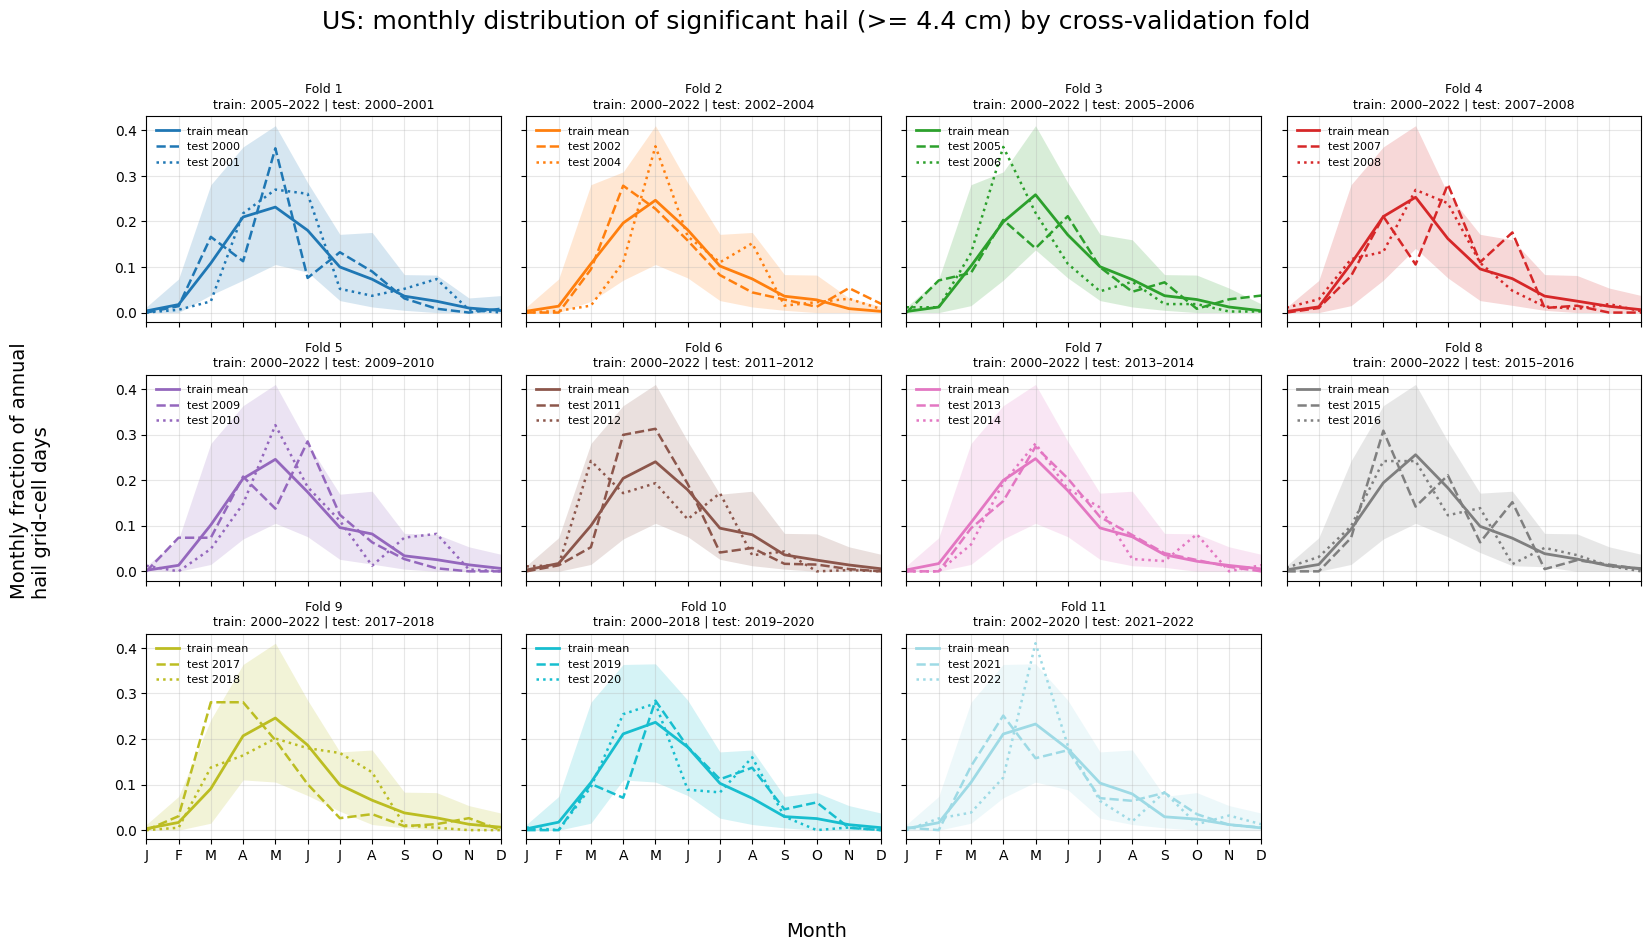

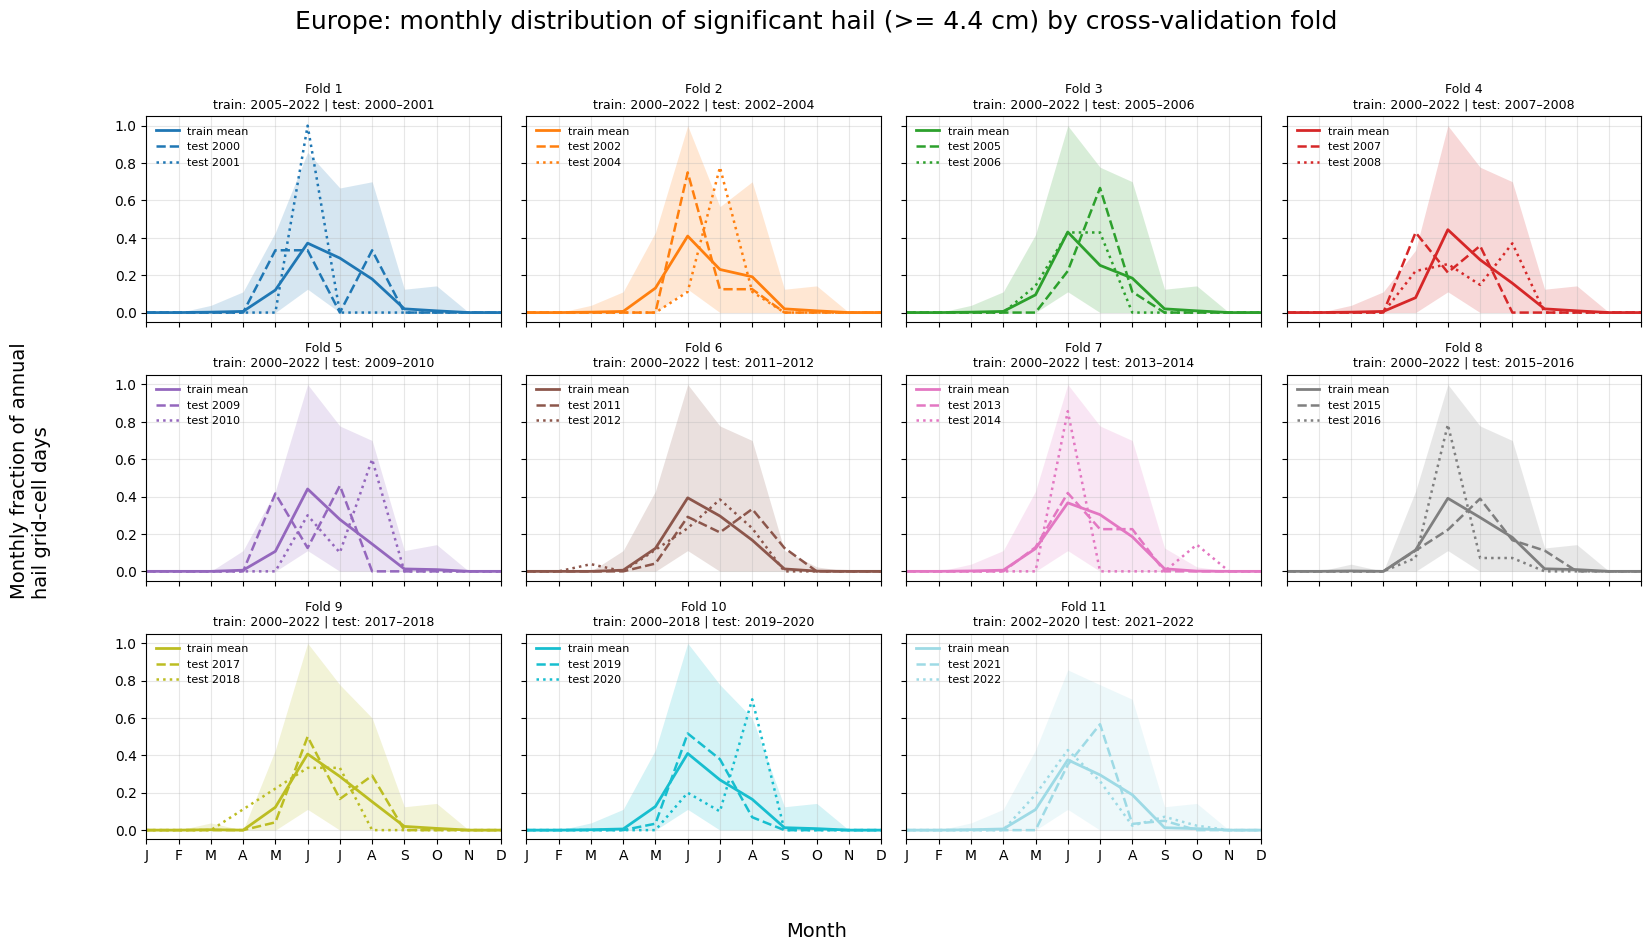

In [7]:
# ============================================================
# Plot monthly hail distribution with one subplot per fold
# - training years: colored band (IQR or min-max) + mean
# - test years: lines in the same color
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_sig_hail(obs, thr_cm):
    hb = obs[0].astype(np.float32)
    hs = obs[1].astype(np.float32)
    sig = (hb == 1) & np.isfinite(hs) & (hs >= thr_cm)
    return sig.astype(np.float32)


def plot_monthly_fold_distribution_subplots(
    rgd_time_dd,
    obs_daily,
    lsm,
    popmask,
    fold_train_years,
    fold_test_years,
    title,
    outpath=None,
    normalize=True,
    band_type="minmax",
    ncols=4,
):
    """
    Parameters
    ----------
    rgd_time_dd : pandas.DatetimeIndex
        Daily timestamps
    obs_daily : np.ndarray
        Daily hail occurrence array with shape (time, lat, lon)
    lsm : np.ndarray
        Land-sea mask on target grid, shape (lat, lon)
    popmask : np.ndarray
        Population mask on target grid, shape (lat, lon)
    fold_train_years : list of np.ndarray
        Training years for each fold
    fold_test_years : list of np.ndarray
        Test years for each fold
    title : str
        Figure title
    outpath : str or None
        File path to save plot
    normalize : bool
        If True, each year is normalized by its annual total
    band_type : str
        "iqr" or "minmax"
    ncols : int
        Number of subplot columns
    """

    # ---------------------------
    # 1) Build valid domain mask
    # ---------------------------
    valid_mask = (np.asarray(lsm) > 0.5) & (np.asarray(popmask).astype(bool))

    # ---------------------------
    # 2) Aggregate daily hail over domain
    #    -> daily number of hail-positive grid cells
    # ---------------------------
    daily_domain_counts = np.sum(obs_daily[:, valid_mask] > 0, axis=1)

    # ---------------------------
    # 3) Build dataframe
    # ---------------------------
    time_index = pd.DatetimeIndex(rgd_time_dd)

    df = pd.DataFrame({
        "time": time_index,
        "year": time_index.year,
        "month": time_index.month,
        "hail_gc_days": daily_domain_counts,
    })

    # monthly total hail grid-cell days per year
    monthly = (
        df.groupby(["year", "month"], as_index=False)["hail_gc_days"]
        .sum()
    )

    # ensure all months 1..12 exist for each year
    years_all = np.sort(monthly["year"].unique())
    full_index = pd.MultiIndex.from_product(
        [years_all, np.arange(1, 13)],
        names=["year", "month"]
    )

    monthly = (
        monthly.set_index(["year", "month"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    # optionally normalize each year by annual total
    if normalize:
        annual_sum = monthly.groupby("year")["hail_gc_days"].transform("sum")
        monthly["plot_value"] = np.where(
            annual_sum > 0,
            monthly["hail_gc_days"] / annual_sum,
            np.nan,
        )
        ylabel = "Monthly fraction of annual\nhail grid-cell days"
    else:
        monthly["plot_value"] = monthly["hail_gc_days"]
        ylabel = "Monthly hail\ngrid-cell days"

    # pivot: rows=year, cols=month
    monthly_pivot = monthly.pivot(index="year", columns="month", values="plot_value")
    monthly_pivot = monthly_pivot.reindex(columns=np.arange(1, 13), fill_value=np.nan)

    # ---------------------------
    # 4) Plot subplots
    # ---------------------------
    nfolds = len(fold_train_years)
    nrows = int(np.ceil(nfolds / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.2 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    cmap = plt.get_cmap("tab20", nfolds)
    months = np.arange(1, 13)
    month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

    for i, (train_years, test_years) in enumerate(zip(fold_train_years, fold_test_years)):
        ax = axes[i]
        color = cmap(i)

        train_years = [int(y) for y in train_years if int(y) in monthly_pivot.index]
        test_years = [int(y) for y in test_years if int(y) in monthly_pivot.index]

        train_data = monthly_pivot.loc[train_years]
        test_data = monthly_pivot.loc[test_years]

        if band_type == "iqr":
            lower = train_data.quantile(0.25, axis=0)
            upper = train_data.quantile(0.75, axis=0)
        elif band_type == "minmax":
            lower = train_data.min(axis=0)
            upper = train_data.max(axis=0)
        else:
            raise ValueError("band_type must be 'iqr' or 'minmax'")

        train_mean = train_data.mean(axis=0)

        # training band
        ax.fill_between(
            months,
            lower.values,
            upper.values,
            color=color,
            alpha=0.18,
            linewidth=0,
        )

        # training mean
        ax.plot(
            months,
            train_mean.values,
            color=color,
            linewidth=2.0,
            label="train mean",
        )

        # test years
        linestyles = ["--", ":"]
        for j, year in enumerate(test_years):
            ax.plot(
                months,
                test_data.loc[year].values,
                color=color,
                linewidth=1.8,
                linestyle=linestyles[j % 2],
                alpha=1.0,
                label=f"test {year}",
            )

        ax.set_title(
            f"Fold {i+1}\ntrain: {train_years[0]}–{train_years[-1]} | "
            f"test: {test_years[0]}–{test_years[-1]}",
            fontsize=9
        )
        ax.set_xticks(months)
        ax.set_xticklabels(month_labels)
        ax.set_xlim(1, 12)
        ax.grid(True, alpha=0.3)
        ax.legend(frameon=False, fontsize=8, loc="upper left")

    # hide unused panels
    for j in range(nfolds, len(axes)):
        axes[j].axis("off")

    # common labels
    fig.suptitle(title, fontsize=18, y=0.98)
    fig.supxlabel("Month", fontsize=14)
    fig.supylabel(ylabel, fontsize=14)

    plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])

    if outpath is not None:
        plt.savefig(outpath, dpi=200, bbox_inches="tight")

    plt.show()

hail_obs_us = build_sig_hail(rgrNOAAObs, 4.4)

plot_monthly_fold_distribution_subplots(
    rgd_time_dd=rgdTimeDD,
    obs_daily=hail_obs_us,
    lsm=LSM_US,
    popmask=popmask_us_back,
    fold_train_years=fold_train_years,
    fold_test_years=fold_test_years,
    title="US: monthly distribution of significant hail (>= 4.4 cm) by cross-validation fold",
    outpath="/cluster/home/agebhardt/plots/us_monthly_hail_fold_distribution_sig44_subplots.png",
    normalize=True,
    band_type="minmax",
    ncols=4,
)

hail_obs_eu = build_sig_hail(rgrESSLObs, 4.4)

plot_monthly_fold_distribution_subplots(
    rgd_time_dd=rgdTimeDD,
    obs_daily=hail_obs_eu,
    lsm=LSM_EU,
    popmask=popmask_eu_back,
    fold_train_years=fold_train_years,
    fold_test_years=fold_test_years,
    title="Europe: monthly distribution of significant hail (>= 4.4 cm) by cross-validation fold",
    outpath="/cluster/home/agebhardt/plots/eu_monthly_hail_fold_distribution_sig44_subplots.png",
    normalize=True,
    band_type="minmax",
    ncols=4,
)

# xgbGlobal / xgbUS Plots (Model vs. Obs)

## Annual cycle of hail frequency

### cv summary plot for cities

In [7]:
# ============================================================
# CITY PLOTS: OBSERVATIONAL MEAN + SELECTED-FOLD PREDICTIONS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# ============================================================
# 1) CONFIG
# ============================================================
base = Path("/cluster/home/agebhardt")

run_date_global = "xgbGlobal_sigHail/final_1"
run_date_global_dall = "xgbGlobal_sigHail/final_dall" #change to dall
run_date_usonly = "xgbUS_sigHail/final_1"
run_date_usonly_dall = "xgbUS_sigHail/final_dall" #change to dall

output_folder = "xgbGlobal_xgbUS_combined/city_plots"

paths = {
    "models_global": base / "models" / run_date_global_dall, #change to dall
    "models_usonly": base / "models" / run_date_usonly_dall, #change to dall
    "plots": base / "plots" / output_folder,
}
for p in paths.values():
    p.mkdir(parents=True, exist_ok=True)

cfg = {
    "run_global_model": True,
    "run_us_model": True,
    "fold_global": 0,
    "fold_us": 0,
    "thr_bin_global": 0.5,
    "thr_bin_us": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022), 
    "years_eu": (2008, 2022), 
    
    "figsize": (3.3, 2.8), #4.3, 3.3
    "month_step": 2,
    "lw_obs": 1,
    "lw_pred": 1,
    "fontsize_title": 8,
    "fontsize_label": 7,
    "fontsize_ticks": 6.5,
    "fontsize_legend": 6,

    
    "cities_us": {
        # "Oklahoma City": (-97.5164, 35.4676),
        # "Kansas City": (-94.5786, 39.0997),
        # "Dallas": (-96.80667, 32.78306),
        # "Rapid City": (-103.2310, 44.0805),
        # "Atlanta": (-84.3880, 33.7490),
        # "Albuquerque": (-106.6504, 35.0844),
        # "Omaha": (-95.9980, 41.2565),
        # "Lincoln": (-96.6852, 40.8136),
        # "Denver": (-104.9903, 39.7392),
        # "Colorado Springs": (-104.8214, 38.8339),
    },
    "cities_eu": {
        # "Graz": (15.4395, 47.0707),
        # "Munich": (11.5761, 48.1374),
        # "Berlin": (13.4105, 52.5244),
        # "Warsaw": (21.0122, 52.2297),
        # "Zurich": (8.55, 47.3667),
        "Milan": (9.1900, 45.4642),
        "Rome": (12.5113, 41.8919),
        # "Venice": (12.3155, 45.4408),
        # "Turin": (7.6869, 45.0703),
        "Paris": (2.3488, 48.8534),
        # "Toulouse": (1.4442, 43.6047),   
        "Girona": (2.8214, 41.9794),
        # "Barcelona": (2.1734, 41.3851),
    },
}

dates_full = pd.DatetimeIndex(rgdTimeDD)
month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
month_labels_full = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

col_obs_line = "black"
col_obs_band = "0.75"
col_global = "#d81b60"
col_us = "#219ebc"

regions = {
    "conus": {
        "label": "CONUS",
        "years": cfg["years_us"],
        "obs_raw": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "lon": rgrLonNOAA,
        "lat": rgrLatNOAA,
        "land_mask": LSM_US >= 0.5,
        "cities": cfg["cities_us"],
        "file_tag": "conus",
        
    },
    "europe": {
        "label": "Europe",
        "years": cfg["years_eu"],
        "obs_raw": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "lon": rgrLonESSL,
        "lat": rgrLatESSL,
        "land_mask": LSM_EU >= 0.5,
        "cities": cfg["cities_eu"],
        "file_tag": "europe",
    },
}

# ============================================================
# 2) HELPERS
# ============================================================
def load_booster(model_dir, fold, model_prefix):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"{model_prefix}_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster


def build_sig_hail(obs, thr_cm):
    hail_bin = obs[0].astype(np.float32)
    hail_size = obs[1].astype(np.float32)
    return ((hail_bin == 1) & np.isfinite(hail_size) & (hail_size >= thr_cm)).astype(np.float32)


def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out


def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out

def get_month_ticks(step=2, start_month=2):
    month_numbers = np.arange(start_month, 13, step)
    tick_pos = month_numbers - 1
    tick_lab = [month_labels_full[m - 1] for m in month_numbers]
    return tick_pos, tick_lab


def predict_prob_grid_stream(booster, x_4d, land2d, chunk_days=180):
    """
    x_4d: (T, F, H, W)
    returns: (T, H, W) with NaN outside land2d
    """
    t_size, n_feat, n_lat, n_lon = x_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = x_4d[t0:t1]
        tc = x_chunk.shape[0]

        x_chunk = np.moveaxis(x_chunk, 1, -1)             # (tc, H, W, F)
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)
        x_chunk = x_chunk[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob


def monthly_hail_gridcell_count(hail3d, dates, spatial_mask):
    """
    Returns (n_years, 12): hail-positive gridcell-days per month
    """
    years = np.unique(dates.year)
    out = []

    for year in years:
        sel_year = dates.year == year
        vals = np.zeros(12, dtype=np.float32)

        for month in range(1, 13):
            sel = sel_year & (dates.month == month)
            vals[month - 1] = np.nansum(hail3d[sel][:, spatial_mask])

        out.append(vals)

    return np.asarray(out)


def safe_monthly_summary(arr):
    mean_ = np.full(12, np.nan, dtype=np.float32)
    p05_ = np.full(12, np.nan, dtype=np.float32)
    p95_ = np.full(12, np.nan, dtype=np.float32)

    for m in range(12):
        col = arr[:, m]
        col = col[np.isfinite(col)]
        if col.size > 0:
            mean_[m] = np.mean(col)
            p05_[m] = np.percentile(col, 5)
            p95_[m] = np.percentile(col, 95)

    return mean_, p05_, p95_


def nearest_3x3_mask(lon2d, lat2d, lon0, lat0):
    dist2 = (lon2d - lon0) ** 2 + (lat2d - lat0) ** 2
    iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)

    y0 = max(0, iy - 1)
    y1 = min(lon2d.shape[0], iy + 2)
    x0 = max(0, ix - 1)
    x1 = min(lon2d.shape[1], ix + 2)

    mask = np.zeros(lon2d.shape, dtype=bool)
    mask[y0:y1, x0:x1] = True
    return mask


def subset_years(arr3d, year_range):
    start_year, end_year = year_range
    keep = (dates_full.year >= start_year) & (dates_full.year <= end_year)
    return arr3d[keep], dates_full[keep]


def get_city_series(obs3d, x4d, land_mask, city_mask, year_range, booster, thr_bin):
    """
    Returns monthly yearly values for one city and one model over the selected years.
    """
    obs_sel, dates_sel = subset_years(obs3d, year_range)
    x_sel, _ = subset_years(x4d.astype(np.float32), year_range)

    prob = predict_prob_grid_stream(
        booster=booster,
        x_4d=x_sel,
        land2d=land_mask,
        chunk_days=cfg["chunk_days"],
    )
    pred_sel = binarize(prob, thr_bin)

    spatial_mask = city_mask & land_mask

    obs_yearly = monthly_hail_gridcell_count(obs_sel, dates_sel, spatial_mask)
    pred_yearly = monthly_hail_gridcell_count(pred_sel, dates_sel, spatial_mask)

    return obs_yearly, pred_yearly


def plot_city_panel(
    obs_yearly,
    city,
    region_label,
    outpath,
    pred_global_yearly=None,
    pred_us_yearly=None,
):
    months = np.arange(12)
    tick_pos, tick_lab = get_month_ticks(step=cfg["month_step"], start_month=2)

    mean_obs, p05_obs, p95_obs = safe_monthly_summary(obs_yearly)

    fig, ax = plt.subplots(figsize=cfg["figsize"])

    # observational spread
    ax.fill_between(
        months, p05_obs, p95_obs,
        color=col_obs_band, alpha=0.4
    )

    line_obs, = ax.plot(
        months, mean_obs,
        color=col_obs_line, lw=cfg["lw_obs"],
        label="Observed mean"
    )

    handles = [line_obs]
    labels = ["Observed mean"]

    if pred_global_yearly is not None:
        mean_global, _, _ = safe_monthly_summary(pred_global_yearly)
        line_global, = ax.plot(
            months, mean_global,
            color=col_global, lw=cfg["lw_pred"],
            label=f"xgbGlobal"
        )
        handles.append(line_global)
        labels.append(f"xgbGlobal (fold {cfg['fold_global']})")

    if pred_us_yearly is not None:
        mean_us, _, _ = safe_monthly_summary(pred_us_yearly)
        line_us, = ax.plot(
            months, mean_us,
            color=col_us, lw=cfg["lw_pred"],
            label=f"xgbUS"
        )
        handles.append(line_us)
        labels.append(f"xgbUS (fold {cfg['fold_us']})")

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lab, fontsize=cfg["fontsize_ticks"])
    ax.tick_params(axis="y", labelsize=cfg["fontsize_ticks"])
    ax.set_xlabel("Month", fontsize=cfg["fontsize_label"])
    ax.set_ylabel("Hail events per month", fontsize=cfg["fontsize_label"])
    ax.set_xlim(0, 11)
    ax.set_title(f"{city}", fontsize=cfg["fontsize_title"])
    ax.grid(True, alpha=0.3)

    ax.legend(
        handles=handles,
        labels=labels,
        frameon=True,
        framealpha=0.85,
        fontsize=cfg["fontsize_legend"],
        loc="upper right",
    )

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)

# ============================================================
# 3) PREPARE OBSERVATIONS
# ============================================================
for region in regions.values():
    region["obs"] = apply_nan_mask(
        build_sig_hail(region["obs_raw"], cfg["threshold_cm"]),
        region["land_mask"]
    )

# ============================================================
# 4) RUN
# ============================================================
# for region_key, region in regions.items():
#     print(f"\n=== {region['label']} ===")

#     booster_global = None
#     if cfg["run_global_model"]:
#         booster_global = load_booster(
#             paths["models_global"], cfg["fold_global"], "xgbGlobal_sigHail"
#         )
    
#     booster_us = None
#     if cfg["run_us_model"]:
#         booster_us = load_booster(
#             paths["models_usonly"], cfg["fold_us"], "xgbUS_sigHail"
#         )
#     for city, (clon, clat) in region["cities"].items():
#         print(f"{region['label']} | {city}")

#         city_mask = nearest_3x3_mask(region["lon"], region["lat"], clon, clat)

#         pred_global_yearly = None
#         pred_us_yearly = None
#         obs_yearly = None
        
#         if cfg["run_global_model"]:
#             obs_yearly, pred_global_yearly = get_city_series(
#                 obs3d=region["obs"],
#                 x4d=region["x4d"],
#                 land_mask=region["land_mask"],
#                 city_mask=city_mask,
#                 year_range=region["years"],
#                 booster=booster_global,
#                 thr_bin=cfg["thr_bin_global"],
#             )
        
#         if cfg["run_us_model"]:
#             obs_yearly_us, pred_us_yearly = get_city_series(
#                 obs3d=region["obs"],
#                 x4d=region["x4d"],
#                 land_mask=region["land_mask"],
#                 city_mask=city_mask,
#                 year_range=region["years"],
#                 booster=booster_us,
#                 thr_bin=cfg["thr_bin_us"],
#             )
        
#             if obs_yearly is None:
#                 obs_yearly = obs_yearly_us
#             elif not np.allclose(obs_yearly, obs_yearly_us, equal_nan=True):
#                 print(f"WARNING: observation mismatch for {city} ({region['label']})")

#         outpath = paths["plots"] / f"city_gridcelldays_{city.replace(' ', '')}_{region['file_tag']}.png"

#         plot_city_panel(
#             obs_yearly=obs_yearly,
#             pred_global_yearly=pred_global_yearly,
#             pred_us_yearly=pred_us_yearly,
#             city=city,
#             region_label=region["label"],
#             outpath=outpath,
#         )

# print("Done.")
# print(f"Plots saved in: {paths['plots']}")

# ============================================================
# 4) RUN FINAL MODEL dall
# ============================================================
for region_key, region in regions.items():
    print(f"\n=== {region['label']} ===")

    booster_global = None
    if cfg["run_global_model"]:
        booster_global = load_booster(
            paths["models_global"], cfg["fold_global"], "xgbGlobal_sigHail_FINAL_2000-2022"
        )
    
    booster_us = None
    if cfg["run_us_model"]:
        booster_us = load_booster(
            paths["models_usonly"], cfg["fold_us"], "xgbUS_sigHail_FINAL_2000-2022"
        )
    
    for city, (clon, clat) in region["cities"].items():
        print(f"{region['label']} | {city}")

        city_mask = nearest_3x3_mask(region["lon"], region["lat"], clon, clat)

        pred_global_yearly = None
        pred_us_yearly = None
        obs_yearly = None
        
        if cfg["run_global_model"]:
            obs_yearly, pred_global_yearly = get_city_series(
                obs3d=region["obs"],
                x4d=region["x4d"],
                land_mask=region["land_mask"],
                city_mask=city_mask,
                year_range=region["years"],
                booster=booster_global,
                thr_bin=cfg["thr_bin_global"],
            )
        
        if cfg["run_us_model"]:
            obs_yearly_us, pred_us_yearly = get_city_series(
                obs3d=region["obs"],
                x4d=region["x4d"],
                land_mask=region["land_mask"],
                city_mask=city_mask,
                year_range=region["years"],
                booster=booster_us,
                thr_bin=cfg["thr_bin_us"],
            )
        
            if obs_yearly is None:
                obs_yearly = obs_yearly_us
            elif not np.allclose(obs_yearly, obs_yearly_us, equal_nan=True):
                print(f"WARNING: observation mismatch for {city} ({region['label']})")

        outpath = paths["plots"] / f"city_gridcelldays_{city.replace(' ', '')}_{region['file_tag']}.png"

        plot_city_panel(
            obs_yearly=obs_yearly,
            pred_global_yearly=pred_global_yearly,
            pred_us_yearly=pred_us_yearly,
            city=city,
            region_label=region["label"],
            outpath=outpath,
        )

print("Done.")
print(f"Plots saved in: {paths['plots']}")


=== CONUS ===

=== Europe ===
Europe | Milan
Europe | Rome
Europe | Paris
Europe | Girona
Done.
Plots saved in: /cluster/home/agebhardt/plots/xgbGlobal_xgbUS_combined/city_plots


### cv summary plots for CONUS OR Europe

In [18]:
# ============================================================
# CROSS-VALIDATED SEASONAL SUMMARY PLOTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xgboost as xgb
from matplotlib.patches import Patch

# ============================================================
# 1) CONFIG
# ============================================================
run_date = "xgbGlobal_sigHail/final_1"
base = Path("/cluster/home/agebhardt")

paths = {
    "models": base / "models" / run_date,
    "plots":  base / "plots" / run_date,
}
for p in paths.values():
    p.mkdir(parents=True, exist_ok=True)

cfg = {
    "thr_bin": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022),
    "years_eu": (2000, 2022),
    "show_yearly_lines": False,
    "show_outlier_year": False,
    
    "figsize_fold": (3.9, 3.9),
    "figsize_cv": (7.8, 4.4),
    "month_step": 2,
}

dates_full = pd.DatetimeIndex(rgdTimeDD)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
month_labels_full = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

regions = {
    "conus": {
        "label": "CONUS",
        "years": cfg["years_us"],
        "obs_raw": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "land_mask": LSM_US >= 0.5,
        "eval_mask": popmask_us_back,
        "model_prefix": "xgbGlobal_sigHail",
        "file_tag": "conus",
    },
    "europe": {
        "label": "Europe",
        "years": cfg["years_eu"],
        "obs_raw": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "land_mask": LSM_EU >= 0.5,
        "eval_mask": popmask_eu_back,
        "model_prefix": "xgbGlobal_sigHail",
        "file_tag": "europe",
    },
}

metric_specs = {
    # "freq": {
    #     "name": "monthly hail-day frequency",
    #     "title_fold": "{region} | Fold {fold:02d} | Monthly hail-day frequency",
    #     "title_cv": "{region} | Cross-validated Monthly Hail-Day Frequency (all held-out test years)",
    #     "ylabel": "Hail days per month",
    #     "dual_axis": False,
    # },
    "grid": {
        "name": "monthly hail gridcell-days in evaluation cells",
        "title_fold": "{region} | Fold {fold:02d} | Monthly hail grid cell days in evaluation cells",
        "title_cv": "{region} | Cross-validated Monthly Hail Gridcell-Days in Evaluation Cells (all held-out test years)",
        "ylabel": "Hail-positive gridcells per month",
        "dual_axis": False,
    },
    # "fp": {
    #     "name": "hail footprint per hail-day in evaluation cells",
    #     "title_fold": "{region} | Fold {fold:02d} | Hail footprint per hail day in evaluation cells",
    #     "title_cv": "{region} | Cross-validated Hail Footprint per Hail-Day (all held-out test years)",
    #     "ylabel": "Mean hail gridcells per hail-day (observations)",
    #     "dual_axis": True,
    # },
    # "gridfrac": {
    #     "name": "normalized monthly hail gridcell-day fraction",
    #     "title_fold": "{region} | Fold {fold:02d} | Normalized monthly hail grid cell day fraction",
    #     "title_cv": "{region} | Cross-validated Normalized Monthly Hail Gridcell-Day Fraction (all held-out test years)",
    #     "ylabel": "Fraction of annual hail gridcell-days per month",
    #     "dual_axis": False,
    # },
}

# ============================================================
# 2) HELPERS
# ============================================================
def get_month_ticks(step=2, start_month=2):
    month_numbers = np.arange(start_month, 13, step)
    return month_numbers - 1, [month_labels_full[m - 1] for m in month_numbers]


def load_booster(model_dir, fold, model_prefix="xgbGlobal_sigHail"):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"{model_prefix}_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster


def build_sig_hail(obs, thr_cm):
    hb = obs[0].astype(np.float32)
    hs = obs[1].astype(np.float32)
    return ((hb == 1) & np.isfinite(hs) & (hs >= thr_cm)).astype(np.float32)


def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out


def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out


def safe_monthly_summary(arr):
    mean_ = np.full(12, np.nan, dtype=np.float32)
    p05_ = np.full(12, np.nan, dtype=np.float32)
    p95_ = np.full(12, np.nan, dtype=np.float32)

    for m in range(12):
        col = arr[:, m]
        col = col[np.isfinite(col)]
        if col.size:
            mean_[m] = np.mean(col)
            p05_[m] = np.percentile(col, 5)
            p95_[m] = np.percentile(col, 95)

    return mean_, p05_, p95_


def find_outlier_year(pred_lines):
    best_year, best_line, best_month_idx, best_val = None, None, None, -np.inf

    for year, line in pred_lines:
        line = np.asarray(line)
        if np.any(np.isfinite(line)):
            month_idx = int(np.nanargmax(line))
            val = float(line[month_idx])
            if val > best_val:
                best_year, best_line, best_month_idx, best_val = year, line, month_idx, val

    return best_year, best_line, best_month_idx, best_val


def predict_prob_grid_stream(booster, X_4d, land2d, chunk_days=180):
    t_size, n_feat, n_lat, n_lon = X_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = np.moveaxis(X_4d[t0:t1], 1, -1)              # (T,H,W,F)
        tc = x_chunk.shape[0]
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob


def monthly_metric(hail3d, dates, spatial_mask, mode):
    years = np.unique(dates.year)
    out = []

    if mode == "freq":
        daily_hail = np.nansum(hail3d[:, spatial_mask], axis=1) > 0

    elif mode == "fp":
        daily_cells = np.nansum(hail3d[:, spatial_mask], axis=1)
        hail_day = daily_cells > 0

    for year in years:
        sel_year = dates.year == year
        vals = np.full(12, np.nan if mode == "fp" else 0.0, dtype=np.float32)

        for month in range(1, 13):
            sel = sel_year & (dates.month == month)

            if mode == "freq":
                vals[month - 1] = np.sum(daily_hail[sel])

            elif mode in ("grid", "gridfrac"):
                vals[month - 1] = np.nansum(hail3d[sel][:, spatial_mask])

            elif mode == "fp":
                sel_hail = sel & hail_day
                if np.any(sel_hail):
                    vals[month - 1] = np.nanmean(daily_cells[sel_hail])

        if mode == "gridfrac":
            annual_total = np.nansum(vals)
            vals[:] = vals / annual_total if annual_total > 0 else np.nan

        out.append(vals)

    return np.asarray(out)


def compute_metrics(hail3d, dates, mask):
    return {
        "freq": monthly_metric(hail3d, dates, mask, "freq"),
        "grid": monthly_metric(hail3d, dates, mask, "grid"),
        "fp": monthly_metric(hail3d, dates, mask, "fp"),
        "gridfrac": monthly_metric(hail3d, dates, mask, "gridfrac"),
    }


def collect_obs_all_years_metrics(obs3d, dates, eval_mask, year_range):
    start_year, end_year = year_range
    keep = (dates.year >= start_year) & (dates.year <= end_year)
    return compute_metrics(obs3d[keep], dates[keep], eval_mask)


def collect_fold_metrics_per_fold(region_name, obs3d, x4d, land_mask, eval_mask, year_range, model_prefix):
    start_year, end_year = year_range
    results = []

    for fold in range(len(fold_test)):
        print(f"[{region_name}] fold {fold}")
        booster = load_booster(paths["models"], fold, model_prefix=model_prefix)

        idx_fold = fold_test[fold]
        dates_fold = dates_full[idx_fold]
        keep = (dates_fold.year >= start_year) & (dates_fold.year <= end_year)
        if not np.any(keep):
            continue

        idx_fold = idx_fold[keep]
        dates_fold = dates_full[idx_fold]

        y_obs = obs3d[idx_fold]
        prob = predict_prob_grid_stream(
            booster=booster,
            X_4d=x4d[idx_fold].astype(np.float32),
            land2d=land_mask,
            chunk_days=cfg["chunk_days"],
        )
        y_pred = binarize(prob, cfg["thr_bin"])

        results.append({
            "fold": fold,
            "years": np.unique(dates_fold.year),
            "obs": compute_metrics(y_obs, dates_fold, eval_mask),
            "pred": compute_metrics(y_pred, dates_fold, eval_mask),
        })

    return results


def collect_fold_yearly_metrics(region_name, obs3d, x4d, land_mask, eval_mask, year_range, model_prefix):
    start_year, end_year = year_range
    obs_all = {k: [] for k in metric_specs}
    pred_all = {k: [] for k in metric_specs}
    pred_lines = {k: [] for k in metric_specs}

    for fold in range(len(fold_test)):
        print(f"[{region_name}] fold {fold}")
        booster = load_booster(paths["models"], fold, model_prefix=model_prefix)

        idx_fold = fold_test[fold]
        dates_fold = dates_full[idx_fold]
        keep = (dates_fold.year >= start_year) & (dates_fold.year <= end_year)
        if not np.any(keep):
            continue

        idx_fold = idx_fold[keep]
        dates_fold = dates_full[idx_fold]

        y_obs = obs3d[idx_fold]
        prob = predict_prob_grid_stream(
            booster=booster,
            X_4d=x4d[idx_fold].astype(np.float32),
            land2d=land_mask,
            chunk_days=cfg["chunk_days"],
        )
        y_pred = binarize(prob, cfg["thr_bin"])

        obs_metrics = compute_metrics(y_obs, dates_fold, eval_mask)
        pred_metrics = compute_metrics(y_pred, dates_fold, eval_mask)

        for key in metric_specs:
            obs_all[key].append(obs_metrics[key])
            pred_all[key].append(pred_metrics[key])

        years_fold = np.unique(dates_fold.year)
        for i, year in enumerate(years_fold):
            for key in metric_specs:
                pred_lines[key].append((int(year), pred_metrics[key][i]))

    return {
        "obs": {k: np.vstack(v) for k, v in obs_all.items()},
        "pred": {k: np.vstack(v) for k, v in pred_all.items()},
        "pred_lines": pred_lines,
    }


# ============================================================
# 3) PLOTTING
# ============================================================
def plot_fold_comparison(obs_all_years, obs_test_fold, pred_test_fold, title, ylabel, outpath,
                         figsize=(3.9, 3.9), month_step=2, dual_axis=False):
    months = np.arange(12)
    tick_pos, tick_lab = get_month_ticks(step=month_step, start_month=2)
    _, p05_all, p95_all = safe_monthly_summary(obs_all_years)
    mean_obs_fold = np.nanmean(obs_test_fold, axis=0)
    mean_pred_fold = np.nanmean(pred_test_fold, axis=0)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.fill_between(months, p05_all, p95_all, color="0.75", alpha=0.35)

    if dual_axis:
        ax2 = ax1.twinx()
        obs_line, = ax1.plot(months, mean_obs_fold, color="black", lw=1)
        pred_line, = ax2.plot(months, mean_pred_fold, color="#d81b60", lw=1)

        ax1.set_ylabel(ylabel, fontsize=8, color="black")
        ax2.set_ylabel("Predicted mean", fontsize=8, color="black")
        ax1.tick_params(axis="y", labelsize=7, labelcolor="black")
        ax2.tick_params(axis="y", labelsize=7, labelcolor="black")
    else:
        obs_line, = ax1.plot(months, mean_obs_fold, color="black", lw=1)
        pred_line, = ax1.plot(months, mean_pred_fold, color="#d81b60", lw=1)
        ax1.set_ylabel(ylabel, fontsize=8, color="black")
        ax1.tick_params(axis="y", labelsize=7, labelcolor="black")

    handles = [Patch(facecolor="0.75", alpha=0.35), obs_line, pred_line]
    labels = ["Obs. 5–95% (all years)", "Observed mean (test years)", "Predicted mean (test years)"]
    ax1.legend(handles, labels, frameon=False, loc="upper right", fontsize=7)

    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(tick_lab, fontsize=7)
    ax1.set_xlabel("Month", fontsize=8)
    ax1.set_xlim(0, 11)
    ax1.set_title(title, fontsize=8)
    ax1.tick_params(axis="x", labelsize=7)
    ax1.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_cv_summary(obs_yearly, pred_yearly, pred_lines, title, ylabel, outpath,
                    dual_axis=False, show_yearly_lines=True, show_outlier_year=True, figsize=(7.8, 4.4)):
    months = np.arange(12)
    mean_obs, p05_obs, p95_obs = safe_monthly_summary(obs_yearly)
    mean_pred, p05_pred, p95_pred = safe_monthly_summary(pred_yearly)
    
    if show_outlier_year:
        best_year, best_line, best_month_idx, best_val = find_outlier_year(pred_lines)
    else:
        best_year, best_line, best_month_idx, best_val = None, None, None, None

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.fill_between(months, p05_obs, p95_obs, color="0.75", alpha=0.4, label="Obs. 5–95%")
    ax1.plot(months, mean_obs, color="black", lw=1.8, label="Obs. mean")

    def plot_yearly(ax, main=False):
        for year, yearly_line in pred_lines:
            is_outlier = (
                best_year is not None and year == best_year and np.allclose(yearly_line, best_line, equal_nan=True)
            )
            ax.plot(
                months, yearly_line,
                color="#d81b60" if is_outlier else "#ffafcc",
                lw=0.6,
                alpha=0.95 if is_outlier else 0.25,
                zorder=6 if is_outlier else 2,
            )

    if dual_axis:
        ax2 = ax1.twinx()
        if show_yearly_lines:
            plot_yearly(ax2)

        ax2.fill_between(months, p05_pred, p95_pred, color="#ffafcc", alpha=0.35)
        pred_mean_line, = ax2.plot(months, mean_pred, color="#d81b60", lw=1)

        if best_line is not None:
            ax2.scatter(best_month_idx, best_val, color="#d81b60", s=30, zorder=7)
            ax2.annotate(
                f"Outlier year: {best_year}",
                xy=(best_month_idx, best_val),
                xytext=(best_month_idx + 0.35, best_val),
                textcoords="data",
                ha="left", va="bottom", fontsize=9, color="#d81b60",
                arrowprops=dict(arrowstyle="-", color="#d81b60", lw=0.8),
            )

        ax1.set_ylabel(ylabel, color="black")
        ax2.set_ylabel("Mean hail grid cells per hail-day (predictions)", color="#d81b60")
        ax1.tick_params(axis="y", labelcolor="black")
        ax2.tick_params(axis="y", labelcolor="#d81b60")

        ax1.legend(
            [ax1.lines[0], Patch(facecolor="0.75", alpha=0.4), pred_mean_line, Patch(facecolor="#ffafcc", alpha=0.35)],
            ["Obs. mean", "Obs. 5-95%", "Pred. mean", "Pred. 5-95%"],
            frameon=False, loc="upper left"
        )
    else:
        if show_yearly_lines:
            plot_yearly(ax1)

        ax1.fill_between(months, p05_pred, p95_pred, color="#d81b60", alpha=0.35, label="Pred. 5–95%")
        ax1.plot(months, mean_pred, color="#d81b60", lw=1.8, label="Pred. mean")

        if best_line is not None:
            ax1.scatter(best_month_idx, best_val, color="#d81b60", s=30, zorder=7)
            ax1.annotate(
                f"Outlier year: {best_year}",
                xy=(best_month_idx, best_val),
                xytext=(best_month_idx + 0.35, best_val),
                textcoords="data",
                ha="left", va="bottom", fontsize=9, color="#d81b60",
                arrowprops=dict(arrowstyle="-", color="#d81b60", lw=0.8),
            )

        ax1.set_ylabel(ylabel, color="black")
        ax1.tick_params(axis="y", labelcolor="black")
        ax1.legend(frameon=False, loc="upper left")

    ax1.set_xticks(months)
    ax1.set_xticklabels(month_labels)
    ax1.set_xlabel("Month")
    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# 4) DATA PREPARATION
# ============================================================
for region in regions.values():
    region["obs"] = apply_nan_mask(
        build_sig_hail(region["obs_raw"], cfg["threshold_cm"]),
        region["land_mask"]
    )


# ============================================================
# 5) RUN ANALYSIS
# ============================================================
for region_key, region in regions.items():
    label = region["label"]
    file_tag = region["file_tag"]

    print(f"\n=== {label}: fold comparison ===")
    obs_all_years = collect_obs_all_years_metrics(
        region["obs"], dates_full, region["eval_mask"], region["years"]
    )

    fold_results = collect_fold_metrics_per_fold(
        region_name=label,
        obs3d=region["obs"],
        x4d=region["x4d"],
        land_mask=region["land_mask"],
        eval_mask=region["eval_mask"],
        year_range=region["years"],
        model_prefix=region["model_prefix"],
    )

    for res in fold_results:
        fold = res["fold"]
        for key, spec in metric_specs.items():
            plot_fold_comparison(
                obs_all_years=obs_all_years[key],
                obs_test_fold=res["obs"][key],
                pred_test_fold=res["pred"][key],
                title=spec["title_fold"].format(region=label, fold=fold),
                ylabel=spec["ylabel"],
                outpath=paths["plots"] / f"fold{fold:02d}_{key}_{file_tag}.png",
                dual_axis=False,
                figsize=cfg["figsize_fold"],
                month_step=cfg["month_step"],
            )

    print(f"\n=== {label}: cross-validated summary ===")
    cv = collect_fold_yearly_metrics(
        region_name=label,
        obs3d=region["obs"],
        x4d=region["x4d"],
        land_mask=region["land_mask"],
        eval_mask=region["eval_mask"],
        year_range=region["years"],
        model_prefix=region["model_prefix"],
    )

    for key, spec in metric_specs.items():
        plot_cv_summary(
            obs_yearly=cv["obs"][key],
            pred_yearly=cv["pred"][key],
            pred_lines=cv["pred_lines"][key],
            title=spec["title_cv"].format(region=label),
            ylabel=spec["ylabel"],
            outpath=paths["plots"] / f"cv_summary_{key}_{file_tag}.png",
            dual_axis=spec["dual_axis"],
            show_yearly_lines=cfg["show_yearly_lines"],
            show_outlier_year=cfg["show_outlier_year"],
            figsize=cfg["figsize_cv"],
        )

print("Done.")
print(f"Plots saved in: {paths['plots']}")


=== CONUS: fold comparison ===
[CONUS] fold 0
[CONUS] fold 1
[CONUS] fold 2
[CONUS] fold 3
[CONUS] fold 4
[CONUS] fold 5
[CONUS] fold 6
[CONUS] fold 7
[CONUS] fold 8
[CONUS] fold 9
[CONUS] fold 10

=== CONUS: cross-validated summary ===
[CONUS] fold 0
[CONUS] fold 1
[CONUS] fold 2
[CONUS] fold 3
[CONUS] fold 4
[CONUS] fold 5
[CONUS] fold 6
[CONUS] fold 7
[CONUS] fold 8
[CONUS] fold 9
[CONUS] fold 10

=== Europe: fold comparison ===
[Europe] fold 0
[Europe] fold 1
[Europe] fold 2
[Europe] fold 3
[Europe] fold 4
[Europe] fold 5
[Europe] fold 6
[Europe] fold 7
[Europe] fold 8
[Europe] fold 9
[Europe] fold 10

=== Europe: cross-validated summary ===
[Europe] fold 0
[Europe] fold 1
[Europe] fold 2
[Europe] fold 3
[Europe] fold 4
[Europe] fold 5
[Europe] fold 6
[Europe] fold 7
[Europe] fold 8
[Europe] fold 9
[Europe] fold 10
Done.
Plots saved in: /cluster/home/agebhardt/plots/xgbGlobal_sigHail/final_1


### cv summary plots for CONUS AND Europe combined

In [7]:
# ============================================================
# CROSS-VALIDATED SEASONAL SUMMARY PLOTS
# xgbGlobal vs xgbUS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xgboost as xgb
from matplotlib.patches import Patch

# ============================================================
# 1) CONFIG
# ============================================================
base = Path("/cluster/home/agebhardt")

run_date_global = "xgbGlobal_sigHail/final_1"
run_date_usonly = "xgbUS_sigHail/final_1"
combined_output_folder = "xgbGlobal_xgbUS_combined"

paths = {
    "models_global": base / "models" / run_date_global,
    "models_usonly": base / "models" / run_date_usonly,
    "plots": base / "plots" / combined_output_folder / "cv_summary_overlay_global_vs_us",
}
for p in paths.values():
    p.mkdir(parents=True, exist_ok=True)

cfg = {
    "thr_bin_global": 0.5,
    "thr_bin_us": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022),
    "years_eu": (2000, 2022),
    "show_yearly_lines": False,
    "show_interval": True,
    "show_model_mean": True,
    "show_highlight_fold": False,
    "comparison_fold": 5,
    "make_fold_comparison_plot": False,
    "figsize": (3.9, 3.9),
    "month_step": 2,
    "highlight_fold_global": 2,
    "highlight_fold_us": 2,
    "legend_fontsize": 6.3,
    "label_fontsize": 7.5,
    "tick_fontsize": 6.8,
    "title_fontsize": 7.5,
}

dates_full = pd.DatetimeIndex(rgdTimeDD)
month_labels_full = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
summer_months = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]

colors = {
    "obs_line": "black",
    "obs_band": "0.75",
    "global_line": "#d81b60",
    "global_band": "#ffafcc",
    "us_line": "#219ebc",
    "us_band": "#8ecae6",
}

regions = {
    "conus": {
        "label": "CONUS",
        "years": cfg["years_us"],
        "obs_raw": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "land_mask": LSM_US >= 0.5,
        "eval_mask": popmask_us_back,
        "file_tag": "conus",
    },
    "europe": {
        "label": "Europe",
        "years": cfg["years_eu"],
        "obs_raw": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "land_mask": LSM_EU >= 0.5,
        "eval_mask": popmask_eu_back,
        "file_tag": "europe",
    },
}

metric_specs = {
    # "freq": {
    #     "title": "Seasonal cycle of significant hail days\n{region}, {years} | xgbGlobal vs xgbUS",
    #     "ylabel": "Mean hail days per month",
    #     "dual_axis": False,
    #     "obs_mask_key": "eval_mask",
    #     "pred_mask_key": "eval_mask"},
    
    "grid": {
        "title": "Seasonal cycle of hail-positive evaluation grid cells\n{region}, {years} | xgbGlobal vs xgbUS",
        "ylabel": "Mean hail-positive grid cells per month",
        "dual_axis": False,
        "obs_mask_key": "eval_mask",
        "pred_mask_key": "eval_mask"},
    
#     "gridcellrate": {
#         "title": "Seasonal cycle of significant hail events per evaluation grid cell\n{region}, {years} | xgbGlobal vs xgbUS",
#         "ylabel": "Mean hail events per month per evaluation grid cell",
#         "dual_axis": False,
#         "obs_mask_key": "eval_mask",
#         "pred_mask_key": "eval_mask"},
    
#     "fp": {
#         "title": "Seasonal cycle of hail footprint per hail day\n{region}, {years} | xgbGlobal vs xgbUS",
#         "ylabel": "Mean hail-positive grid cells per hail day",
#         "dual_axis": True,
#         "obs_mask_key": "eval_mask",
#         "pred_mask_key": "eval_mask"},
    
#     "gridfrac": {
#         "title": "Normalized seasonal cycle of hail-positive grid-cell-day fraction\n{region}, {years} | xgbGlobal vs xgbUS",
#         "ylabel": "Fraction of annual hail-positive grid-cell days",
#         "dual_axis": False,
#         "obs_mask_key": "eval_mask",
#         "pred_mask_key": "eval_mask"},
}

# ============================================================
# 2) HELPERS
# ============================================================
def get_month_ticks(step=2, start_month=2):
    month_numbers = np.arange(start_month, 13, step)
    return month_numbers - 1, [month_labels_full[m - 1] for m in month_numbers]

# def get_month_ticks():
#     month_numbers = np.array([4, 5, 6, 7, 8, 9])
#     return month_numbers - 1, [month_labels_full[m - 1] for m in month_numbers]

def load_booster(model_dir, fold, model_prefix):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"{model_prefix}_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster


def build_sig_hail(obs, thr_cm):
    hb = obs[0].astype(np.float32)
    hs = obs[1].astype(np.float32)
    return ((hb == 1) & np.isfinite(hs) & (hs >= thr_cm)).astype(np.float32)


def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out


def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out


def safe_monthly_summary(arr):
    mean_ = np.full(12, np.nan, dtype=np.float32)
    p05_ = np.full(12, np.nan, dtype=np.float32)
    p95_ = np.full(12, np.nan, dtype=np.float32)

    for m in range(12):
        col = arr[:, m]
        col = col[np.isfinite(col)]
        if col.size:
            mean_[m] = np.mean(col)
            p05_[m] = np.percentile(col, 5)
            p95_[m] = np.percentile(col, 95)

    return mean_, p05_, p95_


def predict_prob_grid_stream(booster, X_4d, land2d, chunk_days=180):
    t_size, n_feat, n_lat, n_lon = X_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())
    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = np.moveaxis(X_4d[t0:t1], 1, -1)  # (T,H,W,F)
        tc = x_chunk.shape[0]
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob


def monthly_metric(hail3d, dates, mask, mode):
    years = np.unique(dates.year)
    out = []

    n_cells = int(np.sum(mask))

    if mode == "freq":
        daily_hail = np.nansum(hail3d[:, mask], axis=1) > 0
    elif mode == "fp":
        daily_cells = np.nansum(hail3d[:, mask], axis=1)
        hail_day = daily_cells > 0

    for year in years:
        sel_year = dates.year == year
        vals = np.full(12, np.nan if mode == "fp" else 0.0, dtype=np.float32)

        for month in range(1, 13):
            sel = sel_year & (dates.month == month)

            if mode == "freq":
                vals[month - 1] = np.sum(daily_hail[sel])

            elif mode in ("grid", "gridfrac"):
                vals[month - 1] = np.nansum(hail3d[sel][:, mask])

            elif mode == "gridcellrate":
                if n_cells > 0:
                    vals[month - 1] = np.nansum(hail3d[sel][:, mask]) / n_cells
                else:
                    vals[month - 1] = np.nan

            elif mode == "fp":
                sel_hail = sel & hail_day
                if np.any(sel_hail):
                    vals[month - 1] = np.nanmean(daily_cells[sel_hail])

        if mode == "gridfrac":
            annual_total = np.nansum(vals)
            vals[:] = vals / annual_total if annual_total > 0 else np.nan

        out.append(vals)

    return np.asarray(out)


def compute_metrics(hail3d, dates, region):
    return {
        key: monthly_metric(
            hail3d,
            dates,
            region[spec["pred_mask_key"]],
            key
        )
        for key, spec in metric_specs.items()
    }


def collect_model_metrics(region, model_dir, model_prefix, thr_bin, highlight_fold=None):
    start_year, end_year = region["years"]

    obs_all = {k: [] for k in metric_specs}
    pred_all = {k: [] for k in metric_specs}
    pred_lines = {k: [] for k in metric_specs}
    highlight = {k: [] for k in metric_specs}

    for fold in range(len(fold_test)):
        print(f"[{region['label']}] fold {fold} | {model_prefix}")

        idx_fold = fold_test[fold]
        dates_fold = dates_full[idx_fold]
        keep = (dates_fold.year >= start_year) & (dates_fold.year <= end_year)
        if not np.any(keep):
            continue

        idx_fold = idx_fold[keep]
        dates_fold = dates_full[idx_fold]

        booster = load_booster(model_dir, fold, model_prefix)
        y_obs = region["obs"][idx_fold]
        prob = predict_prob_grid_stream(
            booster=booster,
            X_4d=region["x4d"][idx_fold].astype(np.float32),
            land2d=region["land_mask"],
            chunk_days=cfg["chunk_days"],
        )
        y_pred = binarize(prob, thr_bin)

        obs_metrics = {
            key: monthly_metric(
                y_obs,
                dates_fold,
                region[spec["obs_mask_key"]],
                key
            )
            for key, spec in metric_specs.items()
        }
        pred_metrics = {
            key: monthly_metric(
                y_pred,
                dates_fold,
                region[spec["pred_mask_key"]],
                key
            )
            for key, spec in metric_specs.items()
        }

        for key in metric_specs:
            obs_all[key].append(obs_metrics[key])
            pred_all[key].append(pred_metrics[key])

        years_fold = np.unique(dates_fold.year)
        for i, year in enumerate(years_fold):
            for key in metric_specs:
                pred_lines[key].append((int(year), pred_metrics[key][i]))

        if highlight_fold is not None and fold == highlight_fold:
            for key in metric_specs:
                highlight[key].append(pred_metrics[key])

    return {
        "obs": {k: np.vstack(v) for k, v in obs_all.items()},
        "pred": {k: np.vstack(v) for k, v in pred_all.items()},
        "pred_lines": pred_lines,
        "highlight": {
            k: np.vstack(v) if len(v) > 0 else None
            for k, v in highlight.items()
        },
    }

def collect_single_fold_metrics(region, model_dir, model_prefix, thr_bin, fold):
    start_year, end_year = region["years"]

    idx_fold = fold_test[fold]
    dates_fold = dates_full[idx_fold]
    keep = (dates_fold.year >= start_year) & (dates_fold.year <= end_year)

    if not np.any(keep):
        raise ValueError(f"No dates kept for fold {fold} in region {region['label']}")

    idx_fold = idx_fold[keep]
    dates_fold = dates_full[idx_fold]

    booster = load_booster(model_dir, fold, model_prefix)

    y_obs = region["obs"][idx_fold]
    prob = predict_prob_grid_stream(
        booster=booster,
        X_4d=region["x4d"][idx_fold].astype(np.float32),
        land2d=region["land_mask"],
        chunk_days=cfg["chunk_days"],
    )
    y_pred = binarize(prob, thr_bin)

    obs_metrics = {
        key: monthly_metric(
            y_obs,
            dates_fold,
            region[spec["obs_mask_key"]],
            key
        )
        for key, spec in metric_specs.items()
    }

    pred_metrics = {
        key: monthly_metric(
            y_pred,
            dates_fold,
            region[spec["pred_mask_key"]],
            key
        )
        for key, spec in metric_specs.items()
    }

    return {
        "fold": fold,
        "years": np.unique(dates_fold.year),
        "obs": obs_metrics,
        "pred": pred_metrics,
    }

# ============================================================
# 3) PLOTTING
# ============================================================
def plot_yearly_lines(ax, months, pred_lines, color):
    for _, yearly_line in pred_lines:
        ax.plot(months, yearly_line, color=color, lw=0.7, alpha=0.18, zorder=3)


def plot_cv_summary_two_models(
    obs_yearly,
    pred1_yearly,
    pred1_lines,
    pred2_yearly,
    pred2_lines,
    title,
    ylabel,
    outpath,
    pred1_name="xgbGlobal",
    pred2_name="xgbUS",
    dual_axis=False,
    show_yearly_lines=False,
    show_interval=True,
    show_model_mean=True,
    show_highlight_fold=True,
    figsize=(3.9, 3.9),
    month_step=2,
    highlight1_yearly=None,
    highlight2_yearly=None,
    highlight1_label=None,
    highlight2_label=None,
):
    months = np.arange(12)
    tick_pos, tick_lab = get_month_ticks(step=month_step, start_month=2)
    
    mean_obs, p05_obs, p95_obs = safe_monthly_summary(obs_yearly)
    mean_p1, p05_p1, p95_p1 = safe_monthly_summary(pred1_yearly)
    mean_p2, p05_p2, p95_p2 = safe_monthly_summary(pred2_yearly)
    
    # -------------------------------------------------    
    # only summer months
    # tick_pos, tick_lab = get_month_ticks()

    # month_idx = np.array([3, 4, 5, 6, 7, 8])   # Apr-Sep
    # months = np.arange(len(month_idx))
    
    # mean_obs = mean_obs[month_idx]
    # p05_obs = p05_obs[month_idx]
    # p95_obs = p95_obs[month_idx]
    
    # mean_p1 = mean_p1[month_idx]
    # p05_p1 = p05_p1[month_idx]
    # p95_p1 = p95_p1[month_idx]
    
    # mean_p2 = mean_p2[month_idx]
    # p05_p2 = p05_p2[month_idx]
    # p95_p2 = p95_p2[month_idx]
        
    # -------------------------------------------------    

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.fill_between(months, p05_obs, p95_obs, color=colors["obs_band"], alpha=0.35)
    obs_line, = ax1.plot(months, mean_obs, color=colors["obs_line"], lw=1.0)

    ax_plot = ax1.twinx() if dual_axis else ax1

    if show_yearly_lines:
        plot_yearly_lines(ax_plot, months, pred1_lines, colors["global_band"])
        plot_yearly_lines(ax_plot, months, pred2_lines, colors["us_band"])
    # -------------------------------------------------    
    # if show_yearly_lines:
    #     plot_yearly_lines(ax_plot, months, [(y, vals[month_idx]) for y, vals in pred1_lines], colors["global_band"])
    #     plot_yearly_lines(ax_plot, months, [(y, vals[month_idx]) for y, vals in pred2_lines], colors["us_band"])
    # -------------------------------------------------    
    if show_interval:
        ax_plot.fill_between(months, p05_p1, p95_p1, color=colors["global_band"], alpha=0.35)
        ax_plot.fill_between(months, p05_p2, p95_p2, color=colors["us_band"], alpha=0.35)

    line1 = line2 = None
    if show_model_mean:
        line1, = ax_plot.plot(months, mean_p1, color=colors["global_line"], lw=1.0, linestyle="-")
        line2, = ax_plot.plot(months, mean_p2, color=colors["us_line"], lw=1.0, linestyle="-")

    h1 = h2 = None
    if show_highlight_fold:
        if highlight1_yearly is not None:
            h1, = ax_plot.plot(months, np.nanmean(highlight1_yearly, axis=0),
                               color=colors["global_line"], lw=1.0, linestyle="-", zorder=6)
        if highlight2_yearly is not None:
            h2, = ax_plot.plot(months, np.nanmean(highlight2_yearly, axis=0),
                               color=colors["us_line"], lw=1.0, linestyle="-", zorder=6)
    # -------------------------------------------------    
    # if highlight1_yearly is not None:
    #     h1, = ax_plot.plot(months, np.nanmean(highlight1_yearly[:, month_idx], axis=0),
    #                        color=colors["global_line"], lw=1.0, linestyle="-", zorder=6)
    # if highlight2_yearly is not None:
    #     h2, = ax_plot.plot(months, np.nanmean(highlight2_yearly[:, month_idx], axis=0),
    #                        color=colors["us_line"], lw=1.0, linestyle="-", zorder=6)   
    # -------------------------------------------------    
    ax1.set_ylabel(ylabel, fontsize=cfg["label_fontsize"], color="black")
    ax1.tick_params(axis="y", labelcolor="black", labelsize=cfg["tick_fontsize"])
    if dual_axis:
        ax_plot.set_ylabel("Mean hail-positive grid cells per hail day",
                           fontsize=cfg["label_fontsize"], color="black")
        ax_plot.tick_params(axis="y", labelcolor="black", labelsize=cfg["tick_fontsize"])

    handles = [obs_line, Patch(facecolor=colors["obs_band"], alpha=0.35)]
    labels = ["Observed mean", "Observed 5–95%"]
    
    if show_model_mean and line1 is not None and line2 is not None:
        handles.extend([line1, line2])
        labels.extend([f"{pred1_name} mean", f"{pred2_name} mean"])
    
    if show_interval:
        if show_model_mean and line1 is not None and line2 is not None:
            handles = [
                obs_line,
                Patch(facecolor=colors["obs_band"], alpha=0.35),
                line1,
                Patch(facecolor=colors["global_band"], alpha=0.35),
                line2,
                Patch(facecolor=colors["us_band"], alpha=0.35),
            ]
            labels = [
                "Observed mean",
                "Observed 5–95%",
                f"{pred1_name} mean",
                f"{pred1_name} 5–95%",
                f"{pred2_name} mean",
                f"{pred2_name} 5–95%",
            ]
        else:
            handles = [
                obs_line,
                Patch(facecolor=colors["obs_band"], alpha=0.35),
                Patch(facecolor=colors["global_band"], alpha=0.35),
                Patch(facecolor=colors["us_band"], alpha=0.35),
            ]
            labels = [
                "Observed mean",
                "Observed 5–95%",
                f"{pred1_name} 5–95%",
                f"{pred2_name} 5–95%",
            ]

    if h1 is not None:
        handles.append(h1)
        labels.append(highlight1_label or f"{pred1_name} selected fold")
    if h2 is not None:
        handles.append(h2)
        labels.append(highlight2_label or f"{pred2_name} selected fold")

    leg = ax1.legend(handles, labels, loc="upper right", fontsize=cfg["legend_fontsize"],
                     frameon=True, borderpad=0.25, labelspacing=0.25, handlelength=1.8)
    leg.get_frame().set_alpha(0.75)
    leg.get_frame().set_linewidth(0.0)
    
    # -------------------------------------------------   
    # ax1.set_xticks(months)
    # ax1.set_xticklabels(["Apr", "May", "Jun", "Jul", "Aug", "Sep"], fontsize=cfg["tick_fontsize"])
    # ax1.set_xlim(0, len(months) - 1)
    # -------------------------------------------------   
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(tick_lab, fontsize=cfg["tick_fontsize"])
    ax1.set_xlabel("Month", fontsize=cfg["label_fontsize"])
    ax1.set_xlim(0, 11)
    ax1.set_title(title, fontsize=cfg["title_fontsize"])
    ax1.tick_params(axis="x", labelsize=cfg["tick_fontsize"])
    ax1.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)

def plot_fold_comparison_two_models(
    obs_fold_yearly,
    pred_global_fold_yearly,
    pred_us_fold_yearly,
    title,
    ylabel,
    outpath,
    figsize=(3.9, 3.9),
    month_step=2,
):
    months = np.arange(12)
    tick_pos, tick_lab = get_month_ticks(step=month_step, start_month=2)

    mean_obs, p05_obs, p95_obs = safe_monthly_summary(obs_fold_yearly)
    mean_global = np.nanmean(pred_global_fold_yearly, axis=0)
    mean_us = np.nanmean(pred_us_fold_yearly, axis=0)

    fig, ax = plt.subplots(figsize=figsize)

    # observational band only
    obs_band = ax.fill_between(
        months, p05_obs, p95_obs,
        color=colors["obs_band"], alpha=0.35, zorder=1
    )

    # mean curves
    obs_line, = ax.plot(
        months, mean_obs,
        color=colors["obs_line"], lw=1.0, zorder=3
    )
    global_line, = ax.plot(
        months, mean_global,
        color=colors["global_line"], lw=1.0, zorder=4
    )
    us_line, = ax.plot(
        months, mean_us,
        color=colors["us_line"], lw=1.0, zorder=4
    )

    ax.set_ylabel(ylabel, fontsize=cfg["label_fontsize"])
    ax.set_xlabel("Month", fontsize=cfg["label_fontsize"])
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lab, fontsize=cfg["tick_fontsize"])
    ax.set_xlim(0, 11)
    ax.tick_params(axis="y", labelsize=cfg["tick_fontsize"])
    ax.tick_params(axis="x", labelsize=cfg["tick_fontsize"])
    ax.set_title(title, fontsize=cfg["title_fontsize"])
    ax.grid(True, alpha=0.3)

    ax.legend(
        [obs_line, global_line, us_line],
        ["Observed mean", "xgbGlobal fold 5", "xgbUS fold 5"],
        loc="upper right",
        fontsize=cfg["legend_fontsize"],
        frameon=True,
    )

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# 4) DATA PREPARATION
# ============================================================
for region in regions.values():
    region["obs"] = apply_nan_mask(
        build_sig_hail(region["obs_raw"], cfg["threshold_cm"]),
        region["land_mask"]
    )

# ============================================================
# 5) RUN ANALYSIS
# ============================================================
for region in regions.values():
    years_str = f"{region['years'][0]}-{region['years'][1]}"

    print(f"\n=== {region['label']} | xgbGlobal ===")
    global_res = collect_model_metrics(
        region=region,
        model_dir=paths["models_global"],
        model_prefix="xgbGlobal_sigHail",
        thr_bin=cfg["thr_bin_global"],
        highlight_fold=cfg["highlight_fold_global"],
    )

    print(f"\n=== {region['label']} | xgbUS ===")
    us_res = collect_model_metrics(
        region=region,
        model_dir=paths["models_usonly"],
        model_prefix="xgbUS_sigHail",
        thr_bin=cfg["thr_bin_us"],
        highlight_fold=cfg["highlight_fold_us"],
    )

    for key, spec in metric_specs.items():
        plot_cv_summary_two_models(
            obs_yearly=global_res["obs"][key],
            pred1_yearly=global_res["pred"][key],
            pred1_lines=global_res["pred_lines"][key],
            pred2_yearly=us_res["pred"][key],
            pred2_lines=us_res["pred_lines"][key],
            title=spec["title"].format(region=region["label"], years=years_str),
            ylabel=spec["ylabel"],
            outpath=paths["plots"] / f"cv_summary_{key}_{region['file_tag']}_global_vs_us.png",
            pred1_name="xgbGlobal",
            pred2_name="xgbUS",
            dual_axis=spec["dual_axis"],
            show_yearly_lines=cfg["show_yearly_lines"],
            show_interval=cfg["show_interval"],
            show_model_mean=cfg["show_model_mean"],
            show_highlight_fold=cfg["show_highlight_fold"],
            figsize=cfg["figsize"],
            month_step=cfg["month_step"],
            highlight1_yearly=global_res["highlight"][key],
            highlight2_yearly=us_res["highlight"][key],
            highlight1_label=f"xgbGlobal fold {cfg['highlight_fold_global']}",
            highlight2_label=f"xgbUS fold {cfg['highlight_fold_us']}",
        )
    
    if cfg["make_fold_comparison_plot"]:
        fold_id = cfg["comparison_fold"]
    
        fold_global = collect_single_fold_metrics(
            region=region,
            model_dir=paths["models_global"],
            model_prefix="xgbGlobal_sigHail",
            thr_bin=cfg["thr_bin_global"],
            fold=fold_id,
        )
    
        fold_us = collect_single_fold_metrics(
            region=region,
            model_dir=paths["models_usonly"],
            model_prefix="xgbUS_sigHail",
            thr_bin=cfg["thr_bin_us"],
            fold=fold_id,
        )
    
        plot_fold_comparison_two_models(
            obs_fold_yearly=fold_global["obs"]["grid"],
            pred_global_fold_yearly=fold_global["pred"]["grid"],
            pred_us_fold_yearly=fold_us["pred"]["grid"],
            title=f"Hail-positive evaluation grid cells | {region['label']} | Fold {fold_id:02d}",
            ylabel="Mean hail-positive grid cells per month",
            outpath=paths["plots"] / f"fold{fold_id:02d}_grid_{region['file_tag']}_global_vs_us.png",
            figsize=cfg["figsize"],
            month_step=cfg["month_step"],
        )

print("Done.")
print(f"Plots saved in: {paths['plots']}")


=== CONUS | xgbGlobal ===
[CONUS] fold 0 | xgbGlobal_sigHail
[CONUS] fold 1 | xgbGlobal_sigHail
[CONUS] fold 2 | xgbGlobal_sigHail
[CONUS] fold 3 | xgbGlobal_sigHail
[CONUS] fold 4 | xgbGlobal_sigHail
[CONUS] fold 5 | xgbGlobal_sigHail
[CONUS] fold 6 | xgbGlobal_sigHail
[CONUS] fold 7 | xgbGlobal_sigHail
[CONUS] fold 8 | xgbGlobal_sigHail
[CONUS] fold 9 | xgbGlobal_sigHail
[CONUS] fold 10 | xgbGlobal_sigHail

=== CONUS | xgbUS ===
[CONUS] fold 0 | xgbUS_sigHail
[CONUS] fold 1 | xgbUS_sigHail
[CONUS] fold 2 | xgbUS_sigHail
[CONUS] fold 3 | xgbUS_sigHail
[CONUS] fold 4 | xgbUS_sigHail
[CONUS] fold 5 | xgbUS_sigHail
[CONUS] fold 6 | xgbUS_sigHail
[CONUS] fold 7 | xgbUS_sigHail
[CONUS] fold 8 | xgbUS_sigHail
[CONUS] fold 9 | xgbUS_sigHail
[CONUS] fold 10 | xgbUS_sigHail

=== Europe | xgbGlobal ===
[Europe] fold 0 | xgbGlobal_sigHail
[Europe] fold 1 | xgbGlobal_sigHail
[Europe] fold 2 | xgbGlobal_sigHail
[Europe] fold 3 | xgbGlobal_sigHail
[Europe] fold 4 | xgbGlobal_sigHail
[Europe] fold 

## Hail days bar plots

In [5]:
# ============================================================
# TEMPORAL DEVELOPMENT OF HAIL DAYS
# xgbGlobal vs xgbUS | annual hail days | CONUS and Europe
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xgboost as xgb

# ============================================================
# 1) CONFIG
# ============================================================
base = Path("/cluster/home/agebhardt")

run_date_global = "xgbGlobal_sigHail/final_1"
run_date_usonly = "xgbUS_sigHail/final_1"
output_folder = base / "plots" / "xgbGlobal_xgbUS_combined" / "annual_hail_days"

output_folder.mkdir(parents=True, exist_ok=True)

cfg = {
    "thr_bin_global": 0.5,
    "thr_bin_us": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022),
    "years_eu": (2000, 2022),
    "figsize": (8.2, 4.6),
    "bar_alpha": 0.65,
    "obs_linewidth": 2.0,
    "mean_linewidth": 1.8,
}

dates_full = pd.DatetimeIndex(rgdTimeDD)

colors = {
    "global_bar": "#d81b60",
    "us_bar": "#219ebc",
    "obs_line": "black",
    "obs_mean": "black",
}

paths = {
    "models_global": base / "models" / run_date_global,
    "models_usonly": base / "models" / run_date_usonly,
}

regions = {
    "conus": {
        "label": "CONUS",
        "years": cfg["years_us"],
        "obs_raw": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "land_mask": LSM_US >= 0.5,
        "eval_mask": popmask_us_back,
        "file_tag": "conus",
    },
    "europe": {
        "label": "Europe",
        "years": cfg["years_eu"],
        "obs_raw": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "land_mask": LSM_EU >= 0.5,
        "eval_mask": popmask_eu_back,
        "file_tag": "europe",
    },
}

# ============================================================
# 2) HELPERS
# ============================================================
def load_booster(model_dir, fold, model_prefix):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"{model_prefix}_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster


def build_sig_hail(obs, thr_cm):
    hb = obs[0].astype(np.float32)
    hs = obs[1].astype(np.float32)
    return ((hb == 1) & np.isfinite(hs) & (hs >= thr_cm)).astype(np.float32)


def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out


def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out


def predict_prob_grid_stream(booster, X_4d, land2d, chunk_days=180):
    t_size, n_feat, n_lat, n_lon = X_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)

        x_chunk = np.moveaxis(X_4d[t0:t1], 1, -1)  # (T,H,W,F)
        tc = x_chunk.shape[0]
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob


def annual_hail_days(hail3d, dates, mask2d):
    years = np.unique(dates.year)
    out = {}

    daily_hail = np.nansum(hail3d[:, mask2d], axis=1) > 0

    for yy in years:
        sel = (dates.year == yy)
        out[int(yy)] = int(np.sum(daily_hail[sel]))

    return out


def reconstruct_cv_yearly_predictions(region, model_dir, model_prefix, thr_bin):
    start_year, end_year = region["years"]

    pred_by_year = {}
    obs_by_year = {}

    for fold in range(len(fold_test)):
        print(f"[{region['label']}] {model_prefix} | fold {fold}")

        idx_fold = fold_test[fold]
        dates_fold = dates_full[idx_fold]
        keep = (dates_fold.year >= start_year) & (dates_fold.year <= end_year)

        if not np.any(keep):
            continue

        idx_fold = idx_fold[keep]
        dates_fold = dates_full[idx_fold]

        booster = load_booster(model_dir, fold, model_prefix)

        y_obs = region["obs"][idx_fold]
        prob = predict_prob_grid_stream(
            booster=booster,
            X_4d=region["x4d"][idx_fold].astype(np.float32),
            land2d=region["land_mask"],
            chunk_days=cfg["chunk_days"],
        )
        y_pred = binarize(prob, thr_bin)

        obs_years = annual_hail_days(y_obs, dates_fold, region["eval_mask"])
        pred_years = annual_hail_days(y_pred, dates_fold, region["eval_mask"])

        for yy, val in obs_years.items():
            obs_by_year[yy] = val

        for yy, val in pred_years.items():
            pred_by_year[yy] = val

    return obs_by_year, pred_by_year


def plot_annual_hail_days(years, obs_vals, global_vals, us_vals, region_label, outpath):
    fig, ax = plt.subplots(figsize=cfg["figsize"])

    # --- Observations (background bars)
    ax.bar(
        years,
        obs_vals,
        width=0.8,
        color="0.7",
        alpha=0.5,
        label="Observed",
        zorder=1,
    )

    # --- Predictions (narrower overlay bars)
    ax.bar(
        years - 0.15,
        global_vals,
        width=0.3,
        color=colors["global_bar"],
        alpha=0.55,
        label="xgbGlobal",
        zorder=3,
    )

    ax.bar(
        years + 0.15,
        us_vals,
        width=0.3,
        color=colors["us_bar"],
        alpha=0.55,
        label="xgbUS",
        zorder=4,
    )

    # --- Mean lines
    obs_mean = np.nanmean(obs_vals)
    global_mean = np.nanmean(global_vals)
    us_mean = np.nanmean(us_vals)

    ax.axhline(
        obs_mean,
        color="black",
        linewidth=2,
        alpha=0.8,
        label=f"Observed mean ({obs_mean:.1f})",
        zorder=5,
    )

    ax.axhline(
        global_mean,
        color=colors["global_bar"],
        linewidth=1.8,
        alpha=0.9,
        linestyle="--",
        label=f"xgbGlobal mean ({global_mean:.1f})",
        zorder=5,
    )

    ax.axhline(
        us_mean,
        color=colors["us_bar"],
        linewidth=1.8,
        alpha=0.9,
        linestyle="--",
        label=f"xgbUS mean ({us_mean:.1f})",
        zorder=5,
    )

    # --- Layout
    ax.set_title(f"Temporal Development of Hail Days in {region_label} (2000–2022)")
    ax.set_ylabel("Number of hail days")
    ax.set_xlabel("Year")
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)

    ax.set_xticks(years[::2])
    ax.grid(True, axis="y", alpha=0.3)

    legend_loc = "upper left" if region_label == "Europe" else "upper right"
    
    leg = ax.legend(loc=legend_loc, frameon=True)
    leg.get_frame().set_alpha(0.7)
    leg.get_frame().set_linewidth(0.0)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)

def plot_sorted_hail_days(years, obs_vals, global_vals, us_vals, region_label, outpath):
    valid = np.isfinite(obs_vals)
    sort_idx = np.argsort(obs_vals[valid])[::-1]  # largest to smallest observed

    years_sorted = years[valid][sort_idx]
    obs_sorted = obs_vals[valid][sort_idx]
    global_sorted = global_vals[valid][sort_idx]
    us_sorted = us_vals[valid][sort_idx]

    x = np.arange(len(years_sorted))

    fig, ax = plt.subplots(figsize=cfg["figsize"])

    ax.bar(
        x,
        obs_sorted,
        width=0.8,
        color="0.7",
        alpha=0.5,
        label="Observed",
        zorder=1,
    )

    ax.bar(
        x - 0.15,
        global_sorted,
        width=0.3,
        color=colors["global_bar"],
        alpha=0.55,
        label="xgbGlobal",
        zorder=3,
    )

    ax.bar(
        x + 0.15,
        us_sorted,
        width=0.3,
        color=colors["us_bar"],
        alpha=0.55,
        label="xgbUS",
        zorder=4,
    )

    obs_mean = np.nanmean(obs_sorted)
    global_mean = np.nanmean(global_sorted)
    us_mean = np.nanmean(us_sorted)

    ax.axhline(obs_mean, color="black", linewidth=2, alpha=0.8, zorder=5)
    ax.axhline(global_mean, color=colors["global_bar"], linewidth=1.8, alpha=0.9, linestyle="--", zorder=5)
    ax.axhline(us_mean, color=colors["us_bar"], linewidth=1.8, alpha=0.9, linestyle="--", zorder=5)

    ax.set_title(f"Observed-sorted annual hail days in {region_label} (2000–2022)")
    ax.set_ylabel("Number of hail days")
    ax.set_xlabel("Year (sorted by observed hail days)")
    ax.set_xticks(x)
    ax.set_xticklabels(years_sorted, rotation=90)
    ax.grid(True, axis="y", alpha=0.3)

    legend_loc = "upper left" if region_label == "Europe" else "upper right"
    leg = ax.legend(loc=legend_loc, frameon=True)
    leg.get_frame().set_alpha(0.7)
    leg.get_frame().set_linewidth(0.0)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)

# ============================================================
# 3) DATA PREPARATION
# ============================================================
for region in regions.values():
    region["obs"] = apply_nan_mask(
        build_sig_hail(region["obs_raw"], cfg["threshold_cm"]),
        region["land_mask"],
    )

# ============================================================
# 4) RUN
# ============================================================
for region_key, region in regions.items():
    print(f"\n=== {region['label']} ===")

    obs_global, pred_global = reconstruct_cv_yearly_predictions(
        region=region,
        model_dir=paths["models_global"],
        model_prefix="xgbGlobal_sigHail",
        thr_bin=cfg["thr_bin_global"],
    )

    obs_us, pred_us = reconstruct_cv_yearly_predictions(
        region=region,
        model_dir=paths["models_usonly"],
        model_prefix="xgbUS_sigHail",
        thr_bin=cfg["thr_bin_us"],
    )

    # observations should match across both reconstructions
    years = np.arange(region["years"][0], region["years"][1] + 1)
    # years = years[years != 2003]  # remove missing year if needed

    obs_vals = np.array([obs_global.get(int(y), np.nan) for y in years], dtype=float)
    global_vals = np.array([pred_global.get(int(y), np.nan) for y in years], dtype=float)
    us_vals = np.array([pred_us.get(int(y), np.nan) for y in years], dtype=float)

    # plot_annual_hail_days(
    #     years=years,
    #     obs_vals=obs_vals,
    #     global_vals=global_vals,
    #     us_vals=us_vals,
    #     region_label=region["label"],
    #     outpath=output_folder / f"annual_hail_days_{region['file_tag']}_global_vs_us.png",
    # )

    plot_sorted_hail_days(
        years=years,
        obs_vals=obs_vals,
        global_vals=global_vals,
        us_vals=us_vals,
        region_label=region["label"],
        outpath=output_folder / f"annual_hail_days_sorted_{region['file_tag']}_global_vs_us.png",
    )

print("Done.")
print(f"Plots saved in: {output_folder}")


=== CONUS ===
[CONUS] xgbGlobal_sigHail | fold 0
[CONUS] xgbGlobal_sigHail | fold 1
[CONUS] xgbGlobal_sigHail | fold 2
[CONUS] xgbGlobal_sigHail | fold 3
[CONUS] xgbGlobal_sigHail | fold 4
[CONUS] xgbGlobal_sigHail | fold 5
[CONUS] xgbGlobal_sigHail | fold 6
[CONUS] xgbGlobal_sigHail | fold 7
[CONUS] xgbGlobal_sigHail | fold 8
[CONUS] xgbGlobal_sigHail | fold 9
[CONUS] xgbGlobal_sigHail | fold 10
[CONUS] xgbUS_sigHail | fold 0
[CONUS] xgbUS_sigHail | fold 1
[CONUS] xgbUS_sigHail | fold 2
[CONUS] xgbUS_sigHail | fold 3
[CONUS] xgbUS_sigHail | fold 4
[CONUS] xgbUS_sigHail | fold 5
[CONUS] xgbUS_sigHail | fold 6
[CONUS] xgbUS_sigHail | fold 7
[CONUS] xgbUS_sigHail | fold 8
[CONUS] xgbUS_sigHail | fold 9
[CONUS] xgbUS_sigHail | fold 10

=== Europe ===
[Europe] xgbGlobal_sigHail | fold 0
[Europe] xgbGlobal_sigHail | fold 1
[Europe] xgbGlobal_sigHail | fold 2
[Europe] xgbGlobal_sigHail | fold 3
[Europe] xgbGlobal_sigHail | fold 4
[Europe] xgbGlobal_sigHail | fold 5
[Europe] xgbGlobal_sigHai

## Spatial distribution

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xgboost as xgb

# ============================================================
# 1) CONFIG
# ============================================================
run_date = "xgbGlobal_sigHail/final_dall"
base = Path("/cluster/home/agebhardt")

paths = {
    "models": base / "models" / run_date,
    "plots":  base / "plots" / run_date,
}
for p in paths.values():
    p.mkdir(parents=True, exist_ok=True)

cfg = {
    "thr_bin": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022),
    "years_eu": (2000, 2022),
    "factor_1deg": 4,
    "fold": 0,
}

dates_full = pd.DatetimeIndex(rgdTimeDD)

season_months = {
    "Annual": None,
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

regions = {
    "conus": {
        "label": "CONUS",
        "years": cfg["years_us"],
        "obs_raw": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "lon": rgrLonNOAA,
        "lat": rgrLatNOAA,
        "eval_lon": lon2d_us_1deg,
        "eval_lat": lat2d_us_1deg,
        "land_mask": LSM_US >= 0.5,
        "eval_mask": popmask_us_1deg,
        "extent": [-127, -66, 24, 50],
        "file_tag": "conus",
        "year_label": "2000–2022",
        "model_prefix": "xgbGlobal_sigHail_FINAL_2000-2022",
    },
    "europe": {
        "label": "Europe",
        "years": cfg["years_eu"],
        "obs_raw": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "lon": rgrLonESSL,
        "lat": rgrLatESSL,
        "eval_lon": lon2d_eu_1deg,
        "eval_lat": lat2d_eu_1deg,
        "land_mask": LSM_EU >= 0.5,
        "eval_mask": popmask_eu_1deg,
        "extent": [-10, 35, 35, 65],
        "file_tag": "europe",
        "year_label": "2000–2022",
        "model_prefix": "xgbGlobal_sigHail_FINAL_2000-2022",
    },
}

# ============================================================
# 2) HELPERS
# ============================================================
def load_booster(model_dir, fold, model_prefix):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"{model_prefix}_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster


def select_years(dates, start_year, end_year):
    return (dates.year >= start_year) & (dates.year <= end_year)


def get_season_mask(dates, season):
    months = season_months[season]
    if months is None:
        return np.ones(len(dates), dtype=bool)
    return np.isin(dates.month, months)


def build_sig_hail(obs, thr_cm):
    hail_bin = obs[0].astype(np.float32)
    hail_size = obs[1].astype(np.float32)
    sig_hail = (hail_bin == 1) & np.isfinite(hail_size) & (hail_size >= thr_cm)
    return sig_hail.astype(np.float32)


def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out


def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out


def predict_prob_grid_stream(booster, x_4d, land2d, chunk_days=180):
    """
    x_4d: (T, F, H, W)
    returns: (T, H, W) with NaN outside selected cells in land2d
    """
    t_size, n_feat, n_lat, n_lon = x_4d.shape
    land_flat = land2d.reshape(-1)
    n_sel = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = x_4d[t0:t1]
        tc = x_chunk.shape[0]

        x_chunk = np.moveaxis(x_chunk, 1, -1)              # (tc, H, W, F)
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)
        x_chunk = x_chunk[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_sel, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_sel)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob


def coarsen_to_1deg_mean(data2d, lon2d, lat2d, factor=4):
    ny, nx = data2d.shape
    ny_c = ny // factor
    nx_c = nx // factor

    data_c = data2d[:ny_c * factor, :nx_c * factor].reshape(ny_c, factor, nx_c, factor)
    lon_c = lon2d[:ny_c * factor, :nx_c * factor].reshape(ny_c, factor, nx_c, factor)
    lat_c = lat2d[:ny_c * factor, :nx_c * factor].reshape(ny_c, factor, nx_c, factor)

    data_c = np.nanmean(data_c, axis=(1, 3))
    lon_c = np.nanmean(lon_c, axis=(1, 3))
    lat_c = np.nanmean(lat_c, axis=(1, 3))

    return data_c, lon_c, lat_c


def coarsen_mask_any(mask2d, factor=4):
    ny, nx = mask2d.shape
    ny_c = ny // factor
    nx_c = nx // factor

    mask_c = mask2d[:ny_c * factor, :nx_c * factor].reshape(ny_c, factor, nx_c, factor)
    return np.any(mask_c, axis=(1, 3))


def mean_hail_days_per_year(hail_3d, dates):
    years = np.unique(dates.year)
    return np.nansum(hail_3d, axis=0) / len(years)


# ============================================================
# 3) PLOTTING
# ============================================================
def plot_hail_spatial_map(
    obs_hail,
    mod_hail,
    lon,
    lat,
    eval_lon,
    eval_lat,
    land_mask,
    eval_mask,
    dates,
    fold,
    season_label,
    region_name,
    extent,
    year_label,
    outpath,
    factor=4,
):
    obs_mean = mean_hail_days_per_year(obs_hail, dates)
    mod_mean = mean_hail_days_per_year(mod_hail, dates)

    obs_mean_1deg, lon_1deg, lat_1deg = coarsen_to_1deg_mean(obs_mean, lon, lat, factor=factor)
    mod_mean_1deg, _, _ = coarsen_to_1deg_mean(mod_mean, lon, lat, factor=factor)

    # land_mask_1deg = coarsen_mask_any(land_mask, factor=factor)
    # eval_mask_1deg = coarsen_mask_any(eval_mask, factor=factor)

    obs_mean_1deg = np.ma.masked_less_equal(obs_mean_1deg, 0)
    mod_mean_1deg = np.ma.masked_less_equal(mod_mean_1deg, 0)

    cmap = ListedColormap([
        "#edf8b1", "#c7e9b4", "#7fcdbb", "#41b6c4",
        "#1d91c0", "#225ea8", "#253494", "#081d58"
    ])
    # bounds = [0, 0.05, 0.2, 0.5, 1, 2, 4, 7, 10]
    bounds = [0, 0.05, 0.1, 0.2, 0.5, 1, 1.5, 2, 2.5]
    norm = BoundaryNorm(bounds, cmap.N)

    # region-specific layout to avoid overlap of panel titles and suptitle
    if region_name == "Europe":
        figsize = (14, 6.6)
        top_margin = 0.86
        suptitle_y = 0.965
        suptitle_fs = 14
        panel_title_pad = 14
    else:
        figsize = (14, 6.0)
        top_margin = 0.88
        suptitle_y = 0.955
        suptitle_fs = 14
        panel_title_pad = 14

    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    panel_data = [
        (obs_mean_1deg, "Observations"),
        (mod_mean_1deg, "Predictions"),
    ]

    pcm = None
    for ax, (data, panel_title) in zip(axes, panel_data):
        # grey land background on BOTH panels
        ax.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=0)

        # optional: make ocean explicitly white
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)

        pcm = ax.pcolormesh(
            lon_1deg,
            lat_1deg,
            data,
            cmap=cmap,
            norm=norm,
            shading="auto",
            transform=ccrs.PlateCarree(),
            zorder=1,
        )

        yy, xx = np.where(eval_mask)
        ax.scatter(
            eval_lon[yy, xx],
            eval_lat[yy, xx],
            s=8,
            c="black",
            transform=ccrs.PlateCarree(),
            zorder=2,
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, alpha=0.4)
        if region_name == "CONUS":
            ax.add_feature(cfeature.STATES, alpha=0.4)

        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(panel_title, pad=panel_title_pad, fontsize=14)

    fig.subplots_adjust(left=0.04, right=0.98, top=0.90, bottom=0.16, wspace=0.06)

    cbar_ax = fig.add_axes([0.22, 0.08, 0.56, 0.025])
    cbar = fig.colorbar(pcm, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Mean hail days per gridcell per year", fontsize=14)
    cbar.ax.tick_params(labelsize=14)

    fig.suptitle(
        f"Spatial Distribution of Hail in {region_name} ({season_label}, {year_label}, 1° grid) | Fold {fold}",
        y=suptitle_y,
        fontsize=suptitle_fs,
    )

    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# 4) PREPARE REGION DATA
# ============================================================
def prepare_region_data(region):
    region = region.copy()
    region["obs"] = apply_nan_mask(
        build_sig_hail(region["obs_raw"], cfg["threshold_cm"]),
        region["land_mask"],
    )
    return region


# ============================================================
# 5) RUN PER REGION
# ============================================================
def run_region_maps(region, fold):
    print(f"Running {region['label']} | fold {fold}")

    booster = load_booster(
        model_dir=paths["models"],
        fold=fold,
        model_prefix=region["model_prefix"],
    )

    year_mask = select_years(dates_full, region["years"][0], region["years"][1])
    dates = dates_full[year_mask]

    obs = region["obs"][year_mask]
    x = region["x4d"][year_mask].astype(np.float32)

    prob = predict_prob_grid_stream(
        booster=booster,
        x_4d=x,
        land2d=np.ones_like(region["land_mask"], dtype=bool),  # predict everywhere
        chunk_days=cfg["chunk_days"],
    )
    mod = binarize(prob, cfg["thr_bin"])

    for season in season_months:
        season_mask = get_season_mask(dates, season)

        outpath = (
            paths["plots"]
            / f"hail_spatial_distribution_{region['file_tag']}_{season.lower()}_1deg_fold{fold}.png"
        )

        plot_hail_spatial_map(
            obs_hail=obs[season_mask],
            mod_hail=mod[season_mask],
            lon=region["lon"],
            lat=region["lat"],
            eval_lon=region["eval_lon"],
            eval_lat=region["eval_lat"],
            land_mask=region["land_mask"],
            eval_mask=region["eval_mask"],
            dates=dates[season_mask],
            fold=fold,
            season_label=season,
            region_name=region["label"],
            extent=region["extent"],
            year_label=region["year_label"],
            outpath=outpath,
            factor=cfg["factor_1deg"],
        )


# ============================================================
# 6) RUN
# ============================================================
fold = cfg["fold"]

for key, region in regions.items():
    region_prepared = prepare_region_data(region)
    run_region_maps(region_prepared, fold)

print("Done.")
print(f"Plots saved in: {paths['plots']}")

Running CONUS | fold 0
Running Europe | fold 0
Done.
Plots saved in: /cluster/home/agebhardt/plots/xgbGlobal_sigHail/final_dall


# RMSE xgbGlobal vs xgbUS

##### US

In [7]:
# ============================================================
# CITY-LEVEL RMSE COMPARISON
# xgbGlobal_sigHail vs xgbUS_sigHail
# using 3x3 gridbox average around each city
#
# Computes annual hail frequency at selected US cities and compares:
#   1) observed significant hail
#   2) predictions from xgbGlobal_sigHail
#   3) predictions from xgbUS_sigHail
#
# Metrics:
#   - RMSE
#   - normalized RMSE = RMSE / mean observed annual frequency
#
# ASSUMES ALREADY IN MEMORY:
# - rgdTimeDD
# - rgrNOAAObs
# - rgrERAVarall_US
# - LSM_US
# - rgrLatNOAA / rgrLonNOAA
# - fold_test
# - model_vars
# ===========================================================

# ============================================================
# 1) CONFIG
# ============================================================
base = Path("/cluster/home/agebhardt")

run_date_global = "xgbGlobal_sigHail/final_1" # global US+EU model
run_date_usonly = "xgbUS_sigHail/final_1" # US-only model

paths = {
    "models_global": base / "models" / run_date_global,
    "models_usonly": base / "models" / run_date_usonly,
    "stats_out":     base / "statistics" / "city_model_comparison_3x3",
}
paths["stats_out"].mkdir(parents=True, exist_ok=True)

region_cfg = {
    "CONUS": {
        "cities": cities_us,
        "obs": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "land_mask": LSM_US >= 0.5,
        "lat": rgrLatNOAA,
        "lon": rgrLonNOAA,
        "years": cfg["years_us"],
    },
    "Europe": {
        "cities": cities_eu,
        "obs": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "land_mask": LSM_EU >= 0.5,
        "lat": rgrLatESSL,
        "lon": rgrLonESSL,
        "years": cfg["years_eu"],
    },
}

cfg = {
    "thr_bin": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022),
    "eps_norm": 1e-6,
    "half_window": 1,   # 1 -> 3x3 box
}

dates_full = pd.DatetimeIndex(rgdTimeDD)

# ------------------------------------------------------------
# list of cities
# ------------------------------------------------------------
cities_us = {
    "Colorado Springs": (38.8339, -104.8214),
    "Denver":           (39.7392, -104.9903),
    "Kansas City":      (39.0997,  -94.5786),
    "Rapid City":       (44.0805, -103.2310),
    "Dallas":           (32.7767,  -96.7970),
    "Atlanta":          (33.7490,  -84.3880),
    "San Francisco":    (37.7749, -122.4194),
    "Los Angeles":      (34.0522, -118.2437),
    "Washington":       (38.9072,  -77.0369),
    "New York":         (40.7128,  -74.0060),
    "Albuquerque":      (35.0844, -106.6504),
    "Santa Fe":         (35.6870, -105.9378),
    "Fort Collins":     (40.5853, -105.0844),
    "Cheyenne":         (41.1400, -104.8202),
    "Minneapolis":      (44.9778,  -93.2650),
    "Chicago":          (41.8781,  -87.6298),
    "Memphis":          (35.1495,  -90.0490),
    "Oklahoma City":    (35.4676,  -97.5164),
    "Saint Louis":      (38.6270,  -90.1994),
    "Salt Lake City":   (40.7608, -111.8910),
}

cities_eu = {
    "Munich":    (48.1351, 11.5820),
    "Warsaw":    (52.2297, 21.0122),
    "Graz":      (47.0707, 15.4395),
    "Turin":     (45.0703, 7.6869),
    "Barcelona": (41.3874, 2.1686),
    "Valetta":   (35.9375, 14.3754),
    "Paris":     (48.8566, 2.3522),
    "Zurich":    (47.3769, 8.5417),
    "Ljubljana": (46.0569, 14.5058),
    "Rome":      (41.9028, 12.4964),
    "Berlin":    (52.5200, 13.4050),
    "Milan":     (45.4642, 9.1900),
    "Venice":    (45.4408, 12.3155),
}

# ============================================================
# 2) HELPERS
# ============================================================
def build_sig_hail(obs, thr_cm):
    hb = obs[0].astype(np.float32)
    hs = obs[1].astype(np.float32)
    sig = (hb == 1) & np.isfinite(hs) & (hs >= thr_cm)
    return sig.astype(np.float32)

def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out

def load_booster(model_dir, fold, fname_pattern):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / fname_pattern.format(fold=fold)))
    booster.feature_names = list(model_vars)
    return booster

def predict_prob_grid_stream(booster, X_4d, land2d, chunk_days=180):
    """
    X_4d: (T,F,H,W)
    returns: (T,H,W) with NaN outside land
    """
    t_size, n_feat, n_lat, n_lon = X_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = X_4d[t0:t1]
        tc = x_chunk.shape[0]

        x_chunk = np.moveaxis(x_chunk, 1, -1)
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)
        x_chunk = x_chunk[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob

def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out

def nearest_gridpoint(lat2d, lon2d, city_lat, city_lon, valid_mask=None):
    dist2 = (lat2d - city_lat)**2 + (lon2d - city_lon)**2
    if valid_mask is not None:
        dist2 = np.where(valid_mask, dist2, np.inf)
    iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)
    return int(iy), int(ix)

def get_box_indices(iy, ix, ny, nx, half_window=1):
    """
    Returns valid index bounds for a square box around (iy, ix).
    half_window=1 -> 3x3
    """
    y0 = max(0, iy - half_window)
    y1 = min(ny, iy + half_window + 1)
    x0 = max(0, ix - half_window)
    x1 = min(nx, ix + half_window + 1)
    return y0, y1, x0, x1

def annual_frequency_from_boxmean(hail3d, dates, iy, ix, half_window=1):
    """
    hail3d: (T,H,W) binary or nan outside valid cells

    Steps:
    - extract 3x3 box
    - compute daily mean hail occurrence over box
    - aggregate to annual frequency as sum of daily box-mean values

    Returns:
    - years
    - annual_boxmean_frequency
    """
    ny, nx = hail3d.shape[1], hail3d.shape[2]
    y0, y1, x0, x1 = get_box_indices(iy, ix, ny, nx, half_window=half_window)

    box = hail3d[:, y0:y1, x0:x1]  # (T, box_y, box_x)
    daily_boxmean = np.nanmean(box, axis=(1, 2))  # fraction of cells with hail each day

    years = np.unique(dates.year)
    out = []

    for year in years:
        sel = dates.year == year
        out.append(np.nansum(daily_boxmean[sel]))

    return years.astype(int), np.asarray(out, dtype=np.float32), (y0, y1, x0, x1)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def nrmse_mean(y_true, y_pred, eps=1e-6):
    val_rmse = rmse(y_true, y_pred)
    denom = max(float(np.mean(y_true)), eps)
    return float(val_rmse / denom)

# ============================================================
# 3) STATIC DATA
# ============================================================
land_mask_us = LSM_US >= 0.5

hail_obs_us = build_sig_hail(rgrNOAAObs, cfg["threshold_cm"])
hail_obs_us = apply_nan_mask(hail_obs_us, land_mask_us)

lat_us = rgrLatNOAA
lon_us = rgrLonNOAA

# ============================================================
# 4) COLLECT OUT-OF-SAMPLE PREDICTIONS FOR ALL TEST YEARS
# ============================================================
def collect_cv_predictions_for_all_test_years(
    model_dir,
    model_fname_pattern,
    x4d,
    land_mask,
    year_range,
):
    start_year, end_year = year_range
    pred_full = np.full((len(dates_full), x4d.shape[2], x4d.shape[3]), np.nan, dtype=np.float32)

    for fold in range(len(fold_test)):
        print(f"[collect] fold {fold} | model_dir={model_dir.name}")

        booster = load_booster(model_dir, fold, model_fname_pattern)

        idx_fold = fold_test[fold]
        dates_fold = dates_full[idx_fold]

        keep = (dates_fold.year >= start_year) & (dates_fold.year <= end_year)
        if not np.any(keep):
            continue

        idx_use = idx_fold[keep]
        x_fold = x4d[idx_use].astype(np.float32)

        prob_fold = predict_prob_grid_stream(
            booster=booster,
            X_4d=x_fold,
            land2d=land_mask,
            chunk_days=cfg["chunk_days"],
        )
        y_pred_fold = binarize(prob_fold, cfg["thr_bin"])

        pred_full[idx_use] = y_pred_fold

    return pred_full

print("Collecting xgbGlobal predictions ...")
pred_global_us = collect_cv_predictions_for_all_test_years(
    model_dir=paths["models_global"],
    model_fname_pattern="xgbGlobal_sigHail_fold{fold}.json",
    x4d=rgrERAVarall_US,
    land_mask=land_mask_us,
    year_range=cfg["years_us"],
)

print("Collecting xgbUS predictions ...")
pred_usonly_us = collect_cv_predictions_for_all_test_years(
    model_dir=paths["models_usonly"],
    model_fname_pattern="xgbUS_sigHail_fold{fold}.json",
    x4d=rgrERAVarall_US,
    land_mask=land_mask_us,
    year_range=cfg["years_us"],
)

# ============================================================
# 5) RESTRICT TO YEARS OF INTEREST
# ============================================================
sel_years = (dates_full.year >= cfg["years_us"][0]) & (dates_full.year <= cfg["years_us"][1])

dates_us = dates_full[sel_years]
obs_us = hail_obs_us[sel_years]
pred_global_us = pred_global_us[sel_years]
pred_usonly_us = pred_usonly_us[sel_years]

# ============================================================
# 6) CITY-LEVEL METRICS
# ============================================================
rows = []
ts_rows = []

for city, (clat, clon) in cities_us.items():
    iy, ix = nearest_gridpoint(
        lat2d=lat_us,
        lon2d=lon_us,
        city_lat=clat,
        city_lon=clon,
        valid_mask=land_mask_us,
    )

    years_obs, y_obs, box_bounds = annual_frequency_from_boxmean(
        obs_us, dates_us, iy, ix, half_window=cfg["half_window"]
    )
    years_glo, y_glo, _ = annual_frequency_from_boxmean(
        pred_global_us, dates_us, iy, ix, half_window=cfg["half_window"]
    )
    years_uso, y_uso, _ = annual_frequency_from_boxmean(
        pred_usonly_us, dates_us, iy, ix, half_window=cfg["half_window"]
    )

    if not (np.array_equal(years_obs, years_glo) and np.array_equal(years_obs, years_uso)):
        raise RuntimeError(f"Year mismatch for city: {city}")

    rmse_global = rmse(y_obs, y_glo)
    rmse_usonly = rmse(y_obs, y_uso)

    nrmse_global = nrmse_mean(y_obs, y_glo, eps=cfg["eps_norm"])
    nrmse_usonly = nrmse_mean(y_obs, y_uso, eps=cfg["eps_norm"])

    rows.append({
        "city": city,
        "lat": clat,
        "lon": clon,
        "grid_iy": iy,
        "grid_ix": ix,
        "box_y0": box_bounds[0],
        "box_y1": box_bounds[1],
        "box_x0": box_bounds[2],
        "box_x1": box_bounds[3],
        "obs_mean_annual_boxmean": float(np.mean(y_obs)),
        "obs_std_annual_boxmean": float(np.std(y_obs)),
        "rmse_xgbGlobal_sigHail": rmse_global,
        "rmse_xgbUS_sigHail": rmse_usonly,
        "delta_rmse_global_minus_usonly": rmse_global - rmse_usonly,
        "nrmse_xgbGlobal_sigHail": nrmse_global,
        "nrmse_xgbUS_sigHail": nrmse_usonly,
        "delta_nrmse_global_minus_usonly": nrmse_global - nrmse_usonly,
    })

    for yy, obs_val, glo_val, uso_val in zip(years_obs, y_obs, y_glo, y_uso):
        ts_rows.append({
            "city": city,
            "year": int(yy),
            "obs_boxmean": float(obs_val),
            "xgbGlobal_sigHail_boxmean": float(glo_val),
            "xgbUS_sigHail_boxmean": float(uso_val),
        })

# ============================================================
# 7) SAVE OUTPUT
# ============================================================
df_metrics = pd.DataFrame(rows)
df_ts = pd.DataFrame(ts_rows)

df_metrics = df_metrics.sort_values("delta_rmse_global_minus_usonly", ascending=True).reset_index(drop=True)

out_metrics = paths["stats_out"] / "city_rmse_xgbGlobal_vs_xgbUS_3x3boxmean.csv"
out_ts = paths["stats_out"] / "city_annual_timeseries_xgbGlobal_vs_xgbUS_3x3boxmean.csv"

df_metrics.to_csv(out_metrics, index=False)
df_ts.to_csv(out_ts, index=False)

print("Done.")
print(f"Saved metrics table: {out_metrics}")
print(f"Saved annual time series: {out_ts}")

print("\nPreview:")
print(df_metrics[[
    "city",
    "obs_mean_annual_boxmean",
    "rmse_xgbGlobal_sigHail",
    "rmse_xgbUS_sigHail",
    "delta_rmse_global_minus_usonly",
    "nrmse_xgbGlobal_sigHail",
    "nrmse_xgbUS_sigHail",
]].head(10))

[collect] fold 0 | model_dir=final_1
[collect] fold 1 | model_dir=final_1
[collect] fold 2 | model_dir=final_1
[collect] fold 3 | model_dir=final_1
[collect] fold 4 | model_dir=final_1
[collect] fold 5 | model_dir=final_1
[collect] fold 6 | model_dir=final_1
[collect] fold 7 | model_dir=final_1
[collect] fold 8 | model_dir=final_1
[collect] fold 9 | model_dir=final_1
[collect] fold 10 | model_dir=final_1
[collect] fold 0 | model_dir=final_1
[collect] fold 1 | model_dir=final_1
[collect] fold 2 | model_dir=final_1
[collect] fold 3 | model_dir=final_1
[collect] fold 4 | model_dir=final_1
[collect] fold 5 | model_dir=final_1
[collect] fold 6 | model_dir=final_1
[collect] fold 7 | model_dir=final_1
[collect] fold 8 | model_dir=final_1
[collect] fold 9 | model_dir=final_1
[collect] fold 10 | model_dir=final_1
Done.
Saved metrics table: /cluster/home/agebhardt/statistics/city_model_comparison_3x3/city_rmse_xgbGlobal_vs_xgbUS_3x3boxmean.csv
Saved annual time series: /cluster/home/agebhardt/st

In [5]:
# ============================================================
# CITY-LEVEL RMSE COMPARISON
# xgbGlobal_sigHail vs xgbUS_sigHail
# using 3x3 gridbox average around each city
#
# Combined CONUS + Europe version
#
# Computes annual hail frequency at selected cities and compares:
#   1) observed significant hail
#   2) predictions from xgbGlobal_sigHail
#   3) predictions from xgbUS_sigHail
#
# Metrics:
#   - RMSE
#   - normalized RMSE = RMSE / mean observed annual frequency
#
# ASSUMES ALREADY IN MEMORY:
# - rgdTimeDD
# - rgrNOAAObs
# - rgrESSLObs
# - rgrERAVarall_US
# - rgrERAVarall_EU
# - LSM_US
# - LSM_EU
# - rgrLatNOAA / rgrLonNOAA
# - rgrLatESSL / rgrLonESSL   <-- adapt if named differently
# - fold_test
# - model_vars
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb

# ============================================================
# 1) CONFIG
# ============================================================
base = Path("/cluster/home/agebhardt")

run_date_global = "xgbGlobal_sigHail/final_dall"
run_date_usonly = "xgbUS_sigHail/final_dall"

paths = {
    "models_global": base / "models" / run_date_global,
    "models_usonly": base / "models" / run_date_usonly,
    "stats_out": base / "statistics" / "city_model_comparison_3x3_combined",
}
paths["stats_out"].mkdir(parents=True, exist_ok=True)

cfg = {
    "thr_bin": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years_us": (2000, 2022),
    "years_eu": (2000, 2022),
    "eps_norm": 1e-6,
    "half_window": 1,   # 1 -> 3x3 box
    "fold_global": 0,
    "fold_us": 0,
}

dates_full = pd.DatetimeIndex(rgdTimeDD)

# ------------------------------------------------------------
# list of cities
# ------------------------------------------------------------
cities_us = {
    "Colorado Springs": (38.8339, -104.8214),
    "Denver":           (39.7392, -104.9903),
    "Kansas City":      (39.0997,  -94.5786),
    "Rapid City":       (44.0805, -103.2310),
    "Dallas":           (32.7767,  -96.7970),
    "Atlanta":          (33.7490,  -84.3880),
    "San Francisco":    (37.7749, -122.4194),
    "Los Angeles":      (34.0522, -118.2437),
    "Washington":       (38.9072,  -77.0369),
    "New York":         (40.7128,  -74.0060),
    "Albuquerque":      (35.0844, -106.6504),
    "Santa Fe":         (35.6870, -105.9378),
    "Fort Collins":     (40.5853, -105.0844),
    "Cheyenne":         (41.1400, -104.8202),
    "Minneapolis":      (44.9778,  -93.2650),
    "Chicago":          (41.8781,  -87.6298),
    "Memphis":          (35.1495,  -90.0490),
    "Oklahoma City":    (35.4676,  -97.5164),
    "Saint Louis":      (38.6270,  -90.1994),
    "Salt Lake City":   (40.7608, -111.8910),
}

cities_eu = {
    "Munich":    (48.1351, 11.5820),
    "Warsaw":    (52.2297, 21.0122),
    "Graz":      (47.0707, 15.4395),
    "Turin":     (45.0703, 7.6869),
    "Barcelona": (41.3874, 2.1686),
    "Malta":     (35.9375, 14.3754),
    "Paris":     (48.8566, 2.3522),
    "Zurich":    (47.3769, 8.5417),
    "Ljubljana": (46.0569, 14.5058),
    "Rome":      (41.9028, 12.4964),
    "Berlin":    (52.5200, 13.4050),
    "Milan":     (45.4642, 9.1900),
    "Venice":    (45.4408, 12.3155),
}

# ============================================================
# 2) HELPERS
# ============================================================
def build_sig_hail(obs, thr_cm):
    hb = obs[0].astype(np.float32)
    hs = obs[1].astype(np.float32)
    sig = (hb == 1) & np.isfinite(hs) & (hs >= thr_cm)
    return sig.astype(np.float32)


def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out


def load_booster(model_dir, fold, fname_pattern):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / fname_pattern.format(fold=fold)))
    booster.feature_names = list(model_vars)
    return booster


def predict_prob_grid_stream(booster, X_4d, land2d, chunk_days=180):
    """
    X_4d: (T,F,H,W)
    returns: (T,H,W) with NaN outside land
    """
    t_size, n_feat, n_lat, n_lon = X_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = X_4d[t0:t1]
        tc = x_chunk.shape[0]

        x_chunk = np.moveaxis(x_chunk, 1, -1)
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)
        x_chunk = x_chunk[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob


def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out


def nearest_gridpoint(lat2d, lon2d, city_lat, city_lon, valid_mask=None):
    dist2 = (lat2d - city_lat) ** 2 + (lon2d - city_lon) ** 2
    if valid_mask is not None:
        dist2 = np.where(valid_mask, dist2, np.inf)
    iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)
    return int(iy), int(ix)


def get_box_indices(iy, ix, ny, nx, half_window=1):
    y0 = max(0, iy - half_window)
    y1 = min(ny, iy + half_window + 1)
    x0 = max(0, ix - half_window)
    x1 = min(nx, ix + half_window + 1)
    return y0, y1, x0, x1


def annual_frequency_from_boxmean(hail3d, dates, iy, ix, half_window=1):
    """
    hail3d: (T,H,W) binary or nan outside valid cells

    Steps:
    - extract 3x3 box
    - compute daily mean hail occurrence over box
    - aggregate to annual frequency as sum of daily box-mean values
    """
    ny, nx = hail3d.shape[1], hail3d.shape[2]
    y0, y1, x0, x1 = get_box_indices(iy, ix, ny, nx, half_window=half_window)

    box = hail3d[:, y0:y1, x0:x1]
    daily_boxmean = np.nanmean(box, axis=(1, 2))

    years = np.unique(dates.year)
    out = []

    for year in years:
        sel = dates.year == year
        out.append(np.nansum(daily_boxmean[sel]))

    return years.astype(int), np.asarray(out, dtype=np.float32), (y0, y1, x0, x1)


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def nrmse_mean(y_true, y_pred, eps=1e-6, min_mean=0.01):
    mean_val = float(np.mean(y_true))
    if mean_val < min_mean:
        return np.nan
    return rmse(y_true, y_pred) / mean_val

def predict_with_single_fold(
    model_dir,
    model_fname_pattern,
    fold,
    x4d,
    land_mask,
    year_range,
    thr_bin,
):
    start_year, end_year = year_range
    keep = (dates_full.year >= start_year) & (dates_full.year <= end_year)

    x_sel = x4d[keep].astype(np.float32)

    booster = load_booster(model_dir, fold, model_fname_pattern)

    prob = predict_prob_grid_stream(
        booster=booster,
        X_4d=x_sel,
        land2d=land_mask,
        chunk_days=cfg["chunk_days"],
    )
    pred_sel = binarize(prob, thr_bin)

    pred_full = np.full((len(dates_full), x4d.shape[2], x4d.shape[3]), np.nan, dtype=np.float32)
    pred_full[keep] = pred_sel

    return pred_full


def process_region(
    region_name,
    cities,
    obs_raw,
    x4d,
    land_mask,
    lat2d,
    lon2d,
    years_range,
):
    print(f"\n=== Processing {region_name} ===")

    hail_obs = build_sig_hail(obs_raw, cfg["threshold_cm"])
    hail_obs = apply_nan_mask(hail_obs, land_mask)

    print(f"Predicting {region_name} with xgbGlobal fold {cfg['fold_global']} ...")
    pred_global = predict_with_single_fold(
        model_dir=paths["models_global"],
        model_fname_pattern="xgbGlobal_sigHail_FINAL_2000-2022_fold{fold}.json",
        fold=cfg["fold_global"],
        x4d=x4d,
        land_mask=land_mask,
        year_range=years_range,
        thr_bin=cfg["thr_bin"],
    )
    
    print(f"Predicting {region_name} with xgbUS fold {cfg['fold_us']} ...")
    pred_usonly = predict_with_single_fold(
        model_dir=paths["models_usonly"],
        model_fname_pattern="xgbUS_sigHail_FINAL_2000-2022_fold{fold}.json",
        fold=cfg["fold_us"],
        x4d=x4d,
        land_mask=land_mask,
        year_range=years_range,
        thr_bin=cfg["thr_bin"],
    )
    sel_years = (dates_full.year >= years_range[0]) & (dates_full.year <= years_range[1])

    dates_sel = dates_full[sel_years]
    obs_sel = hail_obs[sel_years]
    pred_global_sel = pred_global[sel_years]
    pred_usonly_sel = pred_usonly[sel_years]

    rows = []
    ts_rows = []

    for city, (clat, clon) in cities.items():
        iy, ix = nearest_gridpoint(
            lat2d=lat2d,
            lon2d=lon2d,
            city_lat=clat,
            city_lon=clon,
            valid_mask=land_mask,
        )

        years_obs, y_obs, box_bounds = annual_frequency_from_boxmean(
            obs_sel, dates_sel, iy, ix, half_window=cfg["half_window"]
        )
        years_glo, y_glo, _ = annual_frequency_from_boxmean(
            pred_global_sel, dates_sel, iy, ix, half_window=cfg["half_window"]
        )
        years_uso, y_uso, _ = annual_frequency_from_boxmean(
            pred_usonly_sel, dates_sel, iy, ix, half_window=cfg["half_window"]
        )

        if not (np.array_equal(years_obs, years_glo) and np.array_equal(years_obs, years_uso)):
            raise RuntimeError(f"Year mismatch for city: {city} ({region_name})")

        rmse_global = rmse(y_obs, y_glo)
        rmse_usonly = rmse(y_obs, y_uso)

        nrmse_global = nrmse_mean(y_obs, y_glo, eps=cfg["eps_norm"])
        nrmse_usonly = nrmse_mean(y_obs, y_uso, eps=cfg["eps_norm"])

        rows.append({
            "region": region_name,
            "city": city,
            "lat": clat,
            "lon": clon,
            "grid_iy": iy,
            "grid_ix": ix,
            "box_y0": box_bounds[0],
            "box_y1": box_bounds[1],
            "box_x0": box_bounds[2],
            "box_x1": box_bounds[3],
            "obs_mean_annual_boxmean": float(np.mean(y_obs)),
            "obs_std_annual_boxmean": float(np.std(y_obs)),
            "rmse_xgbGlobal_sigHail": rmse_global,
            "rmse_xgbUS_sigHail": rmse_usonly,
            "delta_rmse_global_minus_usonly": rmse_global - rmse_usonly,
            "nrmse_xgbGlobal_sigHail": nrmse_global,
            "nrmse_xgbUS_sigHail": nrmse_usonly,
            "delta_nrmse_global_minus_usonly": nrmse_global - nrmse_usonly,
        })

        for yy, obs_val, glo_val, uso_val in zip(years_obs, y_obs, y_glo, y_uso):
            ts_rows.append({
                "region": region_name,
                "city": city,
                "year": int(yy),
                "obs_boxmean": float(obs_val),
                "xgbGlobal_sigHail_boxmean": float(glo_val),
                "xgbUS_sigHail_boxmean": float(uso_val),
            })

    return pd.DataFrame(rows), pd.DataFrame(ts_rows)


# ============================================================
# 3) REGION CONFIG
# ============================================================
region_cfg = {
    "CONUS": {
        "cities": cities_us,
        "obs_raw": rgrNOAAObs,
        "x4d": rgrERAVarall_US,
        "land_mask": LSM_US >= 0.5,
        "lat": rgrLatNOAA,
        "lon": rgrLonNOAA,
        "years": cfg["years_us"],
    },
    "Europe": {
        "cities": cities_eu,
        "obs_raw": rgrESSLObs,
        "x4d": rgrERAVarall_EU,
        "land_mask": LSM_EU >= 0.5,
        "lat": rgrLatESSL,   # adapt if needed
        "lon": rgrLonESSL,   # adapt if needed
        "years": cfg["years_eu"],
    },
}

# ============================================================
# 4) RUN
# ============================================================
all_metrics = []
all_ts = []

for region_name, rcfg in region_cfg.items():
    df_metrics_reg, df_ts_reg = process_region(
        region_name=region_name,
        cities=rcfg["cities"],
        obs_raw=rcfg["obs_raw"],
        x4d=rcfg["x4d"],
        land_mask=rcfg["land_mask"],
        lat2d=rcfg["lat"],
        lon2d=rcfg["lon"],
        years_range=rcfg["years"],
    )
    all_metrics.append(df_metrics_reg)
    all_ts.append(df_ts_reg)

df_metrics = pd.concat(all_metrics, axis=0, ignore_index=True)
df_ts = pd.concat(all_ts, axis=0, ignore_index=True)

df_metrics = df_metrics.sort_values(
    ["region", "delta_rmse_global_minus_usonly", "city"],
    ascending=[True, True, True]
).reset_index(drop=True)

# ============================================================
# 5) SAVE OUTPUT
# ============================================================
out_metrics = paths["stats_out"] / "city_rmse_xgbGlobal_vs_xgbUS_3x3boxmean_combined.csv"
out_ts = paths["stats_out"] / "city_annual_timeseries_xgbGlobal_vs_xgbUS_3x3boxmean_combined.csv"

df_metrics.to_csv(out_metrics, index=False)
df_ts.to_csv(out_ts, index=False)

print("Done.")
print(f"Saved metrics table: {out_metrics}")
print(f"Saved annual time series: {out_ts}")

print("\nPreview:")
print(df_metrics[[
    "region",
    "city",
    "obs_mean_annual_boxmean",
    "rmse_xgbGlobal_sigHail",
    "rmse_xgbUS_sigHail",
    "delta_rmse_global_minus_usonly",
    "nrmse_xgbGlobal_sigHail",
    "nrmse_xgbUS_sigHail",
]].head(20))


=== Processing CONUS ===
Predicting CONUS with xgbGlobal fold 0 ...
Predicting CONUS with xgbUS fold 0 ...

=== Processing Europe ===
Predicting Europe with xgbGlobal fold 0 ...
Predicting Europe with xgbUS fold 0 ...
Done.
Saved metrics table: /cluster/home/agebhardt/statistics/city_model_comparison_3x3_combined/city_rmse_xgbGlobal_vs_xgbUS_3x3boxmean_combined.csv
Saved annual time series: /cluster/home/agebhardt/statistics/city_model_comparison_3x3_combined/city_annual_timeseries_xgbGlobal_vs_xgbUS_3x3boxmean_combined.csv

Preview:
   region              city  obs_mean_annual_boxmean  rmse_xgbGlobal_sigHail  \
0   CONUS           Atlanta                 0.378788                0.399214   
1   CONUS        Rapid City                 1.045455                0.827081   
2   CONUS           Chicago                 0.272727                0.383761   
3   CONUS       Saint Louis                 0.484848                0.523842   
4   CONUS            Denver                 0.419192       

# More Statistics and Feature Analysis

## Statistical Plots across folds

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# 1) CONFIG
# ============================================================
run_date = "python_test"
base = Path("/cluster/home/agebhardt")

paths = {
    "stats": base / "statistics" / run_date,
    "plots": base / "plots" / run_date,
}
for p in paths.values():
    p.mkdir(parents=True, exist_ok=True)

cfg = {
    "metric_name": "aucpr_test",
    "reference_value": None,   # e.g. baseline prevalence if you want a p-value test
}

# ============================================================
# 2) LOAD DATA
# ============================================================
df_cv = pd.read_csv(paths["stats"] / "cv_results_all_folds.csv")
metric = df_cv[cfg["metric_name"]].to_numpy(dtype=float)
folds = df_cv["fold"].to_numpy()

# ============================================================
# 3) SUMMARY STATS
# ============================================================
mean_val = float(np.mean(metric))
std_val = float(np.std(metric, ddof=1)) if metric.size > 1 else np.nan

p_value = np.nan
t_stat = np.nan
if cfg["reference_value"] is not None:
    t_stat, p_two_sided = stats.ttest_1samp(metric, cfg["reference_value"])
    p_value = p_two_sided / 2 if t_stat > 0 else 1 - (p_two_sided / 2)

print(f"Mean {cfg['metric_name']}: {mean_val:.6f}")
print(f"Std  {cfg['metric_name']}: {std_val:.6f}")
if cfg["reference_value"] is not None:
    print(f"Reference value: {cfg['reference_value']:.6f}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"One-sided p-value: {p_value:.6g}")

# ============================================================
# 4) PLOT 1: HISTOGRAM-STYLE VIEW
# ============================================================
# fig, ax = plt.subplots(figsize=(7.2, 4.6))

# ax.hist(metric, bins=min(8, len(metric)), alpha=0.75, edgecolor="black")
# ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.4f}")

# text = f"Mean = {mean_val:.4f}\nStd = {std_val:.4f}"
# if cfg["reference_value"] is not None:
#     text += f"\np = {p_value:.2e}"

# ax.text(
#     0.98, 0.95, text,
#     transform=ax.transAxes,
#     ha="right", va="top",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
# )

# ax.set_xlabel(cfg["metric_name"])
# ax.set_ylabel("Frequency")
# ax.set_title(f"Distribution of {cfg['metric_name']} across folds")
# ax.grid(True, alpha=0.3)
# ax.legend(frameon=False)

# fig.tight_layout()
# fig.savefig(paths["plots"] / f"{cfg['metric_name']}_histogram_across_folds.png", dpi=200, bbox_inches="tight")
# plt.close(fig)

# ============================================================
# 5) PLOT 2: INDIVIDUAL FOLD POINTS
# ============================================================
fig, ax = plt.subplots(figsize=(6.2, 5.4))

x = np.zeros_like(metric, dtype=float)
jitter = np.linspace(-0.08, 0.08, len(metric)) if len(metric) > 1 else np.array([0.0])

ax.scatter(
    x + jitter, 
    metric, 
    s=40, 
    color="#0077b6",
    zorder=3,
)

for j, val in enumerate(metric):
    ax.text(
        x[j] + jitter[j] + 0.01, 
        val, 
        f"{int(folds[j])}", 
        fontsize=7, 
        va="center",
        color="black",
    )

ax.axhline(
    mean_val, 
    linestyle="--", 
    linewidth=1.2,
    color="black",
)

ax.set_xlim(-0.2, 0.2)
ax.set_xticks([])
ax.set_ylabel("Test AUCPR", labelpad=4)
ax.set_title(f"AUCPR on Test Data Across folds", pad=6)
ax.grid(True, axis="y", alpha=0.3)

text = f"Mean = {mean_val:.4f}\nStd = {std_val:.4f}"
if cfg["reference_value"] is not None:
    text += f"\np = {p_value:.2e}"

ax.text(
    0.98, 0.95, text,
    transform=ax.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    color="black",
)

fig.tight_layout()
fig.savefig(paths["plots"] / f"{cfg['metric_name']}_fold_points.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Statistical plots saved.")

Mean aucpr_test: 0.009925
Std  aucpr_test: 0.001769
Statistical plots saved.


## Annual Hail Frequency diagnostics for chosen fold

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from adjustText import adjust_text

# ============================================================
# 1) CONFIG
# ============================================================
run_date = "python_test"
base = Path("/cluster/home/agebhardt")

paths = {
    "models": base / "models" / run_date,
    "plots":  base / "plots" / run_date,
}
for p in paths.values():
    p.mkdir(parents=True, exist_ok=True)

cfg = {
    "fold": 1,                 # choose your selected fold here
    "thr_bin": 0.48,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years": (2000, 2022),
}

dates_full = pd.DatetimeIndex(rgdTimeDD)

# ============================================================
# 2) HELPERS
# ============================================================
def load_booster(model_dir, fold):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"xgb_us_eu_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster

def select_years(dates, start_year, end_year):
    return (dates.year >= start_year) & (dates.year <= end_year)

def build_sig_hail(obs, thr_cm):
    hail_bin = obs[0].astype(np.float32)
    hail_size = obs[1].astype(np.float32)
    sig_hail = (hail_bin == 1) & np.isfinite(hail_size) & (hail_size >= thr_cm)
    return sig_hail.astype(np.float32)

def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out

def predict_prob_grid_stream(booster, x_4d, land2d, chunk_days=180):
    t_size, n_feat, n_lat, n_lon = x_4d.shape
    land_flat = land2d.reshape(-1)
    n_land = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = x_4d[t0:t1]
        tc = x_chunk.shape[0]

        x_chunk = np.moveaxis(x_chunk, 1, -1)  # (tc, H, W, F)
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)
        x_chunk = x_chunk[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_land, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_land)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob

def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out

def annual_gridcell_count(hail3d, dates, spatial_mask):
    years = np.unique(dates.year)
    vals = np.zeros(len(years), dtype=np.float32)

    for i, year in enumerate(years):
        sel = dates.year == year
        vals[i] = np.nansum(hail3d[sel][:, spatial_mask])

    return years, vals

# ============================================================
# 3) STATIC DATA
# ============================================================
land_mask = LSM_US >= 0.5
eval_mask = popmask_us & land_mask
# eval_mask = popmask_us_buffer & land_mask

hail_obs = build_sig_hail(rgrNOAAObs, cfg["threshold_cm"])
hail_obs = apply_nan_mask(hail_obs, land_mask)

# ============================================================
# 4) LOAD MODEL + PREDICT
# ============================================================
fold = cfg["fold"]
booster = load_booster(paths["models"], fold)

year_mask = select_years(dates_full, cfg["years"][0], cfg["years"][1])
dates = dates_full[year_mask]

y_obs = hail_obs[year_mask]
x = rgrERAVarall_US[year_mask].astype(np.float32)

prob = predict_prob_grid_stream(
    booster=booster,
    x_4d=x,
    land2d=land_mask,
    chunk_days=cfg["chunk_days"],
)
y_mod = binarize(prob, cfg["thr_bin"])

# ============================================================
# 5) ANNUAL SERIES
# ============================================================
years, annual_obs = annual_gridcell_count(y_obs, dates, eval_mask)
_, annual_mod = annual_gridcell_count(y_mod, dates, eval_mask)

# ============================================================
# 6) SCATTER: OBSERVED VS MODELED ANNUAL HAIL FREQUENCY
# ============================================================
fig, ax = plt.subplots(figsize=(6.2, 5.4))
# scatter points
ax.scatter(
    annual_obs, 
    annual_mod,
    color="#0077b6",
    s=40,
    zorder=3,
)

texts = []
for i, yr in enumerate(years):
    txt = ax.text(
        annual_obs[i],
        annual_mod[i],
        str(int(yr)),
        fontsize=7,
        color="black",
    )
    texts.append(txt)
    
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
)

# reference line
xy_min = min(np.nanmin(annual_obs), np.nanmin(annual_mod))
xy_max = max(np.nanmax(annual_obs), np.nanmax(annual_mod))

ax.plot(
    [xy_min, xy_max], 
    [xy_min, xy_max], 
    linestyle="--", 
    linewidth=1.2, 
    color="black",
    label="1:1 line",
)

corr = np.corrcoef(annual_obs, annual_mod)[0, 1]

ax.set_xlabel("Observed annual hail gridcell-days", labelpad=4)
ax.set_ylabel("Modeled annual hail gridcell-days", labelpad=4)
ax.set_title(f"Observed vs Modeled Annual Hail Gridcells-Days in Evaluation Cells (2000-2022) | Fold {fold}", pad=6)
ax.text(
    0.98, 0.95,
    f"r = {corr:.2f}",
    transform=ax.transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    color="black",
)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(paths["plots"] / f"annual_scatter_obs_vs_model_fold{fold}.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# ============================================================
# 7) TIME SERIES: ACCUMULATED ANNUAL HAIL FREQUENCY
# ============================================================
fig, ax = plt.subplots(figsize=(8.0, 4.6))

# observations
ax.plot(
    years, 
    annual_obs, 
    linewidth=2, 
    color="black",
    label="Observations",
)

# predictions
ax.plot(
    years, 
    annual_mod, 
    linewidth=2, 
    color="#0077b6",
    label="Predictions",
)

ax.set_xlabel("Year", labelpad=4)
ax.set_ylabel("Annual hail gridcell-days", labelpad=4)
ax.set_title(f"Observed vs Modeled Annual Hail Gridcell-Days in Evaluation Cells (2000-2022) | Fold {fold}", pad=6)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(paths["plots"] / f"annual_timeseries_obs_vs_model_fold{fold}.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Annual diagnostic plots saved.")

Annual diagnostic plots saved.


## Analysis of ERA5 predictors – PDFs CONUS vs EU

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ============================================================
# CONFIG
# ============================================================
run_date = "final_1"
base = Path("/cluster/home/agebhardt")
features_dir = base / "features" / run_date
features_dir.mkdir(parents=True, exist_ok=True)

thresholds_cm = [2.5, 4.4]
max_samples = 200000

var_labels = {
    "CAPEmax": "CAPEmax",
    "CINmax": "CINmax",
    "TotalTotals": "Total Totals",
    "VS06": "VS06",
    "DewT": "DewT",
    "FLH": "FLH",
    "VS03": "VS03",
    "SRH03": "SRH03",
}

var_units = {
    "CAPEmax": "J kg$^{-1}$",
    "CINmax": "J kg$^{-1}$",
    "TotalTotals": "K",
    "VS06": "m s$^{-1}$",
    "DewT": "K",   # change to °C if converted
    "FLH": "m",
    "VS03": "m s$^{-1}$",
    "SRH03": "m$^2$ s$^{-2}$",
}

# vars_to_plot = ["CAPEmax", "CINmax", "TotalTotals", "VS06", "DewT", "FLH", "VS03", "SRH03"]
vars_to_plot = ["TotalTotals"]

# ============================================================
# HELPERS
# ============================================================
def sample_for_pdf(x, max_n=200000, seed=42):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size <= max_n:
        return x
    rng = np.random.default_rng(seed)
    return rng.choice(x, size=max_n, replace=False)

def hail_mask(obs, thr_cm):
    return (
        (obs[0] == 1)
        & np.isfinite(obs[1])
        & (obs[1] >= thr_cm)
    )

def no_hail_mask(obs):
    return (
        (obs[0] == 0)
        | ~np.isfinite(obs[1])
    )

def plot_pdf_threshold_overlay(
    x_no,
    x_hail_25,
    x_hail_44,
    var_name,
    unit,
    region_name,
    outpath,
):
    x_no = x_no[np.isfinite(x_no)]
    x_hail_25 = x_hail_25[np.isfinite(x_hail_25)]
    x_hail_44 = x_hail_44[np.isfinite(x_hail_44)]

    if min(len(x_no), len(x_hail_25), len(x_hail_44)) < 20:
        print(f"Skipping {region_name} - {var_name}: too few values.")
        return

    x_all = np.concatenate([x_no, x_hail_25, x_hail_44])
    xmin = np.nanpercentile(x_all, 1)
    xmax = np.nanpercentile(x_all, 99)
    xgrid = np.linspace(xmin, xmax, 400)

    pdf_no = gaussian_kde(x_no)(xgrid)
    pdf_25 = gaussian_kde(x_hail_25)(xgrid)
    pdf_44 = gaussian_kde(x_hail_44)(xgrid)

    x_peak_no = xgrid[np.argmax(pdf_no)]
    x_peak_25 = xgrid[np.argmax(pdf_25)]
    x_peak_44 = xgrid[np.argmax(pdf_44)]

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    ax.fill_between(xgrid, pdf_no, color="grey", alpha=0.15)
    ax.fill_between(xgrid, pdf_25, color="#4c78a8", alpha=0.20)
    ax.fill_between(xgrid, pdf_44, color="#d62728", alpha=0.20)

    ax.plot(xgrid, pdf_no, color="black", lw=1.0, linestyle="--",
            label=f"No hail, peak={x_peak_no:.0f}")
    ax.plot(xgrid, pdf_25, color="#4c78a8", lw=1.0,
            label=f"Hail ≥ 2.5 cm, peak={x_peak_25:.0f}")
    ax.plot(xgrid, pdf_44, color="#d62728", lw=1.0,
            label=f"Hail ≥ 4.4 cm, peak={x_peak_44:.0f}")

    ax.axvline(x_peak_no, color="black", linestyle="--", linewidth=1.2)
    ax.axvline(x_peak_25, color="#4c78a8", linestyle="--", linewidth=1.2)
    ax.axvline(x_peak_44, color="#d62728", linestyle="--", linewidth=1.2)

    ax.set_xlabel(f"{var_name} [{unit}]", fontsize=16)
    ax.set_ylabel("Probability density", fontsize=16)
    ax.set_title(f"{region_name}", fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="best", fontsize=14)
    ax.tick_params(axis='both', labelsize=16)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)
    

def plot_pdf_us_eu_hail_vs_nohail(
    x_us_hail, x_eu_hail,
    x_us_no, x_eu_no,
    var_name, unit, thr_cm, outpath
):
    # clean
    x_us_hail = x_us_hail[np.isfinite(x_us_hail)]
    x_eu_hail = x_eu_hail[np.isfinite(x_eu_hail)]
    x_us_no   = x_us_no[np.isfinite(x_us_no)]
    x_eu_no   = x_eu_no[np.isfinite(x_eu_no)]

    if min(len(x_us_hail), len(x_eu_hail), len(x_us_no), len(x_eu_no)) < 20:
        print(f"Skipping {var_name}, thr={thr_cm}: too few values.")
        return

    # common x-range
    x_all = np.concatenate([x_us_hail, x_eu_hail, x_us_no, x_eu_no])
    xmin = np.nanpercentile(x_all, 1)
    xmax = np.nanpercentile(x_all, 99)
    xgrid = np.linspace(xmin, xmax, 400)

    # KDEs
    pdf_us_hail = gaussian_kde(x_us_hail)(xgrid)
    pdf_eu_hail = gaussian_kde(x_eu_hail)(xgrid)
    pdf_us_no   = gaussian_kde(x_us_no)(xgrid)
    pdf_eu_no   = gaussian_kde(x_eu_no)(xgrid)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # --- FILLS (light)
    ax.fill_between(xgrid, pdf_us_hail, color="grey", alpha=0.3)
    ax.fill_between(xgrid, pdf_eu_hail, color="#0077b6", alpha=0.25)

    ax.fill_between(xgrid, pdf_us_no, color="grey", alpha=0.15)
    ax.fill_between(xgrid, pdf_eu_no, color="#0077b6", alpha=0.12)

    # --- LINES (clear distinction)
    ax.plot(xgrid, pdf_us_hail, color="black", lw=1, label="CONUS hail")
    ax.plot(xgrid, pdf_eu_hail, color="#0077b6", lw=1, label="Europe hail")

    ax.plot(xgrid, pdf_us_no, color="black", lw=1, linestyle="--", label="CONUS no hail")
    ax.plot(xgrid, pdf_eu_no, color="#0077b6", lw=1, linestyle="--", label="Europe no hail")

    ax.set_xlabel(f"{var_name} [{unit}]")
    ax.set_ylabel("Probability density")
    ax.set_title(f"{var_name}: hail vs no-hail (≥ {thr_cm:.1f} cm)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, ncol=2)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)

# ============================================================
# LAND MASKS
# ============================================================
mask_us_land = LSM_US >= 0.5
mask_eu_land = LSM_EU >= 0.5

# ============================================================
# HAIL OBS
# ============================================================
hail_us = rgrNOAAObs.copy()
hail_eu = rgrESSLObs.copy()

hail_us[0][:, ~mask_us_land] = np.nan
hail_us[1][:, ~mask_us_land] = np.nan
hail_eu[0][:, ~mask_eu_land] = np.nan
hail_eu[1][:, ~mask_eu_land] = np.nan

# ============================================================
# MASKS PER REGION
# ============================================================
mask_us_no = no_hail_mask(hail_us)
mask_eu_no = no_hail_mask(hail_eu)

mask_us_hail_25 = hail_mask(hail_us, 2.5)
mask_us_hail_44 = hail_mask(hail_us, 4.4)

mask_eu_hail_25 = hail_mask(hail_eu, 2.5)
mask_eu_hail_44 = hail_mask(hail_eu, 4.4)

# ============================================================
# PDFS
# ============================================================
for var_name in vars_to_plot:
    ix = model_vars.index(var_name)

    # -------------------------
    # US
    # -------------------------
    x_us_no = rgrERAVarall_US[:, ix, :, :][mask_us_no]
    x_us_hail_25 = rgrERAVarall_US[:, ix, :, :][mask_us_hail_25]
    x_us_hail_44 = rgrERAVarall_US[:, ix, :, :][mask_us_hail_44]

    # optional conversion
    # if var_name == "DewT":
    #     x_us_no = x_us_no - 273.15
    #     x_us_hail_25 = x_us_hail_25 - 273.15
    #     x_us_hail_44 = x_us_hail_44 - 273.15

    x_us_no = sample_for_pdf(x_us_no, max_n=max_samples, seed=1)
    x_us_hail_25 = sample_for_pdf(x_us_hail_25, max_n=max_samples, seed=2)
    x_us_hail_44 = sample_for_pdf(x_us_hail_44, max_n=max_samples, seed=3)

    print(
        f"US | {var_name}: "
        f"no_hail={len(x_us_no):,}, "
        f"hail_2p5={len(x_us_hail_25):,}, "
        f"hail_4p4={len(x_us_hail_44):,}"
    )

    plot_pdf_threshold_overlay(
        x_no=x_us_no,
        x_hail_25=x_us_hail_25,
        x_hail_44=x_us_hail_44,
        var_name=var_labels[var_name],
        unit=var_units[var_name],
        region_name="CONUS",
        outpath=features_dir / f"PDF_CONUS_{var_name.lower()}_threshold_overlay.png",
    )

    # -------------------------
    # EU
    # -------------------------
    x_eu_no = rgrERAVarall_EU[:, ix, :, :][mask_eu_no]
    x_eu_hail_25 = rgrERAVarall_EU[:, ix, :, :][mask_eu_hail_25]
    x_eu_hail_44 = rgrERAVarall_EU[:, ix, :, :][mask_eu_hail_44]

    # optional conversion
    # if var_name == "DewT":
    #     x_eu_no = x_eu_no - 273.15
    #     x_eu_hail_25 = x_eu_hail_25 - 273.15
    #     x_eu_hail_44 = x_eu_hail_44 - 273.15

    x_eu_no = sample_for_pdf(x_eu_no, max_n=max_samples, seed=11)
    x_eu_hail_25 = sample_for_pdf(x_eu_hail_25, max_n=max_samples, seed=12)
    x_eu_hail_44 = sample_for_pdf(x_eu_hail_44, max_n=max_samples, seed=13)

    print(
        f"EU | {var_name}: "
        f"no_hail={len(x_eu_no):,}, "
        f"hail_2p5={len(x_eu_hail_25):,}, "
        f"hail_4p4={len(x_eu_hail_44):,}"
    )

    plot_pdf_threshold_overlay(
        x_no=x_eu_no,
        x_hail_25=x_eu_hail_25,
        x_hail_44=x_eu_hail_44,
        var_name=var_labels[var_name],
        unit=var_units[var_name],
        region_name="Europe",
        outpath=features_dir / f"PDF_Europe_{var_name.lower()}_threshold_overlay.png",
    )

print("Done.")
print(f"Saved PDF plots in: {features_dir}")

US | TotalTotals: no_hail=200,000, hail_2p5=106,986, hail_4p4=35,312
EU | TotalTotals: no_hail=200,000, hail_2p5=8,816, hail_4p4=1,897
Done.
Saved PDF plots in: /cluster/home/agebhardt/features/final_1


## Boxplots for predictors

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xgboost as xgb

# ============================================================
# CONFIG
# ============================================================
run_date = "xgbGlobal_sigHail/final_dall"
base = Path("/cluster/home/agebhardt")

models_dir = base / "models" / run_date
plots_dir = base / "plots" / run_date
features_dir = base / "features" / run_date

plots_dir.mkdir(parents=True, exist_ok=True)

cfg = {
    "thr_bin": 0.5,
    "threshold_cm": 4.4,
    "chunk_days": 180,
    "years": (2000, 2022),
    "extent": [-127, -66, 24, 50],
    "fold": 0,
    "season": "JJA",
    "max_samples": 30000,
}

dates_full = pd.DatetimeIndex(rgdTimeDD)
month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

var_labels = {
    "CAPEmax": "CAPEmax",
    "CINmax": "CINmax",
    "TotalTotals": "Total Totals",
    "VS06": "VS06",
    "DewT": "DewT",
    "FLH": "FLH",
    "VS03": "VS03",
    "SRH03": "SRH03",
}

var_units = {
    "CAPEmax": "J kg$^{-1}$",
    "CINmax": "J kg$^{-1}$",
    "TotalTotals": "K",
    "VS06": "m s$^{-1}$",
    "DewT": "°C",
    "FLH": "m",
    "VS03": "m s$^{-1}$",
    "SRH03": "m$^2$ s$^{-2}$",
}

vars_to_plot = ["CAPEmax", "CINmax", "TotalTotals", "VS06", "DewT", "FLH", "VS03", "SRH03"]

# ============================================================
# HELPERS
# ============================================================
def load_booster(model_dir, fold):
    booster = xgb.Booster()
    booster.load_model(str(model_dir / f"xgbGlobal_sigHail_FINAL_2000-2022_fold{fold}.json"))
    booster.feature_names = list(model_vars)
    return booster

def select_years(dates, start_year, end_year):
    return (dates.year >= start_year) & (dates.year <= end_year)

def build_sig_hail(obs, thr_cm):
    hail_bin = obs[0].astype(np.float32)
    hail_size = obs[1].astype(np.float32)
    sig_hail = (hail_bin == 1) & np.isfinite(hail_size) & (hail_size >= thr_cm)
    return sig_hail.astype(np.float32)

def apply_nan_mask(arr3d, mask2d):
    out = arr3d.astype(np.float32, copy=True)
    out[:, ~mask2d] = np.nan
    return out

def predict_prob_grid_stream(booster, x_4d, land2d, chunk_days=180):
    t_size, n_feat, n_lat, n_lon = x_4d.shape
    land_flat = land2d.reshape(-1)
    n_sel = int(land_flat.sum())

    prob = np.full((t_size, n_lat, n_lon), np.nan, dtype=np.float32)

    for t0 in range(0, t_size, chunk_days):
        t1 = min(t0 + chunk_days, t_size)
        x_chunk = x_4d[t0:t1]
        tc = x_chunk.shape[0]

        x_chunk = np.moveaxis(x_chunk, 1, -1)
        x_chunk = x_chunk.reshape(tc, n_lat * n_lon, n_feat)
        x_chunk = x_chunk[:, land_flat, :]
        x_2d = x_chunk.reshape(tc * n_sel, n_feat)

        dmat = xgb.DMatrix(x_2d, missing=np.nan, feature_names=list(model_vars))
        pred = booster.predict(dmat).astype(np.float32).reshape(tc, n_sel)

        tmp = np.full((tc, n_lat * n_lon), np.nan, dtype=np.float32)
        tmp[:, land_flat] = pred
        prob[t0:t1] = tmp.reshape(tc, n_lat, n_lon)

    return prob

def binarize(prob, thr):
    out = (prob >= thr).astype(np.float32)
    out[np.isnan(prob)] = np.nan
    return out

def sample_for_plot(arr, max_n=30000, seed=42):
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    if arr.size <= max_n:
        return arr
    rng = np.random.default_rng(seed)
    idx = rng.choice(arr.size, size=max_n, replace=False)
    return arr[idx]

"""
Replacement for plot_predictor_boxplot — matches the reference style:
  - compact colored boxes with transparent fill
  - black dot for median
  - thin whiskers, no flier markers
  - vertical separator between US and EU groups
  - muted background, clean axes
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


# ── colour palette ────────────────────────────────────────────────────────────
COLORS = {
    "obs":    "#4C78A8",   # steel blue   – observed hail
    "pred":   "#F58518",   # amber        – predicted hail
    "nohail": "#72B7B2",   # teal-grey    – no-hail background
}
ALPHA_BOX  = 0.55
ALPHA_MED  = 1.00
MEDIAN_DOT = 6           # pt, filled circle for median
LINE_COLOR = "0.25"
LINE_WIDTH = 0.9
SEP_COLOR  = "0.55"


def _box_stats(arr):
    """Return (q1, median, q3, lower_whisker, upper_whisker) for one array."""
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return (np.nan,) * 5
    q1, med, q3 = np.percentile(arr, [25, 50, 75])
    iqr = q3 - q1
    lo = max(arr.min(), q1 - 1.5 * iqr)
    hi = min(arr.max(), q3 + 1.5 * iqr)
    return q1, med, q3, lo, hi


def _draw_box(ax, x, stats, color, width=0.55):
    """Draw one box manually so we have full style control."""
    q1, med, q3, lo, hi = stats
    if any(np.isnan(v) for v in [q1, med, q3, lo, hi]):
        return

    # box body
    rect = plt.Rectangle(
        (x - width / 2, q1), width, q3 - q1,
        facecolor=color, edgecolor=LINE_COLOR,
        linewidth=LINE_WIDTH, alpha=ALPHA_BOX, zorder=3,
    )
    ax.add_patch(rect)

    # median dot
    ax.plot(x, med, "o", color="black", markersize=MEDIAN_DOT,
            zorder=5, markeredgewidth=0)

    # whiskers
    ax.plot([x, x], [lo, q1], color=LINE_COLOR, lw=LINE_WIDTH, zorder=2)
    ax.plot([x, x], [q3, hi], color=LINE_COLOR, lw=LINE_WIDTH, zorder=2)

    # whisker caps (short horizontal ticks)
    cap = width * 0.35
    for y_cap in (lo, hi):
        ax.plot([x - cap, x + cap], [y_cap, y_cap],
                color=LINE_COLOR, lw=LINE_WIDTH, zorder=2)


def plot_predictor_boxplot_v2(
    us_obs_vals, us_pred_vals, us_nohail_vals,
    eu_obs_vals, eu_pred_vals, eu_nohail_vals,
    var_name, unit, outpath,
    season_label=cfg["season"],
):
    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    fig.patch.set_facecolor("#F7F7F5")
    ax.set_facecolor("#F7F7F5")

    # positions:  US trio | gap | EU trio
    # x = 1,2,3   |  sep at 3.5  |  x = 4,5,6
    positions = {
        "us_obs":    1,
        "us_pred":   2,
        "us_nohail": 3,
        "eu_obs":    4,
        "eu_pred":   5,
        "eu_nohail": 6,
    }

    datasets = [
        ("us_obs",    us_obs_vals,    COLORS["obs"]),
        ("us_pred",   us_pred_vals,   COLORS["pred"]),
        ("us_nohail", us_nohail_vals, COLORS["nohail"]),
        ("eu_obs",    eu_obs_vals,    COLORS["obs"]),
        ("eu_pred",   eu_pred_vals,   COLORS["pred"]),
        ("eu_nohail", eu_nohail_vals, COLORS["nohail"]),
    ]

    for key, arr, color in datasets:
        arr = np.asarray(arr, dtype=np.float32)
        arr = arr[np.isfinite(arr)]
        stats = _box_stats(arr)
        _draw_box(ax, positions[key], stats, color, width=0.58)

    # ── separator between US and EU ───────────────────────────────────────────
    ax.axvline(3.5, color=SEP_COLOR, lw=1.1, linestyle="--", zorder=1)

    # ── axis styling ──────────────────────────────────────────────────────────
    ax.set_xlim(0.3, 6.7)
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(
        ["Obs.", "Pred.", "No hail", "Obs.", "Pred.", "No hail"],
        fontsize=9,
    )

    ax.text(
        2.0, -0.14, "CONUS",
        ha="center", va="top",
        fontsize=11, fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )
    
    ax.text(
        5.0, -0.14, "Europe",
        ha="center", va="top",
        fontsize=11, fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

    ax.set_ylabel(
        f"{var_name}  [{unit}] during {season_label}",
        fontsize=11,
    )
    # ax.set_title(
    #     f"{var_name} — {season_label}  ·  observed vs. predicted hail vs. no-hail",
    #     fontsize=10.5, pad=14,
    # )

    # light horizontal grid, no vertical grid
    ax.yaxis.grid(True, color="white", linewidth=1.2, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "bottom"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("0.6")
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", labelsize=8.5, color="0.6")

    # ── legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=COLORS["obs"],    alpha=ALPHA_BOX,
                       edgecolor=LINE_COLOR, lw=LINE_WIDTH, label="Observed hail"),
        mpatches.Patch(facecolor=COLORS["pred"],   alpha=ALPHA_BOX,
                       edgecolor=LINE_COLOR, lw=LINE_WIDTH, label="Predicted hail"),
        mpatches.Patch(facecolor=COLORS["nohail"], alpha=ALPHA_BOX,
                       edgecolor=LINE_COLOR, lw=LINE_WIDTH, label="No hail"),
        Line2D([0], [0], marker="o", color="black", linestyle="None",
               markersize=5, label="Median"),
    ]
    ax.legend(
        handles=legend_handles, loc="upper right",
        fontsize=8.5, frameon=True, framealpha=0.85,
        edgecolor="0.75", borderpad=0.7,
    )

    # ── sample sizes below categories ──────────────────────────────
    txt_color = "0.55"
    
    n_us = [np.sum(np.isfinite(v)) for v in (us_obs_vals, us_pred_vals, us_nohail_vals)]
    n_eu = [np.sum(np.isfinite(v)) for v in (eu_obs_vals, eu_pred_vals, eu_nohail_vals)]
    
    sample_labels = [
        f"{n_us[0]:,}",
        f"{n_us[1]:,}",
        f"{n_us[2]:,}",
        f"{n_eu[0]:,}",
        f"{n_eu[1]:,}",
        f"{n_eu[2]:,}",
    ]
    
    for xpos, txt in zip([1, 2, 3, 4, 5, 6], sample_labels):
        ax.text(
            xpos,
            -0.055,
            txt,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8.5,
            color=txt_color,
        )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(outpath, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

def plot_predictor_boxplot(
    us_obs_vals, us_pred_vals, us_nohail_vals, 
    eu_obs_vals, eu_pred_vals, eu_nohail_vals,
    var_name, unit, outpath
):
    us_obs_vals = sample_for_plot(us_obs_vals, max_n=30000, seed=1)
    us_pred_vals = sample_for_plot(us_pred_vals, max_n=30000, seed=2)
    us_nohail_vals = sample_for_plot(us_nohail_vals, max_n=30000, seed=3)

    eu_obs_vals = sample_for_plot(eu_obs_vals, max_n=30000, seed=11)
    eu_pred_vals = sample_for_plot(eu_pred_vals, max_n=30000, seed=12)
    eu_nohail_vals = sample_for_plot(eu_nohail_vals, max_n=30000, seed=13)

    fig, ax = plt.subplots(figsize=(10.5, 5.2))

    data = [
        us_obs_vals, us_pred_vals, us_nohail_vals,
        eu_obs_vals, eu_pred_vals, eu_nohail_vals,
    ]
    
    labels = [
        "US Obs", "US Pred", "US no hail",
        "EU Obs", "EU Pred", "EU no hail",
    ]

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        showfliers=False,
        widths=0.6,
    )

    facecolors = [
        "#4c78a8", "#f58518", "#bab0ac",
        "#4c78a8", "#f58518", "#bab0ac",
    ]
    
    for patch, fc in zip(bp["boxes"], facecolors):
        patch.set_facecolor(fc)
        patch.set_alpha(0.8)

    ax.axvline(3.5, color="0.5", lw=1.0, linestyle="--")
    ax.set_ylabel(f"{var_name} [{unit}]")
    ax.set_title(f"{var_name} in MAM: observed hail, predicted hail, and no hail (Evaluation Cells, 2000–2022)")
    ax.grid(True, axis="y", alpha=0.3)

    txt = (
        f"US: n(obs)={len(us_obs_vals):,}, n(pred)={len(us_pred_vals):,} n(no hail)={len(us_nohail_vals):,}\n"
        f"EU: n(obs)={len(eu_obs_vals):,}, n(pred)={len(eu_pred_vals):,} n(no hail)={len(eu_nohail_vals):,}"
    )
    ax.text(0.98, 0.98, txt, transform=ax.transAxes, ha="right", va="top", fontsize=9)

    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close()


def prepare_region_inputs(
    X_all,
    obs_all,
    land_mask,
    eval_mask,
    year_mask,
    threshold_cm,
):
    dates = pd.DatetimeIndex(rgdTimeDD)[year_mask]

    X = X_all[year_mask].astype(np.float32).copy()
    X[:, :, ~land_mask] = np.nan

    obs = obs_all[:, year_mask, :, :].astype(np.float32).copy()
    obs[0][:, ~land_mask] = np.nan
    obs[1][:, ~land_mask] = np.nan

    hail_obs = build_sig_hail(obs, threshold_cm)
    hail_obs = apply_nan_mask(hail_obs, land_mask)

    hail_bin = obs[0]
    hail_size = obs[1]

    return dates, X, hail_obs, hail_bin, hail_size, eval_mask


def get_region_mam_values(
    booster,
    X,
    dates,
    hail_bin,
    hail_size,
    land_mask,
    eval_mask,
    thr_bin,
    threshold_cm,
    chunk_days,
):
    prob = predict_prob_grid_stream(
        booster=booster,
        x_4d=X,
        land2d=np.ones_like(land_mask, dtype=bool),
        chunk_days=chunk_days,
    )

    hail_pred = binarize(prob, thr_bin)
    hail_pred[:, ~land_mask] = np.nan

    season_months = {"DJF": [12, 1, 2], "MAM": [3, 4, 5], "JJA": [6, 7, 8], "SON": [9, 10, 11]}
    season_time = np.isin(dates.month, season_months[cfg["season"]])

    X_season = X[season_time]
    pred_season = hail_pred[season_time]
    hail_bin_season = hail_bin[season_time]
    hail_size_season = hail_size[season_time]

    eval_mask_3d = np.broadcast_to(eval_mask, hail_bin_season.shape)

    mask_obs_hail = (
        (hail_bin_season == 1)
        & np.isfinite(hail_size_season)
        & (hail_size_season >= threshold_cm)
        & eval_mask_3d
    )

    mask_pred_hail = (
        (pred_season == 1)
        & eval_mask_3d
    )

    mask_no_hail = (
        (hail_bin_season == 0)
        & eval_mask_3d
    )

    return X_season, mask_obs_hail, mask_pred_hail, mask_no_hail

# ============================================================
# DATA PREPARATION
# ============================================================
fold = cfg["fold"]
booster = load_booster(models_dir, fold)

dates_full = pd.DatetimeIndex(rgdTimeDD)
year_mask = select_years(dates_full, cfg["years"][0], cfg["years"][1])

# CONUS
land_mask_us = LSM_US >= 0.5
# eval_mask_us = popmask_us_back & land_mask_us
eval_mask_us = land_mask_us

dates_us, X_us, hail_obs_us, hail_bin_us, hail_size_us, eval_mask_us = prepare_region_inputs(
    X_all=rgrERAVarall_US,
    obs_all=rgrNOAAObs,
    land_mask=land_mask_us,
    eval_mask=eval_mask_us,
    year_mask=year_mask,
    threshold_cm=cfg["threshold_cm"],
)

X_season_us, mask_obs_hail_us, mask_pred_hail_us, mask_no_hail_us = get_region_mam_values(
    booster=booster,
    X=X_us,
    dates=dates_us,
    hail_bin=hail_bin_us,
    hail_size=hail_size_us,
    land_mask=land_mask_us,
    eval_mask=eval_mask_us,
    thr_bin=cfg["thr_bin"],
    threshold_cm=cfg["threshold_cm"],
    chunk_days=cfg["chunk_days"],
)

# EUROPE
land_mask_eu = LSM_EU >= 0.5
# eval_mask_eu = popmask_eu_back & land_mask_eu
eval_mask_eu = land_mask_eu

dates_eu, X_eu, hail_obs_eu, hail_bin_eu, hail_size_eu, eval_mask_eu = prepare_region_inputs(
    X_all=rgrERAVarall_EU,
    obs_all=rgrESSLObs,
    land_mask=land_mask_eu,
    eval_mask=eval_mask_eu,
    year_mask=year_mask,
    threshold_cm=cfg["threshold_cm"],
)

X_season_eu, mask_obs_hail_eu, mask_pred_hail_eu, mask_no_hail_eu = get_region_mam_values(
    booster=booster,
    X=X_eu,
    dates=dates_eu,
    hail_bin=hail_bin_eu,
    hail_size=hail_size_eu,
    land_mask=land_mask_eu,
    eval_mask=eval_mask_eu,
    thr_bin=cfg["thr_bin"],
    threshold_cm=cfg["threshold_cm"],
    chunk_days=cfg["chunk_days"],
)

# ============================================================
# BOXPLOTS
# ============================================================
for var_name in vars_to_plot:
    ix = model_vars.index(var_name)

    var_3d_us = X_season_us[:, ix, :, :]
    var_3d_eu = X_season_eu[:, ix, :, :]

    us_obs_vals = var_3d_us[mask_obs_hail_us]
    us_pred_vals = var_3d_us[mask_pred_hail_us]
    us_nohail_vals = var_3d_us[mask_no_hail_us]

    eu_obs_vals = var_3d_eu[mask_obs_hail_eu]
    eu_pred_vals = var_3d_eu[mask_pred_hail_eu]
    eu_nohail_vals = var_3d_eu[mask_no_hail_eu]

    print(
        f"{var_name}: "
        f"CONUS obs={np.sum(np.isfinite(us_obs_vals)):,}, "
        f"CONUS pred={np.sum(np.isfinite(us_pred_vals)):,}, "
        f"CONUS nohail={np.sum(np.isfinite(us_nohail_vals)):,} | "
        f"EU obs={np.sum(np.isfinite(eu_obs_vals)):,}, "
        f"EU pred={np.sum(np.isfinite(eu_pred_vals)):,}, "
        f"EU nohail={np.sum(np.isfinite(eu_nohail_vals)):,}"
    )

    plot_predictor_boxplot_v2(
        us_obs_vals=us_obs_vals,
        us_pred_vals=us_pred_vals,
        us_nohail_vals=us_nohail_vals,
        eu_obs_vals=eu_obs_vals,
        eu_pred_vals=eu_pred_vals,
        eu_nohail_vals=eu_nohail_vals,
        var_name=var_labels[var_name],
        unit=var_units[var_name],
        outpath=plots_dir / f"{var_name.lower()}_boxplot_{cfg['season'].lower()}_conus_eu_globalmodel_fold{fold}.png",
    )

print("Done.")
print(f"Saved plots in: {plots_dir}")

CAPEmax: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
CINmax: CONUS obs=15,183, CONUS pred=15,243, CONUS nohail=26,349,864 | EU obs=1,507, EU pred=4,225, EU nohail=16,188,624
TotalTotals: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
VS06: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
DewT: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
FLH: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
VS03: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
SRH03: CONUS obs=15,195, CONUS pred=15,243, CONUS nohail=31,786,634 | EU obs=1,522, EU pred=4,225, EU nohail=26,038,274
Done.
Saved plots in: /cluster/home/

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

from pathlib import Path
import gc
import calendar
import numpy as np

import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# CONFIG
# ============================================================
start_year = 1959
end_year = 2024

data_dir = Path("/nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors")
out_dir = Path("/cluster/home/agebhardt/plots/predictor_seasonal_means_1959-2024")
out_dir.mkdir(parents=True, exist_ok=True)

file_template = "ERA5_new_predictors_{year}.npz"

all_model_vars = [
    "CAPEmax", "SRH03", "VS03", "FLH",
    "CINmax", "SRH06", "VS06", "DewT",
    "TotalTotals", "RH850", "RH500",
]

vars_to_plot = [
    "CAPEmax", "CINmax", "TotalTotals", "VS06",
    "DewT", "FLH", "VS03", "SRH03",
]

var_units = {
    "CAPEmax": "J kg$^{-1}$",
    "CINmax": "J kg$^{-1}$",
    "TotalTotals": "K",
    "VS06": "m s$^{-1}$",
    "DewT": "K",
    "FLH": "m",
    "VS03": "m s$^{-1}$",
    "SRH03": "m$^2$ s$^{-2}$",
}

# Optional fixed colorbar limits. Set to None for automatic.
vlims = {
    "CAPEmax": None,
    "CINmax": None,
    "TotalTotals": None,
    "VS06": None,
    "DewT": None,
    "FLH": None,
    "VS03": None,
    "SRH03": None,
}


# ============================================================
# HELPERS
# ============================================================
def month_indices_for_year(year):
    """Return dictionary: month -> daily indices within that year."""
    out = {}
    start = 0
    for month in range(1, 13):
        ndays = calendar.monthrange(year, month)[1]
        out[month] = np.arange(start, start + ndays)
        start += ndays
    return out


def selected_time_indices(year):
    """
    Northern Hemisphere: AMJJAS
    Tropics: all months
    Southern Hemisphere: ONDJFM

    Returns time index arrays for north, tropics, south.
    """
    month_idx = month_indices_for_year(year)

    north_months = [4, 5, 6, 7, 8, 9]
    south_months = [10, 11, 12, 1, 2, 3]
    tropics_months = list(range(1, 13))

    idx_north = np.concatenate([month_idx[m] for m in north_months])
    idx_south = np.concatenate([month_idx[m] for m in south_months])
    idx_tropics = np.concatenate([month_idx[m] for m in tropics_months])

    return idx_north, idx_tropics, idx_south


def zonal_composite_mean(data_3d, lat, idx_north, idx_tropics, idx_south):
    """
    data_3d shape: time, lat, lon
    lat shape: lat
    """
    lat = np.asarray(lat)

    mask_north = lat > 20
    mask_tropics = (lat >= -20) & (lat <= 20)
    mask_south = lat < -20

    out = np.full(data_3d.shape[1:], np.nan, dtype=np.float32)
    cnt = np.zeros(data_3d.shape[1:], dtype=np.float32)

    # north
    arr = data_3d[np.ix_(idx_north, np.where(mask_north)[0], np.arange(data_3d.shape[2]))]
    out[mask_north, :] = np.nanmean(arr, axis=0)
    cnt[mask_north, :] = np.sum(np.isfinite(arr), axis=0)

    # tropics
    arr = data_3d[np.ix_(idx_tropics, np.where(mask_tropics)[0], np.arange(data_3d.shape[2]))]
    out[mask_tropics, :] = np.nanmean(arr, axis=0)
    cnt[mask_tropics, :] = np.sum(np.isfinite(arr), axis=0)

    # south
    arr = data_3d[np.ix_(idx_south, np.where(mask_south)[0], np.arange(data_3d.shape[2]))]
    out[mask_south, :] = np.nanmean(arr, axis=0)
    cnt[mask_south, :] = np.sum(np.isfinite(arr), axis=0)

    return out, cnt


def plot_map(field, lat, lon, var_name, outpath):
    unit = var_units.get(var_name, "")

    lon2d, lat2d = np.meshgrid(lon, lat)

    fig = plt.figure(figsize=(15, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())

    if vlims.get(var_name) is None:
        vmin = np.nanpercentile(field, 2)
        vmax = np.nanpercentile(field, 98)
    else:
        vmin, vmax = vlims[var_name]

    im = ax.pcolormesh(
        lon2d, lat2d, field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="magma_r",
        vmin=vmin,
        vmax=vmax,
    )

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        linestyle="--",
        alpha=0.5,
    )
    gl.top_labels = False
    gl.right_labels = False

    # latitude-band boundaries
    ax.axhline(20, color="black", linewidth=1.5)
    ax.axhline(-20, color="black", linewidth=1.5)

    # labels
    ax.text(
        -177, 45, "AMJJAS",
        transform=ccrs.PlateCarree(),
        fontsize=24,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )
    ax.text(
        -177, -5, "J-D",
        transform=ccrs.PlateCarree(),
        fontsize=24,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )
    ax.text(
        -177, -50, "ONDJFM",
        transform=ccrs.PlateCarree(),
        fontsize=24,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

    ax.set_title(
        f"{var_name}: north=AMJJAS, tropics=J-D, south=ONDJFM",
        fontsize=24,
        pad=12,
    )

    cbar = plt.colorbar(im, ax=ax, orientation="vertical", shrink=0.82, pad=0.035)
    cbar.set_label(f"{var_name} [{unit}]" if unit else var_name, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# MAIN
# ============================================================
def main():
    var_indices = {v: all_model_vars.index(v) for v in vars_to_plot}

    sums = {}
    counts = {}

    lat = None
    lon = None

    for year in range(start_year, end_year + 1):
        infile = data_dir / file_template.format(year=year)

        if not infile.is_file():
            print(f"[SKIP] Missing file: {infile}")
            continue

        print(f"[LOAD] {infile}")
        data = np.load(infile)

        if lat is None:
            lat = data["rgrLat"].astype(np.float32)
            lon = data["rgrLon"].astype(np.float32)
            lon = np.where(lon > 180, lon - 360, lon)

            sort_lon = np.argsort(lon)
            lon = lon[sort_lon]

            for v in vars_to_plot:
                sums[v] = np.zeros((len(lat), len(lon)), dtype=np.float64)
                counts[v] = np.zeros((len(lat), len(lon)), dtype=np.float64)

        idx_north, idx_tropics, idx_south = selected_time_indices(year)

        for var_name in vars_to_plot:
            print(f"  processing {var_name}")

            ix = var_indices[var_name]

            # shape expected: time, variable, lat, lon
            arr = data["rgrERAVarsyy"][:, ix, :, :].astype(np.float32)

            # reorder longitude if needed
            arr = arr[:, :, sort_lon]

            # use absolute shear values, consistent with your model training
            if var_name in ["VS03", "VS06"]:
                arr = np.abs(arr)

            yearly_mean, yearly_count = zonal_composite_mean(
                arr, lat, idx_north, idx_tropics, idx_south
            )

            valid = np.isfinite(yearly_mean) & (yearly_count > 0)
            sums[var_name][valid] += yearly_mean[valid] * yearly_count[valid]
            counts[var_name][valid] += yearly_count[valid]

            del arr, yearly_mean, yearly_count
            gc.collect()

        data.close()
        del data
        gc.collect()

    # final mean and plots
    for var_name in vars_to_plot:
        final_mean = np.full_like(sums[var_name], np.nan, dtype=np.float32)

        valid = counts[var_name] > 0
        final_mean[valid] = (sums[var_name][valid] / counts[var_name][valid]).astype(np.float32)

        out_npz = out_dir / f"{var_name}_seasonal_latband_mean_{start_year}-{end_year}.npz"
        np.savez_compressed(
            out_npz,
            mean=final_mean,
            lat=lat,
            lon=lon,
            counts=counts[var_name],
        )

        out_png = out_dir / f"{var_name}_seasonal_latband_mean_{start_year}-{end_year}.png"
        plot_map(final_mean, lat, lon, var_name, out_png)

        print(f"[SAVE] {out_png}")

    print("[DONE]")


if __name__ == "__main__":
    main()

[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1959.npz
  processing CAPEmax
  processing CINmax


/scratch/tmp.65229960.agebhardt/ipykernel_23698/1861641475.py:120: RuntimeWarning: Mean of empty slice
  out[mask_tropics, :] = np.nanmean(arr, axis=0)
/scratch/tmp.65229960.agebhardt/ipykernel_23698/1861641475.py:125: RuntimeWarning: Mean of empty slice
  out[mask_south, :] = np.nanmean(arr, axis=0)


  processing TotalTotals
  processing VS06
  processing DewT
  processing FLH
  processing VS03
  processing SRH03
[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1960.npz
  processing CAPEmax
  processing CINmax
  processing TotalTotals
  processing VS06
  processing DewT
  processing FLH
  processing VS03
  processing SRH03
[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1961.npz
  processing CAPEmax
  processing CINmax


/scratch/tmp.65229960.agebhardt/ipykernel_23698/1861641475.py:115: RuntimeWarning: Mean of empty slice
  out[mask_north, :] = np.nanmean(arr, axis=0)


  processing TotalTotals
  processing VS06
  processing DewT
  processing FLH
  processing VS03
  processing SRH03
[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1962.npz
  processing CAPEmax
  processing CINmax
  processing TotalTotals
  processing VS06
  processing DewT
  processing FLH
  processing VS03
  processing SRH03
[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1963.npz
  processing CAPEmax
  processing CINmax
  processing TotalTotals
  processing VS06
  processing DewT
  processing FLH
  processing VS03
  processing SRH03
[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1964.npz
  processing CAPEmax
  processing CINmax
  processing TotalTotals
  processing VS06
  processing DewT
  processing FLH
  processing VS03
  processing SRH03
[LOAD] /nfs/cumulus/highres_nobackup/agebhardt/e5_hailpredictors/ERA5_new_predictors_1965.npz
  processing CAPEmax
  processing CINmax
